(LaTeX command is defined in this cell.)
$\newcommand{\bm}[1]{\boldsymbol{#1}}$

# The parity check matrix $\mathbf{H} \in \mathbb{Z}^{m \times n}$

We consider the parity check matrix of an $(n,m,c,\gamma,(1-\epsilon)c)$ lossless bipartite expander with:
1. $n = 50$
2. $m = 24$
3. $c = 3$
4. $\gamma = 5/50 = 0.1000$
5. $\epsilon = 0.470$

In [1]:
rows = [
    [1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0],  # r1
    [0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0],  # r2
    [0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0],  # r3
    [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0],  # r4
    [0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],  # r5
    [0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0],  # r6
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],  # r7
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0],  # r8
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],  # r9
    [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],  # r10
    [0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0],  # r11
    [1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0],  # r12
    [0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0],  # r13
    [0,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0],  # r14
    [1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],  # r15
    [0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],  # r16
    [0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],  # r17
    [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1],  # r18
    [0,0,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],  # r19
    [0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],  # r20
    [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0],  # r21
    [0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0],  # r22
    [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1],  # r23
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0],  # r24
]

H = Matrix(ZZ, rows)
# show(H)

In [2]:
def remove_zero_rows(H):
    return Matrix([row for row in H if any(row)])

H = remove_zero_rows(H)
show(H)

24 x 50 dense matrix over Integer Ring (use the '.str()' method to see the entries)

## Some basic function related to graph

We can extract the information about the number of rows and columns as well as the weight of each column in $\mathbf{H}$.

In [3]:
## Checking number of rows, number of columns, column weights.

rows_H = H.nrows() 
cols_H = H.ncols()
H_Z = Matrix(ZZ,H)
weight_col_H = [sum(H_Z[i,j] for i in range(H.nrows())) for j in range(H.ncols())]
show("rows_H: ", rows_H)
show("cols_H: ", cols_H)
show("weight_col_H: ", weight_col_H)

'rows_H: ' 24

'cols_H: ' 50

'weight_col_H: ' [3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3]

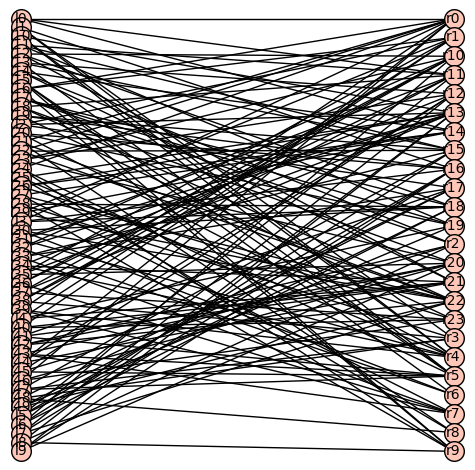

In [4]:
## Creating the bipartite graph G whose bi-adjacency matrix is H

def bipartite_from_biadjacency(H):
    m = H.nrows()
    n = H.ncols()

    L = [f"l{j}" for j in range(n)]
    R = [f"r{i}" for i in range(m)]

    G = BipartiteGraph()
    G.add_vertices(L, left=True)
    G.add_vertices(R, right=True)

    for i in range(m):
        for j in range(n):
            if H[i, j] == 1:
                G.add_edge(f"l{j}", f"r{i}")
    return G

MyGraph = bipartite_from_biadjacency(H)
MyGraph.plot()

## Checking the lossless bipartite expander graph property

For a given bi-adjacency matrix $\mathbf{H} \in \{0,1\}^{m \times n}$ where $m \leq n$, we construct a Python function **check_expander(H,gamma,c,epsilon)** that takes four arguments $\mathbf{H} \in \{0,1\}^{m \times n}$, $\gamma \in [0,1]$, $c \in \mathbb{Z}^+$, and $\epsilon \in (0,1/2)$ and verfies the expander property of the the graph (based on its bi-adjacency matrix), that is: $\forall S \subseteq L$ ($|L| = n$) where $|S| \leq \gamma n$, we have $|N(S)| \geq c(1-\epsilon) |S|$ where $N(S)$ denotes the set of neighbors of $S$.

In [5]:
from itertools import combinations
import math

def check_expander(H, gamma, c, epsilon,
                   check_left_regular=True,
                   return_counterexample=False):
    """
    Works in Sage (Matrix) and in Python (list-of-lists / numpy array), as long as H supports row/col access H[i][j] or H[i,j].
    """

    # --- Sage/Python compatible accessors + force Python ints for m,n ---
    if hasattr(H, "nrows") and hasattr(H, "ncols"):
        m, n = int(H.nrows()), int(H.ncols())
        get = lambda i, j: int(H[i, j])
    else:
        m, n = len(H), len(H[0])
        get = lambda i, j: int(H[i][j])

    assert 0 <= gamma <= 1
    assert 0 < float(epsilon) < 0.5
    assert int(c) > 0

    c = int(c)                 # ensure Python int
    epsilon = float(epsilon)   # use float for alpha/ceil (OK for small experiments)

    K = int(math.floor(gamma * n))
    if K <= 0:
        return (True, {"checked_up_to": 0}) if return_counterexample else True

    alpha = c * (1.0 - epsilon)

    # --- precompute neighbor bitmask for each column j (as Python ints) ---
    col_mask = [0] * n
    col_wt   = [0] * n
    one = 1  # Python int

    for j in range(n):
        mask = 0  # Python int
        wt = 0
        for i in range(m):
            if get(i, j) == 1:
                mask |= (one << i)
                wt += 1
        col_mask[j] = mask
        col_wt[j] = wt

    # optional: verify c-left-regular
    if check_left_regular and any(w != c for w in col_wt):
        if return_counterexample:
            bad = [j for j, w in enumerate(col_wt) if w != c]
            return False, {"reason": "not_c_left_regular", "bad_columns_0_based": bad}
        return False

    # brute force all S up to size K
    for s in range(1, K + 1):
        required = int(math.ceil(alpha * s - 1e-12))
        if required > m:
            if return_counterexample:
                return False, {"reason": "required_exceeds_m", "subset_size": s,
                               "required": required, "m": m}
            return False

        for S in combinations(range(n), s):
            neigh = 0  # Python int
            for j in S:
                neigh |= col_mask[j]
            neigh_size = int(neigh).bit_count()  # now always valid

            if neigh_size < required:
                if return_counterexample:
                    return False, {
                        "reason": "expansion_violated",
                        "subset_size": s,
                        "subset_0_based": list(S),
                        "neighborhood_size": neigh_size,
                        "required": required
                    }
                return False

    return (True, {"checked_up_to": K}) if return_counterexample else True

Some testing of the function **check_expander** for some parameters.

In [6]:
%%time 
test_H = H
test_gamma = 5/50.0
test_c = 3
test_epsilon = 0.470
show(check_expander(test_H,test_gamma,test_c,test_epsilon,True,True))

(True, {'checked_up_to': 5})

CPU times: user 392 ms, sys: 396 μs, total: 392 ms
Wall time: 392 ms


In [7]:
%%time 
test_H = H
test_gamma = 6/50.0
test_c = 3
test_epsilon = 0.470
show(check_expander(test_H,test_gamma,test_c,test_epsilon,True,True))

(False,
 {'reason': 'expansion_violated',
  'subset_size': 6,
  'subset_0_based': [0, 1, 3, 5, 6, 38],
  'neighborhood_size': 9,
  'required': 10})

CPU times: user 384 ms, sys: 211 μs, total: 384 ms
Wall time: 384 ms


## Checking that $\mathrm{Row}_\mathbb{Z}(\mathbf{H}_{(T)}) = \mathbb{Z}^{|T|}$ for every $T \subseteq [1,n]$ with $|T| < 2\gamma(1-\epsilon) n$

We build a function that check whether $\mathrm{Row}_\mathbb{Z}(\mathbf{A}) = \mathbb{Z}^{|T|}$ for $\mathbf{A} \in \mathbb{Z}^{m \times |T|}$ where $|T| \leq m$. We use SNF technique to verify this condition. If $\mathbf{A} \in \mathbb{Z}^{m \times |T|}$ with $\mathrm{rank}_\mathbb{Q}(\mathbf{A}) = r$, then according to SNF of $\mathbf{A}$, there are unimodular matrices $\mathbf{U} \in GL_m(\mathbb{Z}), \mathbf{V}\in GL_{|T|}(\mathbb{Z})$, and a diagonal matrix $\mathbf{D} \in \mathbb{Z}^{m \times |T|}$ with $\mathbf{D} = \mathrm{diag}(d_1,\dots,d_r,0,\dots,0)$ where $d_i > 0$ and $d_i \mid d_{i+1}$ for $i \in [1,r-1]$, such that $\mathbf{U}\mathbf{A}\mathbf{V}=\mathbf{D}$. We have $\mathbf{A} = \mathbf{U}^{-1}\mathbf{D}\mathbf{V}^{-1}$ and we get $\mathrm{Row}_\mathbb{Z}(\mathbf{A}) = \mathrm{Row}_\mathbb{Z}(\mathbf{D})$. Thus, $\mathrm{Row}_\mathbb{Z}(\mathbf{A}) = \mathrm{Row}_\mathbb{Z}(\mathbf{D}) = \mathbb{Z}^{|T|}$ if and only if $\mathrm{rank}_\mathbb{Q}(\mathbf{A}) = |T|$ and $d_1 = \cdots = d_{|T|} = 1$.

In [8]:
def row_lattice_is_full_Z(A):
    """
    A: Sage integer matrix (m x t) over ZZ. Returns True iff Row_Z(A) = Z^t.
    """
    m, t = A.nrows(), A.ncols()
    if t == 0:
        return True
    if A.rank() < t:   # rank over QQ
        return False
    D, U, V = A.smith_form()   # D is diagonal Smith form
    return all(D[i, i] == 1 for i in range(t))

In [9]:
from itertools import combinations

def check_row_span_property(H, gamma, eps, return_counterexample=False):
    """
    Checks: for all T ⊆ [n] with 1 ≤ |T| < 2*gamma*(1-eps)*n, Row_Z(H_(T)) = Z^{|T|}.
    H: Sage matrix (m x n) over GF(2), ZZ, etc. with integer entries.
    gamma: real/rational in [0,1]
    eps: real/rational in (0,1/2)
    """
    m, n = int(H.nrows()), int(H.ncols()) 
    K1 = int(floor(gamma * n))
    K2 = int(floor(2*gamma*(1-eps)*n))-1
    K = max(K1,K2)

    if K <= 0:
        return (True, {"checked_up_to": 0}) if return_counterexample else True

    # Work over ZZ
    HZ = Matrix(ZZ, H)

    for t in range(1, K + 1):
        for T in combinations(range(n), t):      # 0-based column indices
            A = HZ[:, list(T)]                  # m x t submatrix H_(T)
            if not row_lattice_is_full_Z(A):
                if return_counterexample:
                    return False, {
                        "reason": "row_span_not_full",
                        "bad_T_0_based": list(T),
                        "size": t
                    }
                return False

    return (True, {"checked_up_to": K}) if return_counterexample else True

## Randomizing $\mathbf{H}$ using random signed permutation matrix.

We consider the following lemma.

Let $\mathbf{H} \in \mathbb{Z}^{m \times n}$ and $\mathbf{U} \in GL_m(\mathbb{Z})$ be a unimodular matrix. Define $\mathbf{H}' = \mathbf{U} \mathbf{H} \in \mathbb{Z}^{m \times n}$. Let $C_\mathbb{Q} = \ker_\mathbb{Q}(\mathbf{H})$ and $C_\mathbb{Q}' = \ker_\mathbb{Q}(\mathbf{H}')$ be the corresponding linear codes over $\mathbb{Q}$. Then $C_\mathbb{Q}' = C_\mathbb{Q}$ and hence $d(C_\mathbb{Q}) = d(C_\mathbb{Q}')$.

To randomize $\mathbf{H}$ yet keeping entries small, we update $\mathbf{H}:= \mathbf{U}\mathbf{H}$ where $\mathbf{U} \in GL_m(\mathbb{Z}) \cap \{-1,0,1\}^{m \times m}$ is a signed permutation matrix.

In [10]:
import random 

# generating a random signed permutation matrix
def random_signed_permutation_matrix(n,rng):
    '''
    generate a reproducible random n x n signed permutation matrix,
    a permutation matrix is obtained by permuting the rows of an identity matrix,
    a signed permutation matrix is obtained by randomly multiplying the rows 
    of a permutation matrix with -1 or +1
    '''
    perm = list(range(n))
    rng.shuffle(perm) # shuffle row indices
    I = identity_matrix(n)
    P = I[perm,:] # permute the rows of I according to perm
    for i in range(n):
        sign = rng.choice([-1,1])
        P[i,:] *= sign # P[i,:] := sign * P[i,:]
    return P

In [11]:
def randomized_H(H,seed):
    rng = random.Random(int(seed))
    m = H.nrows()
    U = random_signed_permutation_matrix(m,rng)
    return U*H

In [12]:
H_ori = H # saving the original H in H_ori
H = randomized_H(H,0)
test_H = H
show(H)
# show(check_row_span_property(test_H,test_gamma,test_eps,True))

24 x 50 dense matrix over Integer Ring (use the '.str()' method to see the entries)

## Checking the distance of of the code whose parity check matrix is $\mathbf{H}$

Recall that $\mathbf{G} = \begin{bmatrix}\mathbf{g} & \mathbf{\hat{G}}\end{bmatrix}$ and the privacy of the scheme relates to the minimum distance of $\mathcal{\hat{C}}^\bot$. Since $\mathcal{\hat{C}} = \mathrm{Col}_\mathbb{Z}(\mathbf{\hat{G}})$, we have $\mathcal{\hat{C}}^\bot = \{\mathbf{x} \in \mathbb{Z}^n: \mathbf{\hat{G}}^\top \mathbf{x}= \mathbf{0}\} = \ker_\mathbb{Z}(\mathbf{\hat{G}}^\top)$. If $\mathbf{\hat{G}}^\top = \mathbf{H}$, then $\mathcal{\hat{C}}^\bot = \ker_\mathbb{Z}(\mathbf{\hat{G}}^\top) = \ker_\mathbb{Z}(\mathbf{H}) = \mathcal{D}$ where $\mathcal{D}$ is a code for which $\mathbf{H}$ is a parity check matrix. Therefore, $d(\mathcal{\hat{C}}^\bot) = d(\mathcal{D})$, and so optimizing the minimum distance of $\mathcal{\hat{C}}$ reduces to choosing $\mathbf{H}$ to be a parity check matrix of a code $\mathcal{D}$ with good minimum distance.

Notice that if $d_p(\mathcal{C})$ and $d_\mathbb{Q}(\mathcal{C})$ are respectively the distance of the code over $\mathbb{F}_p$ and $\mathbb{Q}$, we have $d_p(\mathcal{C}) \leq d_\mathbb{Q}(\mathcal{C})$.

In [13]:
%%time
test_H_ori = Matrix(GF(2),H_ori)
show(test_H_ori)
test_C_hat_bot_ori = codes.from_parity_check_matrix(test_H_ori)
show(test_C_hat_bot_ori)
test_d_C_hat_bot_ori = test_C_hat_bot_ori.minimum_distance()
show("minimum distance: ",test_d_C_hat_bot_ori)

24 x 50 dense matrix over Finite Field of size 2 (use the '.str()' method to see the entries)

[50, 26] linear code over GF(2)

'minimum distance: ' 6

CPU times: user 999 ms, sys: 55.9 ms, total: 1.06 s
Wall time: 1.17 s


In [14]:
%%time
test_H = Matrix(GF(3),H)
show(test_H)
d = Matroid(test_H).girth()
print(d)
# test_C_hat_bot = codes.from_parity_check_matrix(test_H)
# show(test_C_hat_bot)
# test_d_C_hat_bot = test_C_hat_bot.minimum_distance()
# show("minimum distance: ",test_d_C_hat_bot)

24 x 50 dense matrix over Finite Field of size 3 (use the '.str()' method to see the entries)

6
CPU times: user 1.44 s, sys: 0 ns, total: 1.44 s
Wall time: 1.44 s


Checking the distance via matroid girth over $\mathbb{Q}$.

In [15]:
%%time 
Hq = Matrix(QQ,H)
Mq = Matroid(Hq)
d = Mq.girth()
print("distance over Q: ", d)

distance over Q:  6
CPU times: user 29.7 s, sys: 52.5 ms, total: 29.7 s
Wall time: 29.6 s


Checking the rank over $\mathbb{Q}$.

In [16]:
H_Q = matrix(QQ,H)
print(H_Q.rank())
H_ori_Q = matrix(QQ,H_ori)
print(H_ori_Q.rank())

24
24


# Constructing $\mathbf{g}$ for $\mathbf{G} = \begin{bmatrix}\mathbf{g} & \mathbf{\hat{G}}\end{bmatrix}$

We construct $\mathbf{g}$ by planting small disjoint supports $T \subseteq [1,n]$ on which the reconstruction is guaranteed. We say a support $T \subseteq [1,n]$ is certified if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_T)$. Observe that if $T$ is certified, then any superset $S \supseteq T$ is also certified, i.e., $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$. Now, suppose we have $b \in \mathbb{Z}^+$ disjoint certified supports $T_1,\dots,T_b$, i.e., $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_{T_i})$, for every $i \in [1,b]$. We consider the following lemma.

**Lemma**: If $T_1,\dots,T_b$ are disjoint certified supports, then any $S \subseteq [1,n]$ with $|S| \geq n - b + 1$ contains at least one $T_i$, and hence certified. That is, for any $S \subseteq [1,n]$ with $|S| \geq n - b + 1$, we have $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$.

We can attempt to maximize $b$ in the lemma by minimizing $|T_i|$, guided by an estimate of $\hat{d}^\bot$ (i.e., the distance of $C_\mathbf{H}$) and the known value of $\mathrm{rank}_\mathbb{Q}(\mathbf{H})$. If a non-zero kernel vector cannot be found at a target size $|T_i|$, we increase $|T_i|$ until one is found whenever it is possible (notice that a non-zero vector in $\ker_\mathbb{Z}(\mathbf{H}_{(T_i)})$ exists if $|T_i| \geq \mathrm{rank}_\mathbb{Q}(\mathbf{H}) + 1$). With this approach, we have $\bigcup_{i \in [1,b]}T_i \subseteq [1,n]$ and $\left|[1,n] \setminus \bigcup_{i=1}^b T_i\right| \leq \mathrm{rank}_\mathbb{Q}(\mathbf{H})$. We define $\mathbf{g}$ by fixing coordinates on each $T_i$ and for the remaining indices $j \in [1,n] \setminus \bigcup_{i=1}^b T_i$, we might set $\mathbf{g}[j] \in \{-1,0,1\}$ as a heuristic to boost the correctness probability. Moreover, we search for primitive $\bm{\lambda}_{T_i} \in \ker_\mathbb{Z}(\mathbf{H}_{(T_i)})$ with small components and prefer $(\mathbf{g})_{T_i}$ with small entries (e.g., $(\mathbf{g})_{T_i} \in \{-1,0,1\}^{|T_i|}$ whenever possible). Such choices of $\bm{\lambda}_{T_i}$ and $(\mathbf{g})_{T_i}$ are often possible when $\mathbf{H}$ is sparse and has small entries (e.g., $\mathbf{H}$ is a parity check matrix of LDPC code family).

If we construct $\mathbf{g}$ by planting disjoint support as mentioned above, the deterministic correctness threshold is given by $k_p^\mathsf{det} = n - b + 1$ where $b$ is the number of disjoint supports.
Because $\mathbf{\hat{G}} = \mathbf{H}^\top \in \mathbb{Z}^{n \times k-1}$, we have $\hat{d}^\bot \leq |T_i| \leq \mathrm{rank}_\mathbb{Q}(\mathbf{H})+1 \leq k$, and so $\left\lfloor\frac{n}{\mathrm{rank}_\mathbb{Q}(\mathbf{H}) + 1}\right\rfloor \leq b \leq \left\lfloor\frac{n}{\hat{d}^\bot}\right\rfloor$. This implies $n - \left\lfloor\frac{n}{\hat{d}^\bot}\right\rfloor + 1\leq k_p^\mathsf{det}\leq  n - \left\lfloor\frac{n}{\mathrm{rank}_\mathbb{Q}(\mathbf{H}) + 1}\right\rfloor  + 1 \leq n - \left\lfloor \frac{n}{k}\right\rfloor+1$. We construct the algorithm for constructing $\mathbf{g}$ for a given $\mathbf{H} \in \mathbb{Z}^{m \times n}$.

1. **Input**: $\mathbf{H} \in \mathbb{Z}^{m \times n}$ (the parity check matrix of an expander code with distance $\hat{d}^\bot$), target starting size $t_0$ (estimate of $\hat{d}^\bot$, $t_{\max} = \mathrm{rank}_\mathbb{Q}(\mathbf{H}) + 1$, and $R \in \mathbb{Z}^+$ (maximum trials for random candidates).
2. **Output**: $\mathbf{g}$ (the first column of $\mathbf{G}$ and $\mathcal{T}$ (the disjoint sets of indices for planted certified supports).
3. Initialize $\Omega := [1,n]$, $\mathbf{g}:= \mathbf{0}$, $\mathcal{T} = \emptyset$ (set of lists of indices for planted support).
4. While $|\Omega| \geq t_0$ do:
   1. $Found := \mathbf{False}$
   2. For $t = t_0$ to $\min\{t_{\max},|\Omega|\}$ do
      1. If $t < t_{\max}$:
         1. Try up to $R$ random subsets $T \subseteq \Omega$ with $|T| = t$.
         2. If some $T$ satisfies $\ker_\mathbb{Z}(\mathbf{H}_{(T)}) \supsetneq \{\mathbf{0}\}$: record $T$, set $Found := \mathbf{True}$; **break** the for loop.
         3. If $t$ reach $t_{\max}$, we choose any $T \subseteq \Omega$, set $Found := \mathbf{True}$; **break** the for loop.
    3. If **not** $Found$, **break** the while loop (we cannot plant any more supports).
    4. Find a primitive $\bm{\lambda}_T \in \ker_\mathbb{Z}(\mathbf{H}_{(T)})$ (prefer $\bm{\lambda}_T$ with small entries).
    5. Solve $\bm{\lambda}_T^\top (\mathbf{g})_T = 1$ for $(\mathbf{g})_T$ (generalized Bezout's identity).
    6. Set $\mathbf{g}[j] := (\mathbf{g})_T[j]$ for each $j \in T$.
5. Set $\mathbf{g}[j] \in \{-1,0,1\}$ (often $0$) for the remaining indices to boost correctness.
6. Return $\mathbf{g}$.

## Some basic helper functions

Several helper functions:
1. gcd_vec(vals): computing the gcd of lists of numbers (vals).
2. make_primitive(v): making the vector v a primitive vector.
3. hamming_weight(v): computing the Hamming weight of a vector v.
4. has_pm1(v): checking whether v has -1/+1 components.
5. in_pm1(v): checking whether all components of v are -1/0/+1. 

In [17]:
# computing the gcd of vector components

def gcd_vec(vals):
    """
    vals can be a Python list, Sage vector, or free-module element.
    Returns gcd of entries as a nonnegative ZZ integer.
    """
    g = ZZ(0)
    for x in vals:
        g = gcd(g, ZZ(x))
    return abs(g)


# making a vector v as primitive by dividing the components with the gcd of the components.
def make_primitive(v):
    """
    Return primitive vector by dividing all coordinates by gcd.
    Works for free-module elements and vectors.
    """
    g = gcd_vec(v)
    if g == 0:
        # v is the zero vector
        return vector(ZZ, list(v))
    return vector(ZZ, [ZZ(x)//g for x in v])


# computing the Hamming weight
def hamming_weight(v):
    return sum(1 for x in v if ZZ(x) != 0)

# check whether a vector has -1/+1 components
def has_pm1(v):
    return any(abs(ZZ(x)) == 1 for x in v)

# check whether the entries of a vector are-1/0/+1
def in_pm1(v):
    for x in v:
        if ZZ(x) not in [-1, 0, 1]:
            return False
    return True

$\mathbf{B}$ is a matrix whose rows are the basis of $\ker_\mathbb{Z}(\mathbf{H}_{(T)}$. We apply LLL to the basis matrix $\mathbf{B}$ to transform it into a short basis. LLL might be used when $\mathbf{B} \in \mathbb{Z}^{m \times |T|}$ with $m \geq 2$.

In [18]:
def kernel_basis_on_support(HZZ, T, use_lll=True):
    """
    HZZ: m x n matrix over ZZ
    T: list of column indices (0-based)
    Returns a basis matrix whose rows span ker_Z(H_{(T)}), over ZZ.
    If use_lll=True and kernel rank >= 2, LLL-reduce the basis rows.
    """
    # Make sure T is clean (optional but recommended)
    T = sorted(set(T))

    HT = HZZ[:, T]                      # m x |T|
    K  = HT.right_kernel(ZZ)            # Z-module kernel
    B  = K.basis_matrix()               # rows are a Z-basis (possibly not "nice")

    # LLL changes the basis but not the lattice it spans
    if use_lll and B.nrows() > 1:
        B = B.LLL()
    return B

Pick a good primitive $\bm{\lambda}_T$ based on some basis matrix $\mathbf{B}$.

def pick_primitive_lambda(B):
    """
    B: matrix over ZZ, rows are a Z-basis of a kernel.
    Returns a primitive nonzero vector (ZZ-vector), or None if kernel trivial.
    """
    if B.nrows() == 0:
        return None

    best = None
    best_score = None

    for i in range(B.nrows()):
        v = B.row(i)                                 # free-module element / vector-like
        if all(ZZ(x) == 0 for x in v):
            continue
        
        v = make_primitive(v)

        score = (
            0 if has_pm1(v) else 1,                  # prefer ±1 entry
            hamming_weight(v),                       # then sparse
            max(abs(ZZ(x)) for x in v)               # then small coefficients
        )
        if best is None or score < best_score:
            best, best_score = v, score

    return best

In [19]:
import random

def pick_primitive_lambda(B,
                            top=8,
                            pairwise=True,
                            random_combos=200,
                            coeffs=(-1,0,1),
                            seed=0):
    """
    B: ZZ matrix whose rows span the kernel lattice K ⊂ ZZ^t (ideally LLL-reduced already).
    Returns a primitive nonzero lambda in K with small entries (heuristic).

    Strategy:
      - consider individual basis rows
      - consider pairwise +/- combinations among the first 'top' rows
      - consider random small combinations among the first 'top' rows
      - primitive-ize candidates by dividing by gcd
      - choose best by your score: (has_pm1, hamming_weight, linf)
    """
    r = B.nrows()
    if r == 0:
        return None

    rng = random.Random(int(seed))
    L = min(int(top), r)

    rows = [vector(ZZ, list(B.row(i))) for i in range(r)]
    candidates = []

    # 1) basis rows
    candidates.extend(rows[:L])

    # 2) pairwise sums/differences
    if pairwise:
        for i in range(L):
            for j in range(i+1, L):
                candidates.append(rows[i] + rows[j])
                candidates.append(rows[i] - rows[j])

    # 3) random small combinations of first L rows
    for _ in range(int(random_combos)):
        cs = [rng.choice(coeffs) for _ in range(L)]
        if all(c == 0 for c in cs):
            continue
        v = sum(ZZ(cs[i]) * rows[i] for i in range(L))
        candidates.append(v)

    best = None
    best_score = None

    for v in candidates:
        if all(ZZ(x) == 0 for x in v):
            continue

        v = make_primitive(v)  # your gcd-normalization

        if all(ZZ(x) == 0 for x in v):
            continue

        score = (
            0 if has_pm1(v) else 1,
            hamming_weight(v),
            max(abs(ZZ(x)) for x in v)
        )

        if best is None or score < best_score:
            best, best_score = v, score

    return best

A wrapper that computes the basis $\bm{\lambda}_T$ on a support $T$. We consider using LLL to aim for a good (small and nearly orthogonal) basis.

In [20]:
def find_good_lambda_on_support(HZZ, T, use_lll=True):
    B = kernel_basis_on_support(HZZ, T, use_lll=use_lll)
    lam = pick_primitive_lambda(B,top=8,pairwise=True,random_combos=200,coeffs=(-1,0,1),seed=0)
    return lam

## Fast rejection of $T$

We are interested to find $T \subseteq [1,n]$ such that $\ker_\mathbb{Z}(\mathbf{H}_{(T)}) \supsetneq \{\mathbf{0}\}$. Notice that we have $\ker_\mathbb{Q}(\mathbf{H}_{(T)}) \supsetneq \{\mathbf{0}\}$ if and only if $\mathrm{rank}_{\mathbb{Q}}(\mathbf{H}_{(T)}) < |T|$. Since the entries of the matrices are small, we can consider using a small finite field $\mathbb{F}_p$ instead of $\mathbb{Q}$. If $\mathrm{rank}_{\mathbb{F}_p}(\mathbf{H}_{(T)}) = |T|$, then it is guaranteed that (since the entries of $\mathbf{H}$ is small), we have $\mathrm{rank}_\mathbb{Q}(\mathbf{H}_{(T)} = |T|$, which implies $\ker_\mathbb{Q}(\mathbf{H}_{(T)}) = \{\mathbf{0}\}$, and so $\ker_\mathbb{Z}(\mathbf{H}_{(T)}) = \{\mathbf{0}\}$.

In [21]:
def fast_reject_full_rank_modp(HZZ, T, primes=(101, 103, 107)):
    """
    Return True if we can safely reject T because H[:,T] has full column rank mod p
    for at least one prime p in primes.
    Safe: if it returns True, then rank_QQ(H[:,T]) = |T|, hence no integer kernel.
    """
    HT = HZZ[:, T]
    m, t = HT.nrows(), HT.ncols()
    if t > m:
        return False
    for p in primes:
        r = HT.change_ring(GF(p)).rank()
        if r == t:
            return True
    return False

## Constructing $(\mathbf{g})_T$ from $\bm{\lambda}_T$

### Option 1: quick scan

Option 1: finding $(\mathbf{g})_T$ if $\bm{\lambda}_T$ is a vector whose components are either $-1$, $0$, or $+1$ quickly. Notice that if $\bm{\lambda}_T \in \ker_\mathbb{Z}(\mathbf{H}_{(T)}) \setminus \{\mathbf{0}\}$ and $\bm{\lambda}_T \in \{-1,0,1\}^{|T|}$ and $(\mathbf{g})_{T} \in \mathbb{Z}^{|T|}$ satisfies $\bm{\lambda}_T^\top(\mathbf{g})_T=1$, we can set $(\mathbf{g})_T$ as a vector whose entries are all $0$ except in the first index $j$ such that $\bm{\lambda}_S[j]$ is non-zero. Let this index be $j$, then we set $(\mathbf{g})_S[j] = 1$ if $\bm{\lambda}_S[j] =1 $ and $(\mathbf{g})_S[j] = -1$ if $\bm{\lambda}_S[j] = -1$. The technique in option 1 is used for the next technique. We call this function **g_on_support_unit**.

Basically, the objective of this function is to produce $(\mathbf{g})_T$ with the following properties:
1. $(\mathbf{g})_T \in \{-1,0,1\}^{|T|}$,
2. $\bm{\lambda}_T^\top (\mathbf{g})_T = 1$,
3. $\|(\mathbf{g})_T\|_1 = 1$.

In [22]:
# option 1: finding g if lambda is a vector whose components are either -1, 0, or 1 quickly

def g_on_support_unit(lambda_T):
    """
    Option 1:
    If lambda_T has a ±1 entry, return g_T in {-1,0,1}^{|T|} with lambda_T^T * g_T = 1.

    Strategy:
      - If lambda_T[j] == +1, set g_T[j] = +1 (others 0).
      - Else if lambda_T[j] == -1, set g_T[j] = -1 (others 0).
      - If no ±1 entry exists, return None.
    """
    lam = vector(ZZ, list(lambda_T))
    t = len(lam)
    gT = vector(ZZ, [0]*t)

    # Prefer +1 pivot, then -1 pivot
    for j in range(t):
        if lam[j] == 1:
            gT[j] = 1
            return gT

    for j in range(t):
        if lam[j] == -1:
            gT[j] = -1
            return gT

    return None

### Option 2: using the generalized Bezout's identity

Option 2: finding $(\mathbf{g})_T$ by aiming for $(\mathbf{g})_T$ with higher Hamming weight. We might call **g_on_support_unit** as a subroutine.

Generalized Bezout identity. For an input $\bm{\lambda} \in \mathbb{Z}^t$, the output is $\mathbf{g}\in \mathbb{Z}^t$ such that $\bm{\lambda}^\top \mathbf{g} = 1$.

In [23]:
# bezout helper

def bezout_solution_for_dot_1(lam):
    """
    Given lam in ZZ^t with gcd(lam)=1, return g in ZZ^t such that lam^T * g = 1.

    Returns None if gcd(lam) != 1 or lam is all-zero.
    Uses iterative extended gcd folding; robust to zeros.
    """
    lam = vector(ZZ, list(lam))
    t = len(lam)

    # positions of nonzero entries
    nz = []
    for i in range(t):
        if lam[i] != 0:
            nz.append(i)
    if len(nz) == 0:
        return None # lam is all-zero

    # check gcd condition explicitly
    if gcd_vec(lam) != 1:
        return None

    # start with the first non-zero coordinate
    i0 = nz[0]
    current = ZZ(lam[i0])
    coeffs = [ZZ(0)] * t
    coeffs[i0] = ZZ(1)

    # fold in remaining nonzero coordinates
    for i in nz[1:]:
        gg, u, v = xgcd(current, lam[i])   # u*current + v*lam[i] = gg
        coeffs = [ZZ(u) * c for c in coeffs]
        coeffs[i] = coeffs[i] + ZZ(v)
        current = ZZ(gg)
        if current == 1 or current == -1:
            break

    # normalize sign: current = +1
    if current == -1:
        coeffs = [-c for c in coeffs]
        current = ZZ(1)

    if current != 1:
        return None

    return vector(ZZ, coeffs)

**make_dense_g** takes a vector $\bm{\lambda}_T \in \mathbb{Z}^{|T|}$ and output a vector $(\mathbf{g})_T \in \mathbb{Z}^{|T|}$ using the following approach:
1. Consider finding $(\mathbf{g})_T$ using option 1 (i.e., **g_on_support_unit(lambda_T)**) to keep $(\mathbf{g})_{T}$ sparse. If it is not possible, we consider the generalized Bezout identity approach.
2. Optionally densify $\bm{\lambda}_T$ by: filling the indices $i \in T$ such that $\bm{\lambda}_T[i] = 0$ with non-zero values (default $1$) and add canceling pairs to keep the dot product unchanged.

In **make_dense_g(lambda_T, fill_zero_coords=True, nonzero_value=1, max_pair_fills=None)**:
1. fill_zero_coords=False to keep $(\mathbf{g})_T$ dense (heuristic to increase the correctness probability).
2. max_pair_fills to cap the number of canceling pairs we add. 

In [24]:
# option 2: find g in general, dense-by-default (fills lam=0 positions)

def make_dense_g(lambda_T, fill_zero_coords=True, nonzero_value=1, max_pair_fills=None):
    """
    Option 2 (dense by default):
    Build gT in ZZ^{|T|} such that lam^T * gT = 1, then optionally densify.

    Default: fill_zero_coords=True.

    Densification steps:
      (A) fill free coordinates where lam[j]=0 (does not change dot product)
      (B) add canceling pairs among remaining coordinates to keep dot fixed

    Returns:
      gT (ZZ vector) or None.
    """
    lam = vector(ZZ, list(lambda_T))
    lam = make_primitive(lam)

    if gcd_vec(lam) != 1:
        return None

    t = len(lam)

    # (1) base solution: unit if possible, otherwise Bézout
    gT = g_on_support_unit(lam)
    if gT is None:
        gT = bezout_solution_for_dot_1(lam)
        if gT is None:
            return None

    # (2) fill free coords lam[j]=0
    if fill_zero_coords:
        for j in range(t):
            if lam[j] == 0 and gT[j] == 0:
                gT[j] = ZZ(nonzero_value)

    # (3) canceling pairs among remaining zeros where lam != 0
    idx = [j for j in range(t) if lam[j] != 0 and gT[j] == 0]
    filled = 0

    for a in range(len(idx)):
        for b in range(a + 1, len(idx)):
            if max_pair_fills is not None and filled >= max_pair_fills:
                break

            i = idx[a]
            j = idx[b]

            if gT[i] != 0 or gT[j] != 0:
                continue

            # Case 1: lam[i] == lam[j] => set (g[i], g[j]) = (1, -1)
            if lam[i] == lam[j]:
                gT[i] = ZZ(1)
                gT[j] = ZZ(-1)

            # Case 2: lam[i] == -lam[j] => set (g[i], g[j]) = (1, 1)
            elif lam[i] == -lam[j]:
                gT[i] = ZZ(1)
                gT[j] = ZZ(1)

            else:
                continue

            # safety check
            if lam.dot_product(gT) != 1:
                gT[i] = ZZ(0)
                gT[j] = ZZ(0)
            else:
                filled += 1

        if max_pair_fills is not None and filled >= max_pair_fills:
            break

    if lam.dot_product(gT) != 1:
        return None

    return gT

### Option 3: prefer dense $(\mathbf{g})_T \in \{-1,0,1\}^{|T|}$

Option 3: finding $(\mathbf{g})_T$ if $\bm{\lambda}_T$ by aiming for $(\mathbf{g})_T$ with higher Hamming weight while maintaining $(\mathbf{g})_T \in \{-1,0,1\}^{|T|}$. We use **g_on_support_unit** as a subroutine.

In [25]:
# option 3: find g, aim g with a higher Hamming weight, but its entries are in {-1,0,1}

def make_dense_g_pm1(lambda_T, fill_zero_coords=True, max_pair_fills=None):
    """
    Option 3:
    Build gT in {-1,0,1}^{|T|} such that lam^T * gT = 1, aiming for higher Hamming weight.

    Requires:
      - gcd(lam)=1
      - lam has a ±1 entry (so unit base exists)

    Densification:
      (A) fill lam[j]=0 coords with +1
      (B) add canceling pairs with pm1 assignments
    """
    lam = vector(ZZ, list(lambda_T))
    lam = make_primitive(lam)

    if gcd_vec(lam) != 1:
        return None

    t = len(lam)

    # base must exist in pm1
    gT = g_on_support_unit(lam)
    if gT is None:
        return None

    # (A) fill free coordinates (lam=0) with +1
    if fill_zero_coords:
        for j in range(t):
            if lam[j] == 0 and gT[j] == 0:
                gT[j] = ZZ(1)

    # (B) canceling pairs among remaining zeros with lam != 0
    idx = [j for j in range(t) if lam[j] != 0 and gT[j] == 0]
    filled = 0

    for a in range(len(idx)):
        for b in range(a + 1, len(idx)):
            if max_pair_fills is not None and filled >= max_pair_fills:
                break

            i = idx[a]
            j = idx[b]

            if gT[i] != 0 or gT[j] != 0:
                continue

            if lam[i] == lam[j]:
                gT[i] = ZZ(1)
                gT[j] = ZZ(-1)
            elif lam[i] == -lam[j]:
                gT[i] = ZZ(1)
                gT[j] = ZZ(1)
            else:
                continue

            if lam.dot_product(gT) != 1:
                gT[i] = ZZ(0)
                gT[j] = ZZ(0)
            else:
                filled += 1

        if max_pair_fills is not None and filled >= max_pair_fills:
            break

    # sanity checks
    if lam.dot_product(gT) != 1:
        return None

    for x in gT:
        if x not in [-1,0,1]:
            return None

    return gT

As a preferred policy, we try option 3 first, if it fails, we use option 2 (which is guaranteed to be succeed whenever the kernel is non-trivial).

In [26]:
def construct_gT(lambda_T,
                 opt3_fill_zero_coords=True, 
                 opt3_max_pair_fills=None,
                 opt2_fill_zero_coords=True, 
                 opt2_nonzero_value=1, 
                 opt2_max_pair_fills=None):
    """
    Policy:
      - Try Option 3 first (pm1-only).
      - If it fails, fall back to Option 2 (general dense-by-default).
    Return gT
    """
    g3 = make_dense_g_pm1(lambda_T,
                          fill_zero_coords=opt3_fill_zero_coords,
                          max_pair_fills=opt3_max_pair_fills)
    if g3 is not None:
        return g3

    g2 = make_dense_g(lambda_T,
                      fill_zero_coords=opt2_fill_zero_coords,
                      nonzero_value=opt2_nonzero_value,
                      max_pair_fills=opt2_max_pair_fills)
    if g2 is not None:
        return g2

    return None

## Choosing $T \subseteq \Omega$ with $|T| = t$ and $\ker_\mathbb{Z}(\mathbf{H}_{(T)})$ contains small non-zero vector

Technique 1: sliding window. We keep $\Omega$ sorted and try consecutive chunks of size exactly $t$.

In [27]:
# sliding window technique
def candidates_window(Omega, t):
    """
    Sliding window technique:
    Yield subsets of size exactly t by trying consecutive chunks of Omega (sorted).
    Omega can be any iterable (list, set, etc.).
    """
    Omega = list(Omega)
    Omega.sort()

    if t > len(Omega):
        return

    for start in range(0, len(Omega) - t + 1):
        yield Omega[start:start + t]

Technique 2: random subset. We choose a random subset $T \subseteq \Omega$ of size exactly $t$.

In [28]:
# random subset technique
def candidates_random(Omega, t, trials=500, rng=None):
    """
    Random subset technique:
    Yield subsets of size exactly t by random sampling from Omega.

    Requirements:
      - rng must be provided for reproducibility (e.g., random.Random(seed)).
    """
    if rng is None:
        raise ValueError("candidates_random requires rng for reproducibility.")

    Omega = list(Omega)

    if t > len(Omega):
        return

    for _ in range(trials):
        T = rng.sample(Omega, t)
        T.sort()
        yield T

Choosing $T$ with a hybrid approach. We try several candidates (using the sliding window and random subset technique), compute a "score" for each subset $T$. The score of each subset depends on $(\mathbf{g})_T$ with the following preferences:
1. $(\mathbf{g})_T \in \{-1,0,1\}^{|T|}$.
2. Smaller $|\mathrm{supp}(\bm{\lambda}_T)|$ (i.e., smaller $wt_H(\bm{\lambda}_T)$).
3. Smaller $\|\bm{\lambda}_T\|_\infty$.
4. Denser $(\mathbf{g})_T$ (i.e., higher $wt_H((\mathbf{g})_T)$.

We consider the function **choose_best_candidate(HZZ, Omega, t, K=50, rng=None, max_abs_coeff=10, nonzero_value=1,mode="Dense",use_lll=True,fallback_to_option2=True)**:
1. HZZ is the matrix (over the integers).
2. Omega is the list of indices, $\Omega \subseteq [1,n]$ (initially $\Omega = [1,n]$).
3. $t$ is the subset size.
4. $K$ is the number of candidates to try (default value $50$).
5. rng is used for randomness reproducibility.
6. max_abs_coeff is the maximum of the absolute value of entries tolerated for $(\mathbf{g})_T$ (default value $10$).
7. nonzero_value is used in **construct_gT(lambda_T,opt3_fill_zero_coords=True,opt3_max_pair_fills=None,opt2_fill_zero_coords=True,opt2_nonzero_value=1,opt2_max_pair_fills=None)**.
8. mode="Dense" is the default so that we consider **construct_gT(lambda_T,opt3_fill_zero_coords=True,opt3_max_pair_fills=None,opt2_fill_zero_coords=True,opt2_nonzero_value=1,opt2_max_pair_fills=None)**. If mode="Sparse", then we consider **construct_gT(lambda_T,opt3_fill_zero_coords=False,opt3_max_pair_fills=None,opt2_fill_zero_coords=False,opt2_nonzero_value=1,opt2_max_pair_fills=None)**.
9. use_lll=True means the kernel basis is reduced using the LLL algorithm.
10. fallback_to_option2=True means that if we do not get the small solution, we might tolerate a larger value for the components of $(\mathbf{g})_T$ (up to max_abs_coeff). 

In [29]:
# hybrid method for choosing the best T

def choose_best_candidate(HZZ, Omega, t, K=50, rng=None,
                          max_abs_coeff=10, nonzero_value=1,
                          mode="Dense", use_lll=True,
                          fallback_to_option2=True):
    """
    Hybrid candidate selection.

    - Tries K candidates:
        * about half via sliding windows (deterministic)
        * the rest via random sampling (reproducible via rng)

    - For each candidate T:
        1) compute lam in ker_Z(H_(T)) (primitive, preferably small)
        2) build gT using construct_gT (Option 3 then Option 2) with Dense/Sparse settings
        3) optionally fallback to Option 2 directly if construct_gT fails
        4) reject if ||gT||_inf > max_abs_coeff
        5) score candidates and pick the best (lexicographic)

    Returns:
        (T_best, lam_best, gT_best) or (None, None, None)
    """
    if rng is None:
        raise ValueError("choose_best_candidate requires rng for reproducibility.")

    Omega = sorted(list(Omega))
    if t > len(Omega):
        return None, None, None

    # --- build candidate list ---
    cand_list = []

    # windows: take up to K//2 consecutive chunks
    win_limit = max(1, K // 2)
    for start in range(0, len(Omega) - t + 1):
        cand_list.append(Omega[start:start+t])
        if len(cand_list) >= win_limit:
            break

    # random candidates: fill remaining budget
    remaining = K - len(cand_list)
    if remaining > 0:
        for T in candidates_random(Omega, t, trials=remaining, rng=rng):
            cand_list.append(T)

    best_T = None
    best_lam = None
    best_gT = None
    best_score = None

    # --- evaluate candidates ---
    for T in cand_list:
        if fast_reject_full_rank_modp(HZZ, T, primes=(101,103,107)):
            continue  # definitely no kernel; skip expensive kernel computation
        
        lam = find_good_lambda_on_support(HZZ, T, use_lll=use_lll)
        if lam is None:
            continue

        # choose Dense/Sparse policy
        if mode == "Dense":
            gT = construct_gT(lam,
                              opt3_fill_zero_coords=True,
                              opt3_max_pair_fills=None,
                              opt2_fill_zero_coords=True,
                              opt2_nonzero_value=nonzero_value,
                              opt2_max_pair_fills=None)
        else:  # "Sparse"
            gT = construct_gT(lam,
                              opt3_fill_zero_coords=False,
                              opt3_max_pair_fills=None,
                              opt2_fill_zero_coords=False,
                              opt2_nonzero_value=nonzero_value,
                              opt2_max_pair_fills=None)

        # optional fallback (in case construct_gT returns None unexpectedly)
        if gT is None and fallback_to_option2:
            if mode == "Dense":
                gT = make_dense_g(lam,
                                  fill_zero_coords=True,
                                  nonzero_value=nonzero_value,
                                  max_pair_fills=None)
            else:
                gT = make_dense_g(lam,
                                  fill_zero_coords=False,
                                  nonzero_value=nonzero_value,
                                  max_pair_fills=None)

        if gT is None:
            continue

        # reject huge gT
        gT_inf = max(abs(ZZ(x)) for x in gT)
        if gT_inf > max_abs_coeff:
            continue

        pm1_ok = in_pm1(gT)

        # score: smaller is better
        score = (
            0 if pm1_ok else 1,                    # prefer gT in {-1,0,1}
            hamming_weight(lam),                   # smaller support of lambda
            max(abs(ZZ(x)) for x in lam),          # smaller lambda coefficients
            -hamming_weight(gT),                   # prefer denser gT (higher weight)
            gT_inf                                 # then smaller gT infinity norm
        )

        if best_score is None or score < best_score:
            best_score = score
            best_T = T
            best_lam = lam
            best_gT = gT

    if best_T is None:
        return None, None, None

    return best_T, best_lam, best_gT


## Main function to construct $\mathbf{g}$ from $\mathbf{\hat{G}} = \mathbf{H}^\top$

In [30]:
import random

def plant_supports_and_build_g(HZZ,
                               t0,
                               tmax=None,
                               K=50,
                               fill_remaining="zero",
                               mode="Dense",
                               max_abs_coeff=10,
                               nonzero_value=1,
                               rng=None,
                               seed=10,
                               use_lll=True,
                               fallback_to_option2=True,
                               primes=(101,103,107),
                               verbose=False):
    r"""
    Plant disjoint supports and build a global vector g.

    We maintain a remaining index set Omega \subseteq {0,1,...,n-1}. Each iteration:
      - pick a subset T \subseteq Omega of size t (starting from t0 and increasing up to tmax), such that ker_Z(H_{(T)}) is non-trivial,
      - choose a "good" primitive lambda_T in ker_Z(H_{(T)}),
      - construct g_T such that lambda_T^T * g_T = 1 (using the above construct_gT policy),
      - write g_T into the global vector g on coordinates T,
      - remove T from Omega (disjoint supports).

    Parameters
    ----------
    HZZ : Sage matrix over ZZ, shape (m, n)
          Parity-check matrix (integer entries, often -1/0/1).
    t0  : int
          Starting support size to try.
    tmax: int or None
          Maximum support size to try. If None, set to rank_QQ(HZZ)+1.
    K : int
        Number of candidates to try per call to choose_best_candidate.
    fill_remaining : str
                     How to fill g[j] for remaining j in Omega at the end:
                      - "zero" (default): set all remaining entries to 0
                      - "pm1": set remaining entries randomly in {-1,0,1}
                      - "pm1_nozero": set remaining entries randomly in {-1,+1}
    mode : str
           Passed to choose_best_candidate / construct_gT. ("Dense" or "Sparse")
    max_abs_coeff : int
           Reject any candidate whose ||g_T||_inf > max_abs_coeff.
    nonzero_value : int
           Passed into construct_gT (used when filling free coordinates in dense mode).
    rng : random.Random or None
          Random generator for reproducibility. If None, a new one is created from seed.
    seed : int
           Seed used to create rng if rng is None.
    use_lll : bool
              Whether to LLL-reduce kernel basis in find_good_lambda_on_support.
    fallback_to_option2 : bool
            Passed to choose_best_candidate. Safety net if construct_gT fails unexpectedly. (Default: True)
    primes : tuple of primes
             Primes used by fast_reject_full_rank_modp inside choose_best_candidate (if choose_best_candidate accepts it).
              Here we pass it manually in the loop below if we need to.
    verbose : bool
              If True, print progress (chosen t, support sizes, remaining Omega).

    Returns
    -------
    supports : list of lists
        List of planted supports T (each T is a sorted list of 0-based indices).
    lambdas : list of Sage vectors
        Corresponding primitive lambda_T vectors in ZZ^{|T|}.
        Note: lambda_T coordinates align with the column order in T.
    g : Sage vector over ZZ
        Global vector g in ZZ^n.
    rng : random.Random
        RNG used (for reproducibility).

    Notes
    -----
    - This function tries t = t0, t0+1, ..., min(tmax, |Omega|) each outer iteration.
      It accepts the first t for which choose_best_candidate returns a valid T.
      This biases toward smaller supports (helps maximize the number of disjoint supports).
    - Indices are assumed 0-based throughout.
    """
    # reproducible RNG
    if rng is None:
        rng = random.Random(int(seed))

    m, n = HZZ.nrows(), HZZ.ncols()
    t0 = int(t0)

    # rank over QQ is the correct notion for dependence
    rQ = HZZ.change_ring(QQ).rank()

    if tmax is None:
        tmax = int(rQ) + 1
    else:
        tmax = int(tmax)

    # Remaining indices (0-based)
    Omega = list(range(n))
    supports = []
    lambdas = []
    g = vector(ZZ, [0]*n)

    # Outer loop: continue while we can still fit a support of size t0
    while len(Omega) >= t0:
        found_any = False
        T_best = None
        lam_best = None
        gT_best = None

        # Try increasing sizes; stop at min(tmax, len(Omega))
        t_upper = min(tmax, len(Omega))

        for t in range(t0, t_upper + 1):
            # use choose_best_candidate for the best T of this size
            T, lam, gT = choose_best_candidate(HZZ, Omega, t,
                                               K=K,
                                               rng=rng,
                                               max_abs_coeff=max_abs_coeff,
                                               nonzero_value=nonzero_value,
                                               mode=mode,
                                               use_lll=use_lll,
                                               fallback_to_option2=fallback_to_option2)

            if T is None:
                continue

            # Sanity checks (optional but helpful)
            # - T should be sorted, 0-based, subset of Omega
            # - lam and gT lengths should match |T|
            if len(lam) != len(T) or len(gT) != len(T):
                # Something inconsistent; skip this candidate
                continue

            # Optional: verify dot product invariant (should hold if construct_gT works)
            if vector(ZZ, list(lam)).dot_product(vector(ZZ, list(gT))) != 1:
                continue

            # Accept the first size t that yields a valid candidate (bias for small supports)
            found_any = True
            T_best, lam_best, gT_best = T, lam, gT
            if verbose:
                print("Found support of size t =", t, "; |Omega| before =", len(Omega))
            break

        if not found_any:
            if verbose:
                print("No more supports found; stopping. |Omega| =", len(Omega))
            break

        # Plant gT_best into global g on coordinates T_best
        for pos in range(len(T_best)):
            j = T_best[pos]          # 0-based index in [0, n-1]
            g[j] = ZZ(gT_best[pos])  # gT_best is aligned with T_best order

        # Record planted support and lambda
        supports.append(list(T_best))
        lambdas.append(vector(ZZ, list(lam_best)))

        # Remove T_best from Omega (disjoint supports)
        Tset = set(T_best)
        Omega = [j for j in Omega if j not in Tset]

        if verbose:
            print("Planted support; |Omega| after =", len(Omega))

    # Fill remaining indices of g according to policy
    if fill_remaining == "zero":
        # already zero by initialization; nothing to do
        pass
    elif fill_remaining == "pm1":
        for j in Omega:
            g[j] = ZZ(rng.choice([-1, 0, 1]))
    elif fill_remaining == "pm1_nozero":
        for j in Omega:
            g[j] = ZZ(rng.choice([-1, 1]))
    else:
        raise ValueError("Unknown fill_remaining policy: {}".format(fill_remaining))

    return supports, lambdas, g, rng

We test the construction of $\mathbf{g}$ using previously defined $\mathbf{\hat{G}}^\top=\mathbf{H}$. The lower bound for he distance of the code is known in advance.

In [31]:
%%time
H
show(H)
# case 1: remaining zero, Dense, use_lll (1st choice, balanced)
(T1, lambdas1, g1, rng1) = plant_supports_and_build_g(
    H,6,tmax=None,K=5000,fill_remaining="zero",mode="Dense",max_abs_coeff=10,nonzero_value=1,rng=None,seed=2025,
    use_lll=True,fallback_to_option2=True,primes=(101,103,107),verbose=False)
show((T1, lambdas1, g1))
print(T1)
# case 2: remaining pm1, Dense, use_lll (2nd choice, densest)
(T2, lambdas2, g2, rng) = plant_supports_and_build_g(
    H,6,tmax=None,K=5000,fill_remaining="pm1",mode="Dense",max_abs_coeff=10,nonzero_value=1,rng=None,seed=2025,
    use_lll=True,fallback_to_option2=True,primes=(101,103,107),verbose=False)
show((T2, lambdas2, g2))
print(T2)
# case 3: remaining zero, Sparse, use_lll (3rd choice, sparsest)
(T3, lambdas3, g3, rng) = plant_supports_and_build_g(
    H,6,tmax=None,K=5000,fill_remaining="zero",mode="Sparse",max_abs_coeff=10,nonzero_value=1,rng=None,seed=2025,
    use_lll=True,fallback_to_option2=True,primes=(101,103,107),verbose=False)
show((T3, lambdas3, g3))
print(T3)

24 x 50 dense matrix over Integer Ring (use the '.str()' method to see the entries)

([[1, 10, 11, 17, 20, 24, 27, 31, 47],
  [6, 9, 12, 19, 30, 35, 38, 40, 49],
  [7, 8, 16, 26, 29, 42, 46, 48],
  [0, 2, 3, 4, 5, 13, 14, 18, 22, 23, 33, 34, 36, 37, 39, 43, 45]],
 [(1, 1, 1, 0, -1, 0, 0, -1, -1),
  (1, 1, -1, -1, 0, -1, 0, 1, 0),
  (0, 1, -1, -1, 1, -1, 1, 0),
  (1, 0, -3, 0, 3, -3, -1, -3, 3, 1, 0, 1, -1, 0, -1, 2, 1)],
 (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 0, 1, 1, -1, 1, 1, 0, 0, 1, 1, 0, -1, 1, 0, 1, 1, -1, 0, 1, 1, -1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1))

[[1, 10, 11, 17, 20, 24, 27, 31, 47], [6, 9, 12, 19, 30, 35, 38, 40, 49], [7, 8, 16, 26, 29, 42, 46, 48], [0, 2, 3, 4, 5, 13, 14, 18, 22, 23, 33, 34, 36, 37, 39, 43, 45]]


([[1, 10, 11, 17, 20, 24, 27, 31, 47],
  [6, 9, 12, 19, 30, 35, 38, 40, 49],
  [7, 8, 16, 26, 29, 42, 46, 48],
  [0, 2, 3, 4, 5, 13, 14, 18, 22, 23, 33, 34, 36, 37, 39, 43, 45]],
 [(1, 1, 1, 0, -1, 0, 0, -1, -1),
  (1, 1, -1, -1, 0, -1, 0, 1, 0),
  (0, 1, -1, -1, 1, -1, 1, 0),
  (1, 0, -3, 0, 3, -3, -1, -3, 3, 1, 0, 1, -1, 0, -1, 2, 1)],
 (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 0, 1, 1, -1, 1, 1, -1, 0, 1, 1, -1, -1, 1, 1, 1, 1, -1, 1, 1, 1, -1, 1, 1, 1, 1, 0, 1, 1, 0, -1, 1, 0, 0, 1, 1))

[[1, 10, 11, 17, 20, 24, 27, 31, 47], [6, 9, 12, 19, 30, 35, 38, 40, 49], [7, 8, 16, 26, 29, 42, 46, 48], [0, 2, 3, 4, 5, 13, 14, 18, 22, 23, 33, 34, 36, 37, 39, 43, 45]]


([[1, 10, 11, 17, 20, 24, 27, 31, 47],
  [6, 9, 12, 19, 30, 35, 38, 40, 49],
  [7, 8, 16, 26, 29, 42, 46, 48],
  [0, 2, 3, 4, 5, 13, 14, 18, 22, 23, 33, 34, 36, 37, 39, 43, 45]],
 [(1, 1, 1, 0, -1, 0, 0, -1, -1),
  (1, 1, -1, -1, 0, -1, 0, 1, 0),
  (0, 1, -1, -1, 1, -1, 1, 0),
  (1, 0, -3, 0, 3, -3, -1, -3, 3, 1, 0, 1, -1, 0, -1, 2, 1)],
 (1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, -1, 1, 1, 1, 0, 1, 0, -1, 1, 1, 0, 0, 1, 0, 0, -1, 0, 0, 1, 0, -1, 0, 0, 1, -1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0))

[[1, 10, 11, 17, 20, 24, 27, 31, 47], [6, 9, 12, 19, 30, 35, 38, 40, 49], [7, 8, 16, 26, 29, 42, 46, 48], [0, 2, 3, 4, 5, 13, 14, 18, 22, 23, 33, 34, 36, 37, 39, 43, 45]]
CPU times: user 13.6 s, sys: 23.8 ms, total: 13.6 s
Wall time: 13.6 s


In [32]:
%%time
H_ori
show(H_ori)
# case 1: remaining zero, Dense, use_lll (1st choice, balanced)
(T1_ori, lambdas1_ori, g1_ori, rng1_ori) = plant_supports_and_build_g(
    H_ori,6,tmax=None,K=5000,fill_remaining="zero",mode="Dense",max_abs_coeff=10,nonzero_value=1,rng=None,seed=2025,
    use_lll=True,fallback_to_option2=True,primes=(101,103,107),verbose=False)
show((T1_ori, lambdas1_ori, g1_ori))
# case 2: remaining pm1, Dense, use_lll (2nd choice, densest)
(T2_ori, lambdas2_ori, g2_ori, rng_ori) = plant_supports_and_build_g(
    H_ori,6,tmax=None,K=5000,fill_remaining="pm1",mode="Dense",max_abs_coeff=10,nonzero_value=1,rng=None,seed=2025,
    use_lll=True,fallback_to_option2=True,primes=(101,103,107),verbose=False)
show((T2_ori, lambdas2_ori, g2_ori))
# case 3: remaining zero, Sparse, use_lll (3rd choice, sparsest)
(T3_ori, lambdas3_ori, g3_ori, rng_ori) = plant_supports_and_build_g(
    H_ori,6,tmax=None,K=5000,fill_remaining="zero",mode="Sparse",max_abs_coeff=10,nonzero_value=1,rng=None,seed=2025,
    use_lll=True,fallback_to_option2=True,primes=(101,103,107),verbose=False)
show((T3_ori, lambdas3_ori, g3_ori))

24 x 50 dense matrix over Integer Ring (use the '.str()' method to see the entries)

([[1, 10, 11, 17, 20, 24, 27, 31, 47],
  [6, 9, 12, 19, 30, 35, 38, 40, 49],
  [7, 8, 16, 26, 29, 42, 46, 48],
  [0, 2, 3, 4, 5, 13, 14, 18, 22, 23, 33, 34, 36, 37, 39, 43, 45]],
 [(1, 1, 1, 0, -1, 0, 0, -1, -1),
  (1, 1, -1, -1, 0, -1, 0, 1, 0),
  (0, 1, -1, -1, 1, -1, 1, 0),
  (1, 0, -3, 0, 3, -3, -1, -3, 3, 1, 0, 1, -1, 0, -1, 2, 1)],
 (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 0, 1, 1, -1, 1, 1, 0, 0, 1, 1, 0, -1, 1, 0, 1, 1, -1, 0, 1, 1, -1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1))

([[1, 10, 11, 17, 20, 24, 27, 31, 47],
  [6, 9, 12, 19, 30, 35, 38, 40, 49],
  [7, 8, 16, 26, 29, 42, 46, 48],
  [0, 2, 3, 4, 5, 13, 14, 18, 22, 23, 33, 34, 36, 37, 39, 43, 45]],
 [(1, 1, 1, 0, -1, 0, 0, -1, -1),
  (1, 1, -1, -1, 0, -1, 0, 1, 0),
  (0, 1, -1, -1, 1, -1, 1, 0),
  (1, 0, -3, 0, 3, -3, -1, -3, 3, 1, 0, 1, -1, 0, -1, 2, 1)],
 (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 0, 1, 1, -1, 1, 1, -1, 0, 1, 1, -1, -1, 1, 1, 1, 1, -1, 1, 1, 1, -1, 1, 1, 1, 1, 0, 1, 1, 0, -1, 1, 0, 0, 1, 1))

([[1, 10, 11, 17, 20, 24, 27, 31, 47],
  [6, 9, 12, 19, 30, 35, 38, 40, 49],
  [7, 8, 16, 26, 29, 42, 46, 48],
  [0, 2, 3, 4, 5, 13, 14, 18, 22, 23, 33, 34, 36, 37, 39, 43, 45]],
 [(1, 1, 1, 0, -1, 0, 0, -1, -1),
  (1, 1, -1, -1, 0, -1, 0, 1, 0),
  (0, 1, -1, -1, 1, -1, 1, 0),
  (1, 0, -3, 0, 3, -3, -1, -3, 3, 1, 0, 1, -1, 0, -1, 2, 1)],
 (1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, -1, 1, 1, 1, 0, 1, 0, -1, 1, 1, 0, 0, 1, 0, 0, -1, 0, 0, 1, 0, -1, 0, 0, 1, -1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0))

CPU times: user 13.4 s, sys: 0 ns, total: 13.4 s
Wall time: 13.4 s


Helper function for:
1. getting the number of disjoint supports $b$, i.e., $T_1,\dots,T_b$ are disjoint certificied support,
2. getting the list of sizes of each disjoint support, i.e., $[t_1,\dots,t_b]$ where $t_i = |T_i|$,
3. getting the free indices that are not included in any certified support.
4. determining the deterministic correctness threshold based on $b$.

In [33]:
# getting number of disjoint supports
def get_b(List_of_T):
    return len(List_of_T)

def support_sizes(Lists_of_T):
    return [len(T) for T in Lists_of_T]

def free_indices(List_of_T,n):
    T_new = []
    for sublist in List_of_T:
        T_new += sublist
    T_new.sort()
    Free = [i for i in range(n) if i not in T_new]
    return Free

def k_c_det(List_of_T,n):
    b = get_b(List_of_T)
    return n - b + 1

In [34]:
show(get_b(T1))
show(support_sizes(T1))
show(rank(H))
show(free_indices(T1,50),"--",len(free_indices(T1,50)))
show(k_c_det(T1,50))

4

[9, 9, 8, 17]

24

[15, 21, 25, 28, 32, 41, 44] '--' 7

47

In [35]:
show(get_b(T1_ori))
show(support_sizes(T1_ori))
show(rank(H_ori))
show(free_indices(T1_ori,50),"--",len(free_indices(T1_ori,50)))
show(k_c_det(T1_ori,50))

4

[9, 9, 8, 17]

24

[15, 21, 25, 28, 32, 41, 44] '--' 7

47

In [36]:
print(T1==T1_ori)
print(lambdas1 == lambdas1_ori)

True
True


Checking the kernel of $\mathbf{H}_{(S)}$ for $S \subseteq [1,n]$ with free indices.

In [37]:
#show(H)
T1_free = free_indices(T1,50)
HT1_free = H[:,T1_free]
#show(HT1_free)
show(HT1_free.right_kernel(ZZ))
#show(H_ori)
show(HT1_free.right_kernel(ZZ).basis() == [])
T1ori_free = free_indices(T1_ori,50)
HT1ori_free = H[:,T1ori_free]
#show(HT1ori_free)
show(HT1ori_free.right_kernel(ZZ))
show(HT1ori_free.right_kernel(ZZ).basis() == [])

Free module of degree 7 and rank 0 over Integer Ring
Echelon basis matrix:
[]

True

Free module of degree 7 and rank 0 over Integer Ring
Echelon basis matrix:
[]

True

## Constructing $\mathbf{G}$ from $\mathbf{g}$ and $\mathbf{H}$

Recall that $\mathbf{G} = \begin{bmatrix}\mathbf{g} & \mathbf{\hat{G}}\end{bmatrix}$ where $\mathbf{\hat{G}} = \mathbf{H}^\top$.

In [38]:
def construct(g,H):
    '''
    constructing G = [g H^T] using g obtained from plant_supports_and_build_g
    '''
    Ghat = H.transpose() # transposing H
    g_col = g.column() # changing g to column vector
    return g_col.augment(Ghat)

Helper function to compare the matrices constructed using the following approach:
1. remaining="zero", mode="Dense" (balanced)
2. remaining="pm1", mode="Dense" (densest)
3. remaining="zero", mode="Sparse" (sparsest)

In [39]:
def compare_matrices(G1, G2, G3):
    r"""
    Compare three matrices G1, G2, G3 and report their equality status.
    """
    G12 = (G1 == G2)
    G13 = (G2 == G3)
    G23 = (G2 == G3)

    if G12 and G13:
        print("all same")
    elif G12:
        print("balanced and densest")
    elif G13:
        print("balanced and sparsest")
    elif G23:
        print("densest and sparsest")
    else:
        print("all different")

In [40]:
G1 = construct(g1,H)
G2 = construct(g2,H)
G3 = construct(g3,H)
# show((G1,G2,G3))
compare_matrices(G1,G2,G3)

all different


In [41]:
G1_ori = construct(g1_ori,H_ori)
G2_ori = construct(g2_ori,H_ori)
G3_ori = construct(g3_ori,H_ori)
# show((G1_ori,G2_ori,G3_ori))
compare_matrices(G1_ori,G2_ori,G3_ori)

all different


# Correctness analysis for the scheme

## Theoretical lower bound

To analyze the theoretical lower bound of success probability of the correctness if we construct $\mathbf{g}$ using the above algorithm, we consider a fixed $\mathbf{G} \in \mathbb{Z}^{n \times k}$. Observe that for $S \subseteq [1,n]$ and planted disjoint certified supports $T_1,\dots,T_b$, we have $\Pr\left[\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)\right] \geq \Pr\left[\bigcup_{i=1}^b (T_i \subseteq S)\right]$. For a fixed planted certified support $T_i$ of size $|T_i| = t_i$ and fixed $S \subseteq [1,n]$ of size $|S| = s$, the probability that $T_i \subseteq S$ is $\Pr[T_i \subseteq S] = \frac{\binom{n-t_i}{s-t_i}}{\binom{n}{s}}$. Using the inclusion-exclusion principle, we have
\begin{align}
    \Pr\left[\bigcup_{i=1}^b (T_i \subseteq S)\right] &= \sum_{\emptyset \neq J \subseteq [1,b]} (-1)^{|J| + 1} \cdot \frac{\binom{n-\sum_{i \in J}t_i}{s-\sum_{i\in J} t_i}} {\binom{n}{s}} \nonumber \\ 
    &= \frac{1}{\binom{n}{s}} \sum_{\emptyset \neq J \subseteq [1,b]} (-1)^{|J| + 1} \cdot \binom{n-\sum_{i \in J}t_i}{s-\sum_{i\in J} t_i}. 
\end{align}
For $n \in \mathbb{Z}^+$ and $\mathcal{T} = \{T_1,\dots,T_b\}$ of disjoint supports where $T_i \subseteq [1,n]$, we can compute the value of $\Pr_{LB}(s,\mathcal{T})$ for $s \in [1,n]$ where
\begin{align}
    \Pr_{LB}(s,\mathcal{T}) \stackrel{\text{def}}{=} \frac{1}{\binom{n}{s}}\cdot\sum_{\emptyset \neq J \subseteq [1,b]} (-1)^{|J| + 1} \cdot \binom{n-\sum_{i \in J}t_i}{s-\sum_{i\in J} t_i},
\end{align}
where $t_i = |T_i|$ for $i \in [1,b]$.

In [42]:
def PLB(n, s, sizes):
    """
    Exact Pr_LB(s,{T1,...,Tb}) using inclusion-exclusion.
    sizes = [t1,...,tb], disjoint supports.
    """
    b = len(sizes)
    denom = binomial(n, s)
    total = ZZ(0)

    # Iterate over nonempty subsets J via bitmasks
    for mask in range(1, 1 << b):
        u = 0
        bits = 0
        for i in range(b):
            if (mask >> i) & 1:
                u += sizes[i]
                bits += 1
        if u > s:
            continue

        term = binomial(n - u, s - u)
        if bits % 2 == 1:
            total += term
        else:
            total -= term

    return float(total / denom)

Constructing the curve for $\Pr_{LB}(s,\mathcal{T})$ for a given $\mathcal{T}$ and $1\leq s \leq n$. 

In [43]:
def PLB_curve(n, sizes, s_min=1, s_max=None):
    """
    Return the PLB curve as a list of pairs [(s, PLB(n,s,sizes)), ...].

    Parameters
    ----------
    n : int
        Total number of indices.
    sizes : list of int
        sizes = [t1,...,tb] with disjoint supports.
    s_min : int
        Minimum s to include (default 1).
    s_max : int or None
        Maximum s to include, inclusive (default n).

    Returns
    -------
    list of tuples
        [(s, QQ probability), ...]
    """
    n = int(n)
    sizes = list(sizes)

    if s_max is None:
        s_max = n

    s_min = int(s_min)
    s_max = int(s_max)

    # Clamp the range safely
    if s_min < 0:
        s_min = 0
    if s_max > n:
        s_max = n

    curve = []
    for s in range(s_min, s_max + 1):
        curve.append((s, PLB(n, s, sizes)))
    return curve

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 0.0), (7, 0.0), (8, 1.862618303037381e-09), (9, 1.756182971435245e-08), (10, 9.180047350684234e-08), (11, 3.51236594287049e-07), (12, 1.0976143571470282e-06), (13, 2.967949221725564e-06), (14, 7.191569268027328e-06), (15, 1.5981265040060728e-05), (16, 3.3104049011554364e-05), (17, 6.468607267964833e-05), (18, 0.00012031609348974031), (19, 0.00021452252113328535), (20, 0.00036871048856173085), (21, 0.0006136575446729749), (22, 0.0009926793452058132), (23, 0.0015655898803752265), (24, 0.002413593807339271), (25, 0.003645260342785478), (26, 0.005403737041015873), (27, 0.007875364313186375), (28, 0.0112998420705898), (29, 0.01598206905698348), (30, 0.02230570825971585), (31, 0.030748404580420722), (32, 0.04189835670929692), (33, 0.05647156593222897), (34, 0.07532845812832771), (35, 0.09948755010696955), (36, 0.13013214967640727), (37, 0.16860328383964662), (38, 0.21636731217096553), (39, 0.27493849341260584), (40, 0.34572248270803985),

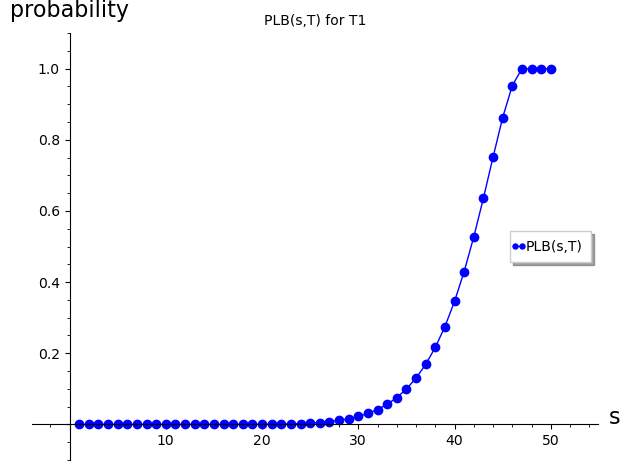

In [44]:
curve_T1 = PLB_curve(50,support_sizes(T1),s_min = 1,s_max = None)
print(curve_T1)
plot_T1 = list_plot(curve_T1, plotjoined=True, marker='o', color='blue', legend_label= 'PLB(s,T)', axes_labels=['s','probability'], title='PLB(s,T) for T1')
show(plot_T1, legend_loc = 'center right',axes_pad =0.1)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 0.0), (7, 0.0), (8, 1.862618303037381e-09), (9, 1.756182971435245e-08), (10, 9.180047350684234e-08), (11, 3.51236594287049e-07), (12, 1.0976143571470282e-06), (13, 2.967949221725564e-06), (14, 7.191569268027328e-06), (15, 1.5981265040060728e-05), (16, 3.3104049011554364e-05), (17, 6.468607267964833e-05), (18, 0.00012031609348974031), (19, 0.00021452252113328535), (20, 0.00036871048856173085), (21, 0.0006136575446729749), (22, 0.0009926793452058132), (23, 0.0015655898803752265), (24, 0.002413593807339271), (25, 0.003645260342785478), (26, 0.005403737041015873), (27, 0.007875364313186375), (28, 0.0112998420705898), (29, 0.01598206905698348), (30, 0.02230570825971585), (31, 0.030748404580420722), (32, 0.04189835670929692), (33, 0.05647156593222897), (34, 0.07532845812832771), (35, 0.09948755010696955), (36, 0.13013214967640727), (37, 0.16860328383964662), (38, 0.21636731217096553), (39, 0.27493849341260584), (40, 0.34572248270803985),

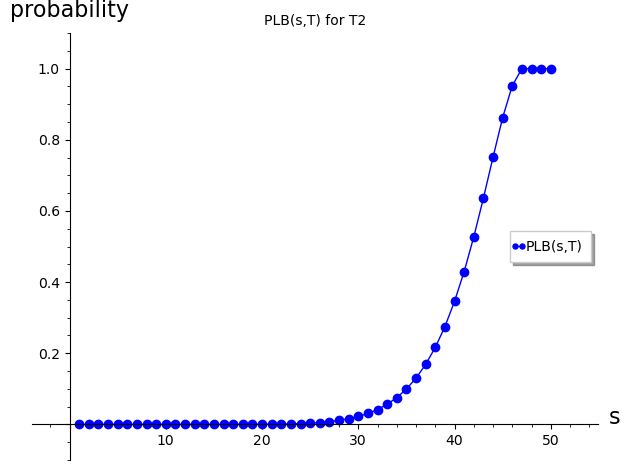

In [45]:
curve_T2 = PLB_curve(50,support_sizes(T2),s_min = 1,s_max = None)
print(curve_T2)
plot_T2 = list_plot(curve_T2, plotjoined=True, marker='o', color='blue', legend_label= 'PLB(s,T)', axes_labels=['s','probability'], title='PLB(s,T) for T2')
show(plot_T2, legend_loc = 'center right',axes_pad =0.1)

## A better lower bound: using witness supports $W_i = \mathrm{supp}(\bm{\lambda}_{T_i})$

Suppose $\mathcal{T}_i = \{T_1,\dots,T_b\}$ is a set of certified planted supports. We have $\bm{\lambda}_{T_i}^\top (\mathbf{g})_{T_i} = 1$. Let
\begin{align}
    W_i &\stackrel{\text{def}}{=} \mathrm{supp}(\bm{\lambda}_{(T_i)})\\
    w_i &\stackrel{\text{def}}{=} |W_i| = wt_H(\bm{\lambda}_{T_i})
\end{align}
If $W_i \subseteq S$, then we can embed $\bm{\lambda}_{T_i}$ into a vector $\bm{\lambda}_S\in \mathbb{Z}^{|S|}$ by placing non-zero entries on the coordinates of $W_i \subseteq S$ and zeros elsewhere. We have $\bm{\lambda}_S \in \ker_\mathbb{Z}(\mathbf{H}_{(S)})$. Since $\bm{\lambda}[j] = 0$ for $j \notin W_i$, we have $\bm{\lambda}_S^\top (\mathbf{g})_{S} = \bm{\lambda}_{T_i}^\top (\mathbf{g})_{T_i} = 1$. This makes $W_i \subseteq S \Rightarrow \mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$.

Since $T_i$ for $i \in [1,b]$ are disjoint and $W_i \subseteq T_i$, $W_i$ for $i \in [1,b]$ are also disjoint, we have $\Pr[W_i \subseteq S] \geq \Pr[T_i \subseteq S]$ for random $S\subseteq [1,n]$. For $n \in \mathbb{Z}^+$, $s \in [1,n]$, and a collection of disjoint sets $\mathcal{W} = \{W_1,\dots,W_b\}$ where $W_i = \mathrm{supp}(\bm{\lambda}_{T_i})$, we define
\begin{align}
    \Pr_{witness}(s,\mathcal{W}) \stackrel{\text{def}}{=} \frac{1}{\binom{n}{s}}\cdot\sum_{\emptyset \neq J \subseteq [1,b]} (-1)^{|J| + 1} \cdot \binom{n-\sum_{i \in J}w_i}{s-\sum_{i\in J} w_i},
\end{align}
where $w_i = |W_i|$ for $i \in [1,b]$. We have $\Pr_{witness}(s,\mathcal{W}) \geq \Pr_{LB}(s,\mathcal{T})$.

We first consider the following helper function to get the list of $w_i$ from the list of $\bm{\lambda_{T_i}}$.

In [46]:
# list of hamming weight
def hamming_weight_list(List_of_v):
    return [hamming_weight(v) for v in List_of_v]

# finding the witness_size
def witness_sizes(Lambdas):
    return hamming_weight_list(Lambdas)

In [47]:
show(lambdas1)
show(witness_sizes(lambdas1))

[(1, 1, 1, 0, -1, 0, 0, -1, -1),
 (1, 1, -1, -1, 0, -1, 0, 1, 0),
 (0, 1, -1, -1, 1, -1, 1, 0),
 (1, 0, -3, 0, 3, -3, -1, -3, 3, 1, 0, 1, -1, 0, -1, 2, 1)]

[6, 6, 6, 13]

PWitness(n,s,witness_sizes)

In [48]:
def PWitness(n, s, witness_sizes):
    """
    Exact Pr_witness(s,{W1,...,Wb}) using inclusion-exclusion.
    witness_sizes = [w1,...,wb], disjoint supports.
    """
    b = len(witness_sizes)
    denom = binomial(n, s)
    total = ZZ(0)

    # Iterate over nonempty subsets J via bitmasks
    for mask in range(1, 1 << b):
        u = 0
        bits = 0
        for i in range(b):
            if (mask >> i) & 1:
                u += witness_sizes[i]
                bits += 1
        if u > s:
            continue

        term = binomial(n - u, s - u)
        if bits % 2 == 1:
            total += term
        else:
            total -= term

    return float(total / denom)

Constructing the curve for $\Pr_{witness}(s,\mathcal{W})$ for a given $\mathcal{W}$ and $1\leq s \leq n$. 

In [49]:
def PWitness_curve(n, witness_sizes, s_min=1, s_max=None):
    """
    Return the PWitness curve as a list of pairs [(s, PWitness(n,s,witness_sizes)), ...].

    Parameters
    ----------
    n : int
        Total number of indices.
    witness_sizes : list of int
        witness_sizes = [w1,...,wb] associated with disjoint supports.
    s_min : int
        Minimum s to include (default 1).
    s_max : int or None
        Maximum s to include, inclusive (default n).

    Returns
    -------
    list of tuples
        [(s, QQ probability), ...]
    """
    n = int(n)
    witness_sizes = list(witness_sizes)

    if s_max is None:
        s_max = n

    s_min = int(s_min)
    s_max = int(s_max)

    # Clamp the range safely
    if s_min < 0:
        s_min = 0
    if s_max > n:
        s_max = n

    curve = []
    for s in range(s_min, s_max + 1):
        curve.append((s, PWitness(n, s, witness_sizes)))
    return curve

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 1.8878966942928882e-07), (7, 1.3215276860050219e-06), (8, 5.2861107440200875e-06), (9, 1.5858332232060262e-05), (10, 3.9645830580150654e-05), (11, 8.722082727633145e-05), (12, 0.000174441629840895), (13, 0.0003239627543056857), (14, 0.000566933167977397), (15, 0.0009448813475301053), (16, 0.0015117842754570105), (17, 0.002336314739297684), (18, 0.0035042568187794334), (19, 0.005121072593558601), (20, 0.007314593106257153), (21, 0.010237792581498883), (22, 0.014071585826355338), (23, 0.019027563500189342), (24, 0.025350547288129504), (25, 0.03332080549242641), (26, 0.043255717366936154), (27, 0.05551060916862917), (28, 0.07047840255099591), (29, 0.08858761024652113), (30, 0.11029807427008713), (31, 0.1360936502393928), (32, 0.16647076916463618), (33, 0.2019214121052353), (34, 0.2429084550063888), (35, 0.2898305153788555), (36, 0.3429723180144562), (37, 0.4024352565746377), (38, 0.46804160187574045), (39, 0.5392056453797337), (40, 0.

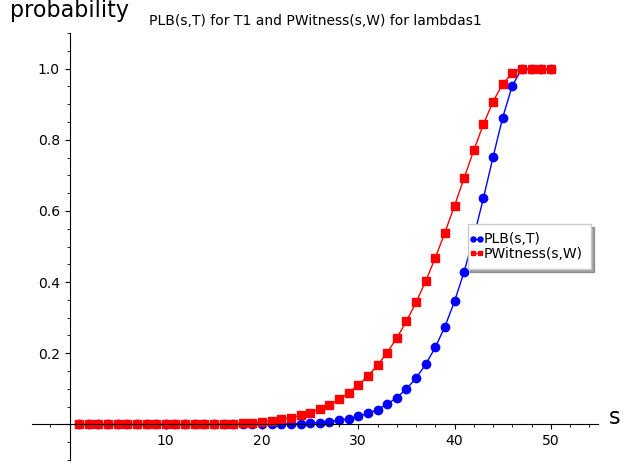

In [50]:
curve_lambdas1 = PWitness_curve(50,witness_sizes(lambdas1),s_min = 1,s_max = None)
print(curve_lambdas1)
plot_lambdas1 = list_plot(curve_lambdas1, plotjoined=True, marker = 's',color='red', legend_label = 'PWitness(s,W)',axes_labels=['s','probability'], title='PWitness(s,W) for lambdas1')
# show(plot_lambdas1, legend_loc = 'center right', axes_pad=0.1)
show(plot_T1+plot_lambdas1,axes_labels = ['s','probability'],title='PLB(s,T) for T1 and PWitness(s,W) for lambdas1',legend_loc = 'center right', axes_pad = 0.1)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 1.8878966942928882e-07), (7, 1.3215276860050219e-06), (8, 5.2861107440200875e-06), (9, 1.5858332232060262e-05), (10, 3.9645830580150654e-05), (11, 8.722082727633145e-05), (12, 0.000174441629840895), (13, 0.0003239627543056857), (14, 0.000566933167977397), (15, 0.0009448813475301053), (16, 0.0015117842754570105), (17, 0.002336314739297684), (18, 0.0035042568187794334), (19, 0.005121072593558601), (20, 0.007314593106257153), (21, 0.010237792581498883), (22, 0.014071585826355338), (23, 0.019027563500189342), (24, 0.025350547288129504), (25, 0.03332080549242641), (26, 0.043255717366936154), (27, 0.05551060916862917), (28, 0.07047840255099591), (29, 0.08858761024652113), (30, 0.11029807427008713), (31, 0.1360936502393928), (32, 0.16647076916463618), (33, 0.2019214121052353), (34, 0.2429084550063888), (35, 0.2898305153788555), (36, 0.3429723180144562), (37, 0.4024352565746377), (38, 0.46804160187574045), (39, 0.5392056453797337), (40, 0.

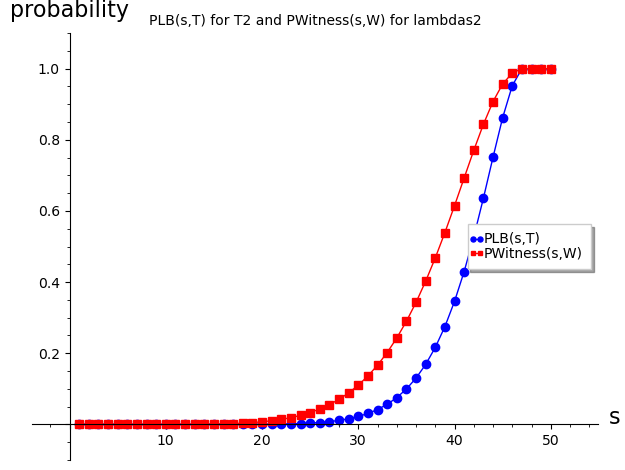

In [51]:
curve_lambdas2 = PWitness_curve(50,witness_sizes(lambdas2),s_min = 1,s_max = None)
print(curve_lambdas2)
plot_lambdas2 = list_plot(curve_lambdas2, plotjoined=True, marker = 's',color='red', legend_label = 'PWitness(s,W)',axes_labels=['s','probability'], title='PWitness(s,W) for lambdas2')
# show(plot_lambdas1_ori, legend_loc = 'center right', axes_pad=0.1)
show(plot_T2+plot_lambdas2,axes_labels = ['s','probability'],title='PLB(s,T) for T2 and PWitness(s,W) for lambdas2',legend_loc = 'center right', axes_pad = 0.1)

## Actual lower bound based on experiment

### Exact enumeration

Recall that a scheme is $\epsilon(n)$-correct with correctness threshold $k_c \in [1,n]$ if for every $T \subseteq [1,n]$ with $|T| \geq k_c$, we have $\Pr_{\mathbf{G}\gets\mathcal{D}_\mathbf{G}}[\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_T)] \geq 1-\epsilon(n)$.

We define the function **check_span(G)** that takes a matrix $\mathbf{G} \in \mathbb{Z}^{s \times k}$ as input and returns true if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G})$.

Suppose $\mathbf{G} \in \mathbb{Z}^{s \times k}$ and $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G})$. This means $\mathbf{e}_1^\top$ can be obtained using integer elementary row operations on $\mathbf{G}$. If $\mathbf{R}_\mathbf{G} \in \mathbb{Z}^{s \times k}$ is the row-HNF of $\mathbf{G}$, then it is unique lower triangular matrix such that $\mathbf{R}_\mathbf{G} = \mathbf{U}_\mathbf{G} \mathbf{G}$ for some $\mathbf{U}_\mathbf{G} \in GL_{|S|}(\mathbb{Z})$. By the row-HNF pivot/remainder condition, if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G})$, we must have $\mathbf{R}_\mathbf{G}[1,\cdot] = \mathbf{e}_1^\top$ (i.e., the first row of $\mathbf{R}_\mathbf{G}$ ($1$-based indexing) is $\mathbf{e}_1^\top$. In short: $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}) \Leftrightarrow \mathbf{R}_\mathbf{G}[1,\cdot] = \mathbf{e}_1^\top$.

We define the function **check_span_S(G,S)** that takes a matrix $\mathbf{G} \in \mathbb{Z}^{n \times k}$ and $S \subseteq [0,n-1]$ ($0$-based-index) as input and returns true if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$.

In [52]:
def check_span(G):
    """
    Returns True if e_1^T is in the integer row span of G, by checking if the first row of the row HNF of G is e_1^T.
    """
    # If there are no rows, row span is {0}
    if G.nrows() == 0:
        return False

    k = G.ncols()
    e1 = vector(ZZ, [1] + [0] * (k - 1))

    R = G.hermite_form() # unique row HNF of G

    # If HNF has no rows (rare edge case), fail safely
    if R.nrows() == 0:
        return False

    return R[0] == e1 # check if first row is e_1^T

def check_span_S(G, S):
    """
    Return True iff e_1^T is in the integer row span of G_S,
    where G_S is the submatrix consisting of rows of G indexed by S.

    Assumes:
      - indices in S are 0-based and lie in {0,...,n-1}.
    """
    # If S is empty, then G_S has no rows, so its row span is {0}
    if len(S) == 0:
        return False

    # quick reject: if first column is all zeros on S, cannot reach e1
    has_nonzero_col0 = False
    for i in S:
        if G[i, 0] != 0:
            has_nonzero_col0 = True
            break
    if not has_nonzero_col0:
        return False

    G_S = G.matrix_from_rows(S)
    return check_span(G_S)

We define $\Pr_{actual}(s,\mathbf{G})$ for a fixed matrix $\mathbf{G} \in \mathbb{Z}^{n \times k}$ and $s \in [1,n]$ as
\begin{align}
    \Pr_{actual}(s,\mathbf{G}) &\stackrel{\text{def}}{=} \frac{|\{S\subseteq [1,n]: \left(|S| = s\right) \land \left(\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)\right)\}|}{|\{S\subseteq [1,n]: \left(|S| = s\right)\}|}\\
    &= \frac{1}{\binom{n}{s}}|\{S\subseteq [1,n]: \left(|S| = s\right) \land \left(\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)\right)\}|
\end{align}

In [53]:
from itertools import combinations
from sage.all import binomial, QQ

def Pactual(s, G):
    """
    Exact Pr_actual(s, G) by enumerating all subsets S of size s.
    Works for small n (e.g., n=20).
    Returns an exact rational in QQ.
    """
    n = G.nrows()
    total = binomial(n, s)
    if total == 0:
        return QQ(0)

    good = 0
    for S in combinations(range(n), s):
        if check_span_S(G, S):
            good += 1

    return QQ(good) / QQ(total)

Some test for **Pactual(s,G)**.

In [54]:
%%time
# show(G1)
p46 = Pactual(46,G1)
#p45 = Pactual(45,G1)
#p44 = Pactual(44,G1)
show("46","--",p46,"--",1-p46)
#show("45","--",p45,"--",1-p45)
#show("44","--",p44,"--",1-p44)

'46' '--' 1 '--' 0

CPU times: user 47.4 s, sys: 0 ns, total: 47.4 s
Wall time: 47.4 s


Constructing the curve for $\Pr_{actual}(s,\mathbf{G})$ for a given $\mathbf{G}$ and $1\leq s\leq n$. 

In [55]:
def Pactual_curve(G, s_min=1, s_max=None):
    """
    Return the Pactual curve as a list of pairs [(s, Pactual(s,G)) for s in [s_min..s_max]] exactly (small n only).

    Parameters
    -----------
    s_min : int
        Minimum s to include (default 1).
    s_max : int or None
        Maximum s to include, inclusive (default n).

    Returns
    --------
    list of tuples
        [(s, QQ probability), ...]
    """
    n = G.nrows()
    if s_max is None:
        s_max = n
    return [(s, Pactual(s, G)) for s in range(s_min, s_max + 1)]

### With Monte Carlo simulation

We use a Monte Carlo simulation to estimate $\Pr_{actual}(s,\mathbf{G})$ because the number of subsets of $S \subseteq [1,n]$ is too large, and checking the HNF property takes a long time. We first consider the following helper function to obtain $N$ random distinct subsets of size $t$. We first consider the following helper function to obtain $N$ random distinct subsets of size $t$.

Some theory: let $p = \Pr_{actual}(s,\mathbf{G})$ and $\hat{p}$ be its Monte Carlo estimate. By Hoeffding's inequality, for any $\epsilon > 0$ and $\delta \in (0,1)$
\begin{align*}
    \Pr[|\hat{p}-p| \geq \epsilon] \leq 2 \exp(-2N\epsilon^2),
\end{align*}
by setting the right-hand side equal to $\delta$ and solving for $N$, we get:
\begin{align*}
    N \geq \frac{\ln(2/\delta)}{2\epsilon^2}.
\end{align*}
We obtain $N$ as the minimum number of samples sufficient to guarantee $|\hat{p}-p|< \epsilon$ with probability at least $1-\delta$.

We first consider the following helper function to obtain $N$ random distinct subsets of size $t$.

In [56]:
import random

# sampling N distinct random subsets of [0,n-1] of size t 
def sample_unique_subsets(n, t, N, seed=0):
    rng = random.Random(int(seed))
    seen = set()
    out = []
    while len(out) < N:
        S = tuple(sorted(rng.sample(range(n), t)))
        if S not in seen:
            seen.add(S)
            out.append(list(S))
    return out

**Pactual_MC(s, G, N, seed)** compute $\Pr_{actual}(s,\mathbf{G})$ using Monte Carlo simulation for $N$ (default value $1000$) distinct subsets using seed $seed$ (defaulf value $0$).

In [57]:
import random

def Pactual_MC(s, G, N=1000, seed=0):
    """
    Monte Carlo estimate of P_actual(s, G) using N *distinct* random subsets S of size s.
    Uses sample_unique_subsets, so subsets do not repeat within the sample.

    Returns:
      p_hat
    """
    n = G.nrows()
    s = int(s)
    assert 1 <= s <= n

    total = int(binomial(n, s))
    if N > total:
        raise ValueError(f"N={N} exceeds number of distinct subsets C({n},{s})={total}")

    samples = sample_unique_subsets(n, s, N, seed=seed)

    success = 0
    for S in samples:
        if check_span_S(G, S):
            success += 1

    p_hat = success / N
    return p_hat

Some testing for Pactual_MC.

In [58]:
%%time
show(G1)
p30_MC = Pactual_MC(30,G1, N = 100000, seed = 0)
show("30_MC","--",p30_MC,"--",1-p30_MC)

50 x 25 dense matrix over Integer Ring (use the '.str()' method to see the entries)

'30_MC' '--' 24693/25000 '--' 307/25000

CPU times: user 15.8 s, sys: 19.8 ms, total: 15.8 s
Wall time: 15.8 s


Constructing the curve for $\Pr_{actual}(s,\mathbf{G})$ for a given $\mathbf{G}$ and $1\leq s\leq n$ using Monte Carlo simulation.

In [59]:
def Pactual_curve_MC(G, N = 1000, seed=0, s_min=1, s_max=None):
    """
    Return the Pactual_MC curve as a list of pairs [(s, Pactual_MC(s,G,N,seed)) for s in [s_min..s_max]] using Monte Carlo simulation
    with N samples and seed=seed.

    Parameters
    -----------
    s_min : int
        Minimum s to include (default 1).
    s_max : int or None
        Maximum s to include, inclusive (default n).

    Returns
    --------
    list of tuples
        [(s, QQ probability), ...]
    """
    n = G.nrows()
    if s_max is None:
        s_max = n
    return [(s, Pactual_MC(s, G,N,seed)) for s in range(s_min, s_max + 1)]

Some testing.

In [60]:
%%time
curve_MC_G1_test1 = Pactual_curve_MC(G1,N=100000,seed=0,s_min = 30, s_max = 40)
print(curve_MC_G1_test1)

[(30, 24693/25000), (31, 99403/100000), (32, 99709/100000), (33, 3121/3125), (34, 49977/50000), (35, 99979/100000), (36, 49997/50000), (37, 19999/20000), (38, 1), (39, 49999/50000), (40, 1)]
CPU times: user 3min 13s, sys: 164 ms, total: 3min 13s
Wall time: 3min 13s


### Computations and Results

We only consider the case where $\mathbf{H}$ is randomized and $\mathbf{G}$ is obtained using either the balanced or the densest filling approach (the sparsest filling approach experimentally tends to give a lower correctness probability in the earlier case).

#### Computations and results for $\mathbf{G}_1$

In [61]:
%%time
show(G1)
# k_c_det = 47
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 1000000, part 3: 16-30 (MC, N = 500000), part 4: 31-40 (MC, N = 1000000), part 5: 41-44 (MC, N = 1000000), part 6: 45-46 (exact), part 7: 47-50 (exact = 1)  
curve_actual_G1_part_1 = [(s, 0.0) for s in range(1,5+1)]
curve_actual_G1_part_7 = [(s,1.0) for s in range(47,50+1)]
print(curve_actual_G1_part_1)
print(curve_actual_G1_part_7)

50 x 25 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 0.000000000000000), (2, 0.000000000000000), (3, 0.000000000000000), (4, 0.000000000000000), (5, 0.000000000000000)]
[(47, 1.00000000000000), (48, 1.00000000000000), (49, 1.00000000000000), (50, 1.00000000000000)]
CPU times: user 7.79 ms, sys: 0 ns, total: 7.79 ms
Wall time: 7.27 ms


In [62]:
%%time
# show(G1)
# k_c_det = 47
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 1000000, part 3: 16-30 (MC, N = 500000), part 4: 31-40 (MC, N = 1000000), part 5: 41-44 (MC, N = 1000000), part 6: 45-46 (exact), part 7: 47-50 (exact = 1)  
curve_actual_G1_part_2 = Pactual_curve_MC(G1,N=1000000,seed=0,s_min=6,s_max=15)
print(curve_actual_G1_part_2)

[(6, 0), (7, 0), (8, 9/1000000), (9, 7/250000), (10, 27/500000), (11, 2/15625), (12, 1/4000), (13, 213/500000), (14, 763/1000000), (15, 671/500000)]
CPU times: user 10min 29s, sys: 843 ms, total: 10min 30s
Wall time: 10min 30s


In [63]:
%%time
# show(G1)
# k_c_det = 47
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 1000000, part 3: 16-30 (MC, N = 500000), part 4: 31-40 (MC, N = 1000000), part 5: 41-44 (MC, N = 1000000), part 6: 45-46 (exact), part 7: 47-50 (exact = 1)  
curve_actual_G1_part_3 = Pactual_curve_MC(G1,N=500000,seed=0,s_min=16,s_max=30)
print(curve_actual_G1_part_3)

[(16, 1159/500000), (17, 923/250000), (18, 761/125000), (19, 4787/500000), (20, 243/15625), (21, 13039/500000), (22, 11561/250000), (23, 22629/250000), (24, 9663/50000), (25, 10321/25000), (26, 11351/15625), (27, 437843/500000), (28, 471143/500000), (29, 121673/125000), (30, 246839/250000)]
CPU times: user 17min 1s, sys: 923 ms, total: 17min 2s
Wall time: 17min 2s


In [64]:
%%time
# show(G1)
# k_c_det = 47
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 1000000, part 3: 16-30 (MC, N = 500000), part 4: 31-40 (MC, N = 1000000), part 5: 41-44 (MC, N = 1000000), part 6: 45-46 (exact), part 7: 47-50 (exact = 1)  
curve_actual_G1_part_4 = Pactual_curve_MC(G1,N=1000000,seed=0,s_min=31,s_max=40)
print(curve_actual_G1_part_4)

[(31, 994027/1000000), (32, 997157/1000000), (33, 124843/125000), (34, 99951/100000), (35, 12497/12500), (36, 999911/1000000), (37, 199993/200000), (38, 49999/50000), (39, 999993/1000000), (40, 1)]
CPU times: user 34min 29s, sys: 3.95 s, total: 34min 32s
Wall time: 34min 33s


In [65]:
%%time
# show(G1)
# k_c_det = 47
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 1000000, part 3: 16-30 (MC, N = 500000), part 4: 31-40 (MC, N = 1000000), part 5: 41-44 (MC, N = 1000000), part 6: 45-46 (exact), part 7: 47-50 (exact = 1)  
curve_actual_G1_part_5 = Pactual_curve_MC(G1,N=1000000,seed=0,s_min=41,s_max=44)
print(curve_actual_G1_part_5)

[(41, 1), (42, 1), (43, 1), (44, 1)]
CPU times: user 15min 49s, sys: 1.54 s, total: 15min 51s
Wall time: 15min 51s


In [66]:
%%time
# show(G1)
# k_c_det = 47
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 1000000, part 3: 16-30 (MC, N = 500000), part 4: 31-40 (MC, N = 1000000), part 5: 41-44 (MC, N = 1000000), part 6: 45-46 (exact), part 7: 47-50 (exact = 1)  
curve_actual_G1_part_6 = Pactual_curve(G1,s_min=45,s_max=46)
print(curve_actual_G1_part_6)

[(45, 1), (46, 1)]
CPU times: user 9min 11s, sys: 28 ms, total: 9min 11s
Wall time: 9min 11s


In [67]:
curve_actual_G1 = curve_actual_G1_part_1 + curve_actual_G1_part_2 + curve_actual_G1_part_3 + curve_actual_G1_part_4 + curve_actual_G1_part_5 +curve_actual_G1_part_6+curve_actual_G1_part_7 
print(curve_actual_G1)

[(1, 0.000000000000000), (2, 0.000000000000000), (3, 0.000000000000000), (4, 0.000000000000000), (5, 0.000000000000000), (6, 0), (7, 0), (8, 9/1000000), (9, 7/250000), (10, 27/500000), (11, 2/15625), (12, 1/4000), (13, 213/500000), (14, 763/1000000), (15, 671/500000), (16, 1159/500000), (17, 923/250000), (18, 761/125000), (19, 4787/500000), (20, 243/15625), (21, 13039/500000), (22, 11561/250000), (23, 22629/250000), (24, 9663/50000), (25, 10321/25000), (26, 11351/15625), (27, 437843/500000), (28, 471143/500000), (29, 121673/125000), (30, 246839/250000), (31, 994027/1000000), (32, 997157/1000000), (33, 124843/125000), (34, 99951/100000), (35, 12497/12500), (36, 999911/1000000), (37, 199993/200000), (38, 49999/50000), (39, 999993/1000000), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1.00000000000000), (48, 1.00000000000000), (49, 1.00000000000000), (50, 1.00000000000000)]


Presenting using graph.

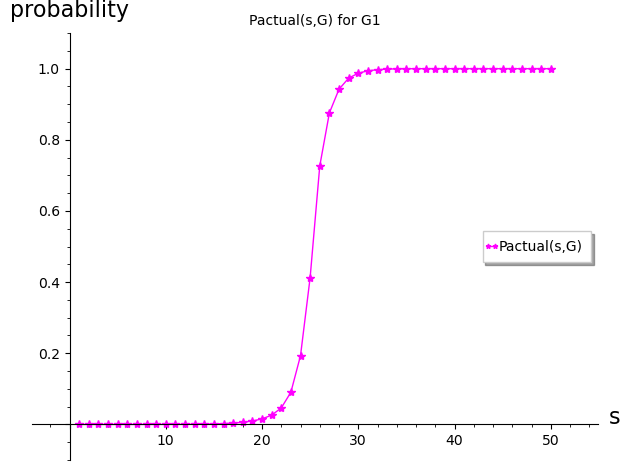

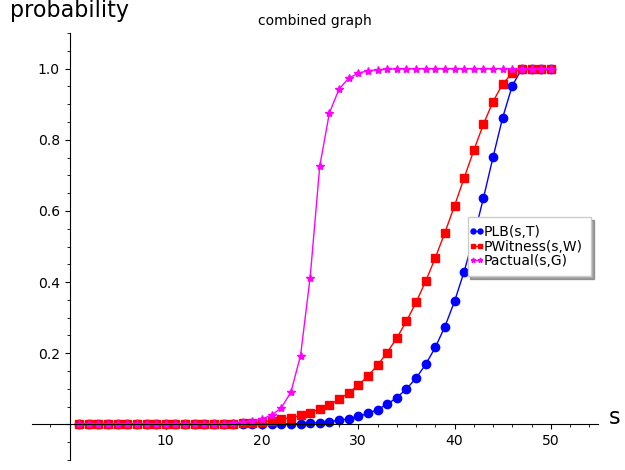

In [68]:
plot_G1 = list_plot(curve_actual_G1, plotjoined=True, marker='*', color = 'magenta', legend_label = 'Pactual(s,G)',axes_labels=['s','probability'], title='Pactual(s,G) for G1')
show(plot_G1, legend_loc = 'center right', axes_pad=0.1)
show(plot_T1+plot_lambdas1+plot_G1, axes_labels=['s','probability'],title='combined graph',legend_loc='center right', axes_pad =0.1)

Presenting using table.

In [69]:
print(curve_T1)
print(curve_lambdas1)
print(curve_actual_G1)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 0.0), (7, 0.0), (8, 1.862618303037381e-09), (9, 1.756182971435245e-08), (10, 9.180047350684234e-08), (11, 3.51236594287049e-07), (12, 1.0976143571470282e-06), (13, 2.967949221725564e-06), (14, 7.191569268027328e-06), (15, 1.5981265040060728e-05), (16, 3.3104049011554364e-05), (17, 6.468607267964833e-05), (18, 0.00012031609348974031), (19, 0.00021452252113328535), (20, 0.00036871048856173085), (21, 0.0006136575446729749), (22, 0.0009926793452058132), (23, 0.0015655898803752265), (24, 0.002413593807339271), (25, 0.003645260342785478), (26, 0.005403737041015873), (27, 0.007875364313186375), (28, 0.0112998420705898), (29, 0.01598206905698348), (30, 0.02230570825971585), (31, 0.030748404580420722), (32, 0.04189835670929692), (33, 0.05647156593222897), (34, 0.07532845812832771), (35, 0.09948755010696955), (36, 0.13013214967640727), (37, 0.16860328383964662), (38, 0.21636731217096553), (39, 0.27493849341260584), (40, 0.34572248270803985),

In [70]:
import pandas as pd

def correctness(curve_T, curve_lambdas, curve_actual_G, n):
    '''
    Creating a combined table of curve_T, curve_lambdas, and curve_actual_G.
    Numbers are rounded to 8 decimal places.
    '''
    # Convert each list of pairs into a small dataframe
    df_curve_T          = pd.DataFrame(curve_T,          columns=['t', 'Pr_LB(t,T)'])
    df_curve_lambdas    = pd.DataFrame(curve_lambdas,    columns=['t', 'Pr_Witness(t,W)'])
    df_curve_actual_G   = pd.DataFrame(curve_actual_G,   columns=['t', 'Pr_actual(t,G)'])

    # Merge on 't' using outer join
    df = df_curve_actual_G \
            .merge(df_curve_lambdas, on='t', how='outer') \
            .merge(df_curve_T,       on='t', how='outer')

    # Convert all value columns to float and round to 8 decimal places
    for col in ['Pr_actual(t,G)', 'Pr_Witness(t,W)', 'Pr_LB(t,T)']:
        df[col] = df[col].apply(lambda x: round(float(x), 8))

    df = df.sort_values('t', ascending=False).reset_index(drop=True)

    caption = f"Experiment for correctness and privacy threshold for n = {n}"
    display(df.style
              .set_caption(caption)
              .format({'Pr_actual(t,G)' : '{:.8f}',
                       'Pr_Witness(t,W)': '{:.8f}',
                       'Pr_LB(t,T)'    : '{:.8f}'}))

In [71]:
correctness(curve_T1,curve_lambdas1, curve_actual_G1, 50)

,t,"Pr_actual(t,G)","Pr_Witness(t,W)","Pr_LB(t,T)"
0,50,1.00000000,1.00000000,1.00000000
1,49,1.00000000,1.00000000,1.00000000
2,48,1.00000000,1.00000000,1.00000000
3,47,1.00000000,1.00000000,1.00000000
4,46,1.00000000,0.98780721,0.95216674
5,45,1.00000000,0.95692764,0.86221941
6,44,1.00000000,0.90753799,0.75101286
7,43,1.00000000,0.84362774,0.63580313
8,42,1.00000000,0.77041002,0.52700801
9,41,1.00000000,0.69280035,0.42972219


#### Computations and results for $\mathbf{G}_2$

In [72]:
%%time
show(G2)
# k_c_det = 47
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 1000000, part 3: 16-30 (MC, N = 500000), part 4: 31-40 (MC, N = 1000000), part 5: 41-44 (MC, N = 1000000), part 6: 45-46 (exact), part 7: 47-50 (exact = 1)  
curve_actual_G2_part_1 = [(s, 0.0) for s in range(1,5+1)]
curve_actual_G2_part_7 = [(s,1.0) for s in range(47,50+1)]
print(curve_actual_G2_part_1)
print(curve_actual_G2_part_7 )

50 x 25 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 0.000000000000000), (2, 0.000000000000000), (3, 0.000000000000000), (4, 0.000000000000000), (5, 0.000000000000000)]
[(47, 1.00000000000000), (48, 1.00000000000000), (49, 1.00000000000000), (50, 1.00000000000000)]
CPU times: user 10.4 ms, sys: 0 ns, total: 10.4 ms
Wall time: 9.84 ms


In [73]:
%%time
# show(G2)
# k_c_det = 47
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 1000000, part 3: 16-30 (MC, N = 500000), part 4: 31-40 (MC, N = 1000000), part 5: 41-44 (MC, N = 1000000), part 6: 45-46 (exact), part 7: 47-50 (exact = 1)  
curve_actual_G2_part_2 = Pactual_curve_MC(G2,N=1000000,seed=0,s_min=6,s_max=15)
print(curve_actual_G2_part_2)

[(6, 0), (7, 1/500000), (8, 11/1000000), (9, 37/1000000), (10, 67/1000000), (11, 39/250000), (12, 151/500000), (13, 53/100000), (14, 963/1000000), (15, 829/500000)]
CPU times: user 10min 33s, sys: 664 ms, total: 10min 34s
Wall time: 10min 34s


In [74]:
%%time
# show(G2)
# k_c_det = 47
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 1000000, part 3: 16-30 (MC, N = 500000), part 4: 31-40 (MC, N = 1000000), part 5: 41-44 (MC, N = 1000000), part 6: 45-46 (exact), part 7: 47-50 (exact = 1)  
curve_actual_G2_part_3 = Pactual_curve_MC(G2,N=500000,seed=0,s_min=16,s_max=30)
print(curve_actual_G2_part_3)

[(16, 89/31250), (17, 2167/500000), (18, 891/125000), (19, 277/25000), (20, 8693/500000), (21, 7143/250000), (22, 6083/125000), (23, 11631/125000), (24, 24477/125000), (25, 41311/100000), (26, 181817/250000), (27, 13628/15625), (28, 58639/62500), (29, 484679/500000), (30, 49229/50000)]
CPU times: user 17min 26s, sys: 648 ms, total: 17min 27s
Wall time: 17min 27s


In [75]:
%%time
# show(G2)
# k_c_det = 47
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 1000000, part 3: 16-30 (MC, N = 500000), part 4: 31-40 (MC, N = 1000000), part 5: 41-44 (MC, N = 1000000), part 6: 45-46 (exact), part 7: 47-50 (exact = 1)  
curve_actual_G2_part_4 = Pactual_curve_MC(G2,N=1000000,seed=0,s_min=31,s_max=40)
print(curve_actual_G2_part_4)

[(31, 198397/200000), (32, 99581/100000), (33, 199551/200000), (34, 499431/500000), (35, 999353/1000000), (36, 499831/500000), (37, 999861/1000000), (38, 999907/1000000), (39, 19999/20000), (40, 499989/500000)]
CPU times: user 35min 7s, sys: 3.53 s, total: 35min 11s
Wall time: 35min 11s


In [76]:
%%time
# show(G2)
# k_c_det = 47
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 1000000, part 3: 16-30 (MC, N = 500000), part 4: 31-40 (MC, N = 1000000), part 5: 41-44 (MC, N = 1000000), part 6: 45-46 (exact), part 7: 47-50 (exact = 1)  
curve_actual_G2_part_5 = Pactual_curve_MC(G1,N=1000000,seed=0,s_min=41,s_max=44)
print(curve_actual_G2_part_5)

[(41, 1), (42, 1), (43, 1), (44, 1)]
CPU times: user 15min 35s, sys: 1.69 s, total: 15min 36s
Wall time: 15min 36s


In [77]:
%%time
# show(G2)
# k_c_det = 47
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 1000000, part 3: 16-30 (MC, N = 500000), part 4: 31-40 (MC, N = 1000000), part 5: 41-44 (MC, N = 1000000), part 6: 45-46 (exact), part 7: 47-50 (exact = 1)  
curve_actual_G2_part_6 = Pactual_curve(G2,s_min=45,s_max=46)
print(curve_actual_G2_part_6)

[(45, 1), (46, 1)]
CPU times: user 9min 10s, sys: 59.9 ms, total: 9min 10s
Wall time: 9min 10s


In [78]:
curve_actual_G2 = curve_actual_G2_part_1 + curve_actual_G2_part_2 + curve_actual_G2_part_3 + curve_actual_G2_part_4 + curve_actual_G2_part_5 +curve_actual_G2_part_6+curve_actual_G2_part_7
print(curve_actual_G2)

[(1, 0.000000000000000), (2, 0.000000000000000), (3, 0.000000000000000), (4, 0.000000000000000), (5, 0.000000000000000), (6, 0), (7, 1/500000), (8, 11/1000000), (9, 37/1000000), (10, 67/1000000), (11, 39/250000), (12, 151/500000), (13, 53/100000), (14, 963/1000000), (15, 829/500000), (16, 89/31250), (17, 2167/500000), (18, 891/125000), (19, 277/25000), (20, 8693/500000), (21, 7143/250000), (22, 6083/125000), (23, 11631/125000), (24, 24477/125000), (25, 41311/100000), (26, 181817/250000), (27, 13628/15625), (28, 58639/62500), (29, 484679/500000), (30, 49229/50000), (31, 198397/200000), (32, 99581/100000), (33, 199551/200000), (34, 499431/500000), (35, 999353/1000000), (36, 499831/500000), (37, 999861/1000000), (38, 999907/1000000), (39, 19999/20000), (40, 499989/500000), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1.00000000000000), (48, 1.00000000000000), (49, 1.00000000000000), (50, 1.00000000000000)]


Presenting using graph.

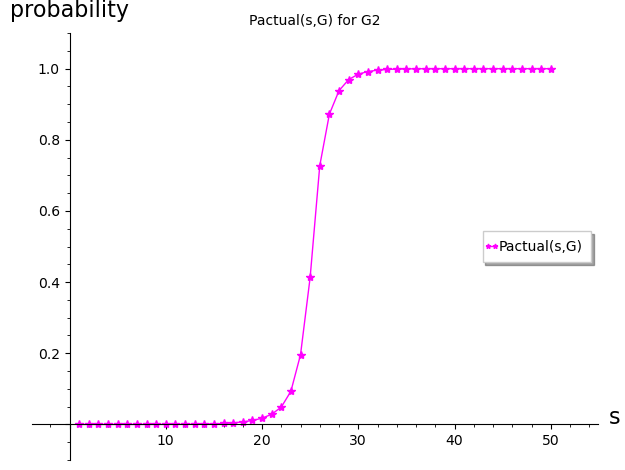

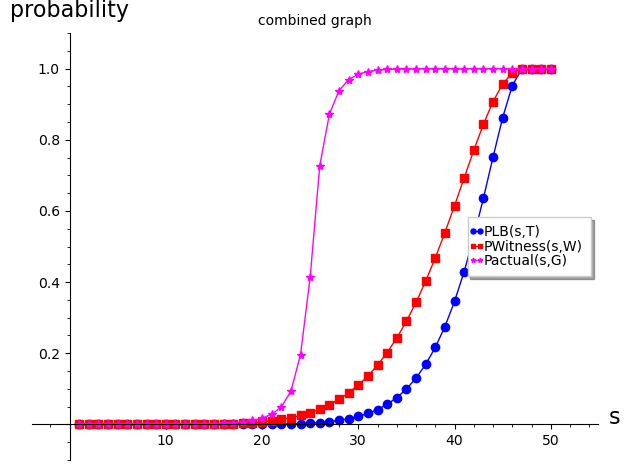

In [79]:
plot_G2 = list_plot(curve_actual_G2, plotjoined=True, marker='*', color = 'magenta', legend_label = 'Pactual(s,G)',axes_labels=['s','probability'], title='Pactual(s,G) for G2')
show(plot_G2, legend_loc = 'center right', axes_pad=0.1)
show(plot_T2+plot_lambdas2+plot_G2, axes_labels=['s','probability'],title='combined graph',legend_loc='center right', axes_pad =0.1)

Presenting using table.

In [80]:
print(curve_T2)
print(curve_lambdas2)
print(curve_actual_G2)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 0.0), (7, 0.0), (8, 1.862618303037381e-09), (9, 1.756182971435245e-08), (10, 9.180047350684234e-08), (11, 3.51236594287049e-07), (12, 1.0976143571470282e-06), (13, 2.967949221725564e-06), (14, 7.191569268027328e-06), (15, 1.5981265040060728e-05), (16, 3.3104049011554364e-05), (17, 6.468607267964833e-05), (18, 0.00012031609348974031), (19, 0.00021452252113328535), (20, 0.00036871048856173085), (21, 0.0006136575446729749), (22, 0.0009926793452058132), (23, 0.0015655898803752265), (24, 0.002413593807339271), (25, 0.003645260342785478), (26, 0.005403737041015873), (27, 0.007875364313186375), (28, 0.0112998420705898), (29, 0.01598206905698348), (30, 0.02230570825971585), (31, 0.030748404580420722), (32, 0.04189835670929692), (33, 0.05647156593222897), (34, 0.07532845812832771), (35, 0.09948755010696955), (36, 0.13013214967640727), (37, 0.16860328383964662), (38, 0.21636731217096553), (39, 0.27493849341260584), (40, 0.34572248270803985),

In [81]:
correctness(curve_T2,curve_lambdas2, curve_actual_G2, 50)

,t,"Pr_actual(t,G)","Pr_Witness(t,W)","Pr_LB(t,T)"
0,50,1.00000000,1.00000000,1.00000000
1,49,1.00000000,1.00000000,1.00000000
2,48,1.00000000,1.00000000,1.00000000
3,47,1.00000000,1.00000000,1.00000000
4,46,1.00000000,0.98780721,0.95216674
5,45,1.00000000,0.95692764,0.86221941
6,44,1.00000000,0.90753799,0.75101286
7,43,1.00000000,0.84362774,0.63580313
8,42,1.00000000,0.77041002,0.52700801
9,41,1.00000000,0.69280035,0.42972219


# Smallness of the reconstruction vector $\bm{\lambda}_S$ for some $S \subseteq [1,n]$

Previously, we argue that for $n \in \mathbb{Z}^+$ and $S \subseteq [1,n]$, $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$ if and only if $\mathbf{R}_{\mathbf{G}_S}[1,\cdot] = \mathbf{e}_1^\top$ where $\mathbf{R}_{\mathbf{G}_S}$ is the row-HNF of $\mathbf{G}_S$, i.e., there exists $\mathbf{U}_{\mathbf{G}_S} \in GL_{|S|}(\mathbf{Z})$ such that $\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}$.

Notice that $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$ if and only if there exists $\bm{\lambda}_S \in \mathbb{Z}^{|S|}$ such that $\bm{\lambda}_S^\top \mathbf{G}_S = \mathbf{e}_1^\top$. One solution of $\bm{\lambda}_S \in \mathbb{Z}^{|S|}$ is $\bm{\lambda}_S = \mathbf{U}_{\mathbf{G}_S}[1,\cdot]$ since we have $\mathbf{U}_{\mathbf{G}_S}[1,\cdot]\mathbf{G}_S = (\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S)[1,\cdot] = \mathbf{R}_{\mathbf{G}_S} = \mathbf{e}_1^\top$.

In this part, we are intested to experimentally determine:
1. $\|\mathbf{U}_{\mathbf{G}_S}[1,\cdot]\|_\infty$,
2. $wt_H(\mathbf{U}_{\mathbf{G}_S}[1,\cdot])$.

The following **check_smallness(G)** for a matrix $\mathbf{G}\in \mathbb{Z}^{s \times k}$ does the following:
1. Determine the row HNF of $\mathbf{G}$, i.e., $\mathbf{R}_\mathbf{G}$, and $\mathbf{U}_\mathbf{G} \in GL_s(\mathbb{Z})$ such that $\mathbf{U}_\mathbf{G}\mathbf{G} = \mathbf{R}_\mathbf{G}$.
2. Define $\bm{\lambda} = \mathbf{U}_\mathbf{G}[1,\cdot]$.
3. Compute $\|\bm{\lambda}\|_\infty = \max\{|\bm{\lambda}[i]: i \in [1,s]\}$ and $wt_H(\mathbf{\bm{\lambda}})=|\{i \in [1,s]: \bm{\lambda}[i] \neq 0\}|$.

The following **check_smallness_S(G,S)** for a matrix $\mathbf{G}_S \in \mathbb{Z}^{s \times k}$ and $S \subseteq [1,n]$ call **check_smallness(G_S)** for a submatrix $\mathbf{G}_S$.

In [61]:
def check_smallness(G):
    # determining ||U_G.row(0)||_infty and wt_H(U_G.row(0))
    if G.nrows() == 0:
        return (0, 0)
    R, U = G.hermite_form(transformation=True)
    lam = U[0,:]
    lam_entries = lam.list()
    
    linf = max(abs(x) for x in lam.list())
    # linf = max(abs(x) for x in lam) # buggy
    wt = sum(1 for x in lam.list() if x != 0)
    # wt = sum(1 for x in lam if x!= 0) # buggy
        
    return (linf, wt)


def check_smallness_S(G, S):
    # determining |||U_G_S[0,:]|_infty and wt_H(U_G_S[0,:])
    if len(S) == 0:
        return (0, 0)

    G_S = G.matrix_from_rows(S)
    return check_smallness(G_S)

## Exact enumeration

For a fixed $s \in [1,n]$, we want to know:
1. the maximum of $\|\mathbf{U}_{\mathbf{G}_S}[1,\cdot]\|_\infty$ where $S \subseteq [1,n]$ and $|S| = s$,
2. the maximum of $wt_H(\mathbf{U}_{\mathbf{G}_S}[1,\cdot])$ where $S \subseteq [1,n]$ and $|S| = s$.

We write the function **stats_smallness(s,G)** that returns a pair of these quantities.

In [62]:
from itertools import combinations

def stats_smallness(s,G):
    n = G.nrows()
    s = int(s)
    assert 1 <= s <= n
    linf_max = 0
    wt_max = 0
    for S in combinations(range(n),s):
        (linf,wt) = check_smallness_S(G,S)
        if linf > linf_max:
            linf_max = linf
        if wt > wt_max:
            wt_max = wt
    return (linf_max,wt_max)

Constructing the curve for $stats\_smallness(s,G)$ for a given $\mathbf{G}$ and $1\leq s\leq n$. 

In [63]:
def stats_smallness_curve(G, s_min=1, s_max=None):
    """
    Return a list of triples:
        [(s, max_linf, max_wt) for s in [s_min..s_max]]

    where:
      - max_linf = max_{|S|=s} ||U_{G_S}[0,:]||_infty
      - max_wt   = max_{|S|=s} wt_H(U_{G_S}[0,:])
      - S ranges over subsets of {0,...,n-1} (0-based) with |S|=s
      - U_{G_S} * G_S = R_{G_S} is the row-HNF with transformation.

    This calls stats_smallness(s, G) exactly once per s.
    """
    n = G.nrows()

    if s_max is None:
        s_max = n

    s_min = int(s_min)
    s_max = int(s_max)

    # Clamp to valid range
    if s_min < 1:
        s_min = 1
    if s_max > n:
        s_max = n
    if s_min > s_max:
        return []

    out = []
    for s in range(s_min, s_max + 1):
        linf_max, wt_max = stats_smallness(s, G)
        out.append((s, linf_max, wt_max))
    return out

Some testing.

In [64]:
%%time
curve_smallness_G1_test_1 = stats_smallness_curve(G1, s_min = 46, s_max = 50)
print(curve_smallness_G1_test_1)

[(46, 1306909985023922532730468, 32), (47, 220266400264200697, 30), (48, 46894644739464, 30), (49, 35170, 29), (50, 56, 24)]
CPU times: user 1min 12s, sys: 7.92 ms, total: 1min 12s
Wall time: 1min 12s


## With Monte Carlo simulation

For a fixed $s \in [1,n]$, we want to know:
1. the maximum of $\|\mathbf{U}_{\mathbf{G}_S}[1,\cdot]\|_\infty$ where $S \subseteq [1,n]$ and $|S| = s$,
2. the maximum of $wt_H(\mathbf{U}_{\mathbf{G}_S}[1,\cdot])$ where $S \subseteq [1,n]$ and $|S| = s$.

We write the function **stats_smallness(s,G,N,seed)** that returns a pair of these quantities using a Monte Carlo approach: instead of enumerating all subsets of size $s$, we generate $N$ distinct random subsets using seed $seed$. 

In [65]:
from itertools import combinations

def stats_smallness_MC(s,G, N=1000, seed = 0):
    '''
    Monte Carlo estimates of stats_smallness(s,G) using N *distinct* random subsets S of size s.
    Uses sample_unique_subsets, so subsets do not repeat within the sample.
    '''
    n = G.nrows()
    s = int(s)
    assert 1 <= s <= n
    linf_max = 0
    wt_max = 0

    total= int(binomial(n,s))
    if N > total:
        raise ValueError(f"N={N} exceeds number of distinct subsets C({n},{s})={total}")

    samples = sample_unique_subsets(n, s, N, seed=seed)
    
    for S in samples:
        (linf,wt) = check_smallness_S(G,S)
        if linf > linf_max:
            linf_max = linf
        if wt > wt_max:
            wt_max = wt
    return (linf_max,wt_max)

Constructing the curve for stats_smallness_MC(s,G, N, seed) for multiple s.

In [66]:
from sage.all import ZZ, binomial

def stats_smallness_curve_MC(G, N=1000, seed=0, repeats=3,
                             s_min=1, s_max=None, verbose=False,
                             cap_N=True):
    """
    Monte Carlo observed-max curve mirroring linf_max_reduced_babai_curve_MC.

    For each s in [s_min..s_max], estimate:
      - linf_max_obs(s): observed max of ||U_{G_S}[0,*]||_inf over N distinct sampled subsets
      - wt_max_obs(s):   observed max of wt_H(U_{G_S}[0,*]) over N distinct sampled subsets

    Repeats:
      Runs stats_smallness_MC(s,G,N,seed) 'repeats' times with different seeds and
      returns the maximum value observed across repeats (separately for linf and wt).

    Parameters:
      cap_N: if True, uses N_s = min(N, binomial(n,s)) to avoid impossible requests
             when N > number of distinct subsets. If False, stats_smallness_MC will raise.

    Returns:
      A list of tuples: (s, best_linf, best_wt)  (and optionally N_used if you want).
    """
    n = G.nrows()
    if s_max is None:
        s_max = n

    s_min = max(1, int(s_min))
    s_max = min(int(s_max), n)

    curve = []

    for s in range(s_min, s_max + 1):
        total = int(binomial(n, s))
        N_s = min(N, total) if cap_N else N

        best_linf = ZZ(0)
        best_wt = ZZ(0)

        for r in range(repeats):
            seed_sr = int(seed) + 1000*s + r
            linf_r, wt_r = stats_smallness_MC(s, G, N=N_s, seed=seed_sr)

            if linf_r > best_linf:
                best_linf = linf_r
            if wt_r > best_wt:
                best_wt = wt_r

        if verbose:
            print(f"s={s}, total={total}, N_used={N_s}, best_linf={best_linf}, best_wt={best_wt}")

        curve.append((s, best_linf, best_wt))

    return curve

Some testing.

In [67]:
%%time
curve_smallness_G1_MC_test_1 = stats_smallness_curve_MC(G1, N=50000, seed=0, repeats=3,s_min=40, s_max=45, verbose=False,cap_N=True)
print(curve_smallness_G1_MC_test_1)

[(40, 1632969421063863302200282153017, 32), (41, 45238878522222478225181293, 32), (42, 174460711364112906379275939, 32), (43, 14860475690036385001422371637284643, 33), (44, 8737304738506336208520812710892264, 33), (45, 417159372071401787791, 33)]
CPU times: user 4min 16s, sys: 15.9 ms, total: 4min 16s
Wall time: 4min 16s


## Computations and Results

For presentation.

In [68]:
import pandas as pd

def smallness(curve_smallness_G,n):
    df = pd.DataFrame(curve_smallness_G, columns =['t', 'infinity norm bound', 'Hamming weight'])
    df = df.sort_values('t', ascending=False).reset_index(drop=True)
    caption = f"experiment for smallness and sparsity for n = {n}"
    return df.style.set_caption(caption)

We only consider the value $s$ that gives high correctness probability.

### For $\mathbf{G}_1$

In [69]:
%%time
show(G1)
# k_c_det = 45
# 31-45 (MC, N = 50000), 46-50 (exact) 
# curve_smallness_G1_part_1 = stats_smallness_curve_MC(G1,N=50000, seed=0, repeats=3,s_min=31, s_max=40, verbose=False,cap_N=True)
# curve_smallness_G1_part_2 = stats_smallness_curve_MC(G1,N=50000, seed=0, repeats=3,s_min=41, s_max=45, verbose=False,cap_N=True)
# curve_smallness_G1_part_3 = stats_smallness_curve(G1, s_min = 46, s_max = 50)
curve_smallness_G1_part_1 = stats_smallness_curve_MC(G1, N=50000, seed=0, repeats=3,s_min=31, s_max=40, verbose=False,cap_N=True)
print(curve_smallness_G1_part_1)

50 x 25 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(31, 74299621499363635334612886202270125022648050824678331797826049977837684918101061324675788, 31), (32, 80301367088424129857009236136708300513446584372678289018660197282069323787365176345, 32), (33, 542634449719661740041695263855094552660503443295983, 32), (34, 9555267507483708511756251155200814, 31), (35, 994038654277006918010748660745857056969, 32), (36, 7940200740559568060113596, 32), (37, 8597151145178659248463090422292138, 32), (38, 1614569300663928905020529867, 32), (39, 1988675761172340606411480540543, 33), (40, 1632969421063863302200282153017, 32)]
CPU times: user 5min 43s, sys: 24 ms, total: 5min 43s
Wall time: 5min 43s


In [70]:
%%time
# show(G1)
# k_c_det = 45
# 31-45 (MC, N = 50000), 46-50 (exact) 
# curve_smallness_G1_part_1 = stats_smallness_curve_MC(G1,N=50000, seed=0, repeats=3,s_min=31, s_max=40, verbose=False,cap_N=True)
# curve_smallness_G1_part_2 = stats_smallness_curve_MC(G1,N=50000, seed=0, repeats=3,s_min=41, s_max=45, verbose=False,cap_N=True)
# curve_smallness_G1_part_3 = stats_smallness_curve(G1, s_min = 46, s_max = 50)
curve_smallness_G1_part_2 = stats_smallness_curve_MC(G1,N=50000, seed=0, repeats=3,s_min=41, s_max=45, verbose=False,cap_N=True)
print(curve_smallness_G1_part_2)

[(41, 45238878522222478225181293, 32), (42, 174460711364112906379275939, 32), (43, 14860475690036385001422371637284643, 33), (44, 8737304738506336208520812710892264, 33), (45, 417159372071401787791, 33)]
CPU times: user 3min 34s, sys: 32 ms, total: 3min 34s
Wall time: 3min 34s


In [71]:
%%time
# show(G1)
# k_c_det = 45
# 31-45 (MC, N = 50000), 46-50 (exact) 
# curve_smallness_G1_part_1 = stats_smallness_curve_MC(G1,N=50000, seed=0, repeats=3,s_min=31, s_max=40, verbose=False,cap_N=True)
# curve_smallness_G1_part_2 = stats_smallness_curve_MC(G1,N=50000, seed=0, repeats=3,s_min=41, s_max=45, verbose=False,cap_N=True)
# curve_smallness_G1_part_3 = stats_smallness_curve(G1, s_min = 46, s_max = 50)
curve_smallness_G1_part_3 = stats_smallness_curve(G1, s_min = 46, s_max = 50)
print(curve_smallness_G1_part_3)

[(46, 1306909985023922532730468, 32), (47, 220266400264200697, 30), (48, 46894644739464, 30), (49, 35170, 29), (50, 56, 24)]
CPU times: user 1min 12s, sys: 4 ms, total: 1min 12s
Wall time: 1min 12s


In [72]:
curve_smallness_G1 = curve_smallness_G1_part_1 + curve_smallness_G1_part_2 +curve_smallness_G1_part_3
print(curve_smallness_G1)

[(31, 74299621499363635334612886202270125022648050824678331797826049977837684918101061324675788, 31), (32, 80301367088424129857009236136708300513446584372678289018660197282069323787365176345, 32), (33, 542634449719661740041695263855094552660503443295983, 32), (34, 9555267507483708511756251155200814, 31), (35, 994038654277006918010748660745857056969, 32), (36, 7940200740559568060113596, 32), (37, 8597151145178659248463090422292138, 32), (38, 1614569300663928905020529867, 32), (39, 1988675761172340606411480540543, 33), (40, 1632969421063863302200282153017, 32), (41, 45238878522222478225181293, 32), (42, 174460711364112906379275939, 32), (43, 14860475690036385001422371637284643, 33), (44, 8737304738506336208520812710892264, 33), (45, 417159372071401787791, 33), (46, 1306909985023922532730468, 32), (47, 220266400264200697, 30), (48, 46894644739464, 30), (49, 35170, 29), (50, 56, 24)]


In [73]:
curve_smallness_G1_infty_norm = [(s,linf) for (s, linf, wt) in curve_smallness_G1]
curve_smallness_G1_hamming_weight = [(s,wt) for (s,linf,wt) in curve_smallness_G1]
print(curve_smallness_G1_infty_norm)
print(curve_smallness_G1_hamming_weight)

[(31, 74299621499363635334612886202270125022648050824678331797826049977837684918101061324675788), (32, 80301367088424129857009236136708300513446584372678289018660197282069323787365176345), (33, 542634449719661740041695263855094552660503443295983), (34, 9555267507483708511756251155200814), (35, 994038654277006918010748660745857056969), (36, 7940200740559568060113596), (37, 8597151145178659248463090422292138), (38, 1614569300663928905020529867), (39, 1988675761172340606411480540543), (40, 1632969421063863302200282153017), (41, 45238878522222478225181293), (42, 174460711364112906379275939), (43, 14860475690036385001422371637284643), (44, 8737304738506336208520812710892264), (45, 417159372071401787791), (46, 1306909985023922532730468), (47, 220266400264200697), (48, 46894644739464), (49, 35170), (50, 56)]
[(31, 31), (32, 32), (33, 32), (34, 31), (35, 32), (36, 32), (37, 32), (38, 32), (39, 33), (40, 32), (41, 32), (42, 32), (43, 33), (44, 33), (45, 33), (46, 32), (47, 30), (48, 30), (49, 2

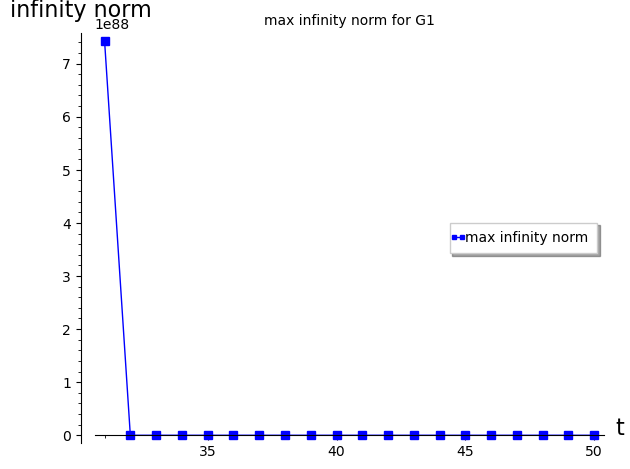

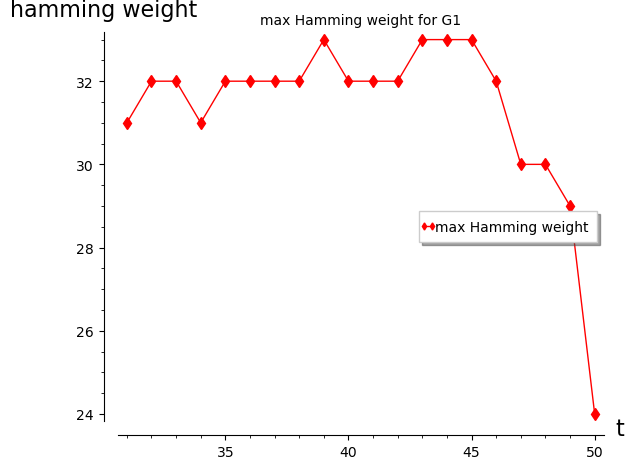

In [74]:
plot_G1_infty_norm = list_plot(curve_smallness_G1_infty_norm, plotjoined=True, marker='s', color='blue', legend_label = 'max infinity norm', axes_labels=['t','infinity norm'],title='max infinity norm for G1')
show(plot_G1_infty_norm, legend_loc = 'center right')
plot_G1_hamming_weight = list_plot(curve_smallness_G1_hamming_weight, plotjoined=True, marker='d', color='red', legend_label = 'max Hamming weight', axes_labels=['t','hamming weight'],title='max Hamming weight for G1')
show(plot_G1_hamming_weight,legend_loc = 'center right')

In [75]:
smallness(curve_smallness_G1,50)

,t,infinity norm bound,Hamming weight
0,50,56,24
1,49,35170,29
2,48,46894644739464,30
3,47,220266400264200697,30
4,46,1306909985023922532730468,32
5,45,417159372071401787791,33
6,44,8737304738506336208520812710892264,33
7,43,14860475690036385001422371637284643,33
8,42,174460711364112906379275939,32
9,41,45238878522222478225181293,32


### For $\mathbf{G}_2$

In [76]:
%%time
show(G2)
# k_c_det = 45
# 31-45 (MC, N = 50000), 46-50 (exact) 
# curve_smallness_G2_part_1 = stats_smallness_curve_MC(G2,N=50000, seed=0, repeats=3,s_min=31, s_max=40, verbose=False,cap_N=True)
# curve_smallness_G2_part_2 = stats_smallness_curve_MC(G2,N=50000, seed=0, repeats=3,s_min=41, s_max=45, verbose=False,cap_N=True)
# curve_smallness_G2_part_3 = stats_smallness_curve(G2, s_min = 46, s_max = 50)
curve_smallness_G2_part_1 = stats_smallness_curve_MC(G2,N=50000, seed=0, repeats=3,s_min=31, s_max=40, verbose=False,cap_N=True)
print(curve_smallness_G1_part_1)

50 x 25 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(31, 74299621499363635334612886202270125022648050824678331797826049977837684918101061324675788, 31), (32, 80301367088424129857009236136708300513446584372678289018660197282069323787365176345, 32), (33, 542634449719661740041695263855094552660503443295983, 32), (34, 9555267507483708511756251155200814, 31), (35, 994038654277006918010748660745857056969, 32), (36, 7940200740559568060113596, 32), (37, 8597151145178659248463090422292138, 32), (38, 1614569300663928905020529867, 32), (39, 1988675761172340606411480540543, 33), (40, 1632969421063863302200282153017, 32)]
CPU times: user 5min 50s, sys: 16 ms, total: 5min 50s
Wall time: 5min 50s


In [77]:
%%time
# show(G2)
# k_c_det = 45
# 31-45 (MC, N = 50000), 46-50 (exact) 
# curve_smallness_G2_part_1 = stats_smallness_curve_MC(G2,N=50000, seed=0, repeats=3,s_min=31, s_max=40, verbose=False,cap_N=True)
# curve_smallness_G2_part_2 = stats_smallness_curve_MC(G2,N=50000, seed=0, repeats=3,s_min=41, s_max=45, verbose=False,cap_N=True)
# curve_smallness_G2_part_3 = stats_smallness_curve(G2, s_min = 46, s_max = 50)
curve_smallness_G2_part_2 = stats_smallness_curve_MC(G2,N=50000, seed=0, repeats=3,s_min=41, s_max=45, verbose=False,cap_N=True)
print(curve_smallness_G2_part_2)

[(41, 125958787926464012824590797507103058310377, 32), (42, 2441049648593762336764925386682909315, 33), (43, 453689965854324221871716470465, 33), (44, 73692295695953127347438475236883, 32), (45, 453689965854324221871716470465, 32)]
CPU times: user 3min 36s, sys: 12 ms, total: 3min 36s
Wall time: 3min 36s


In [78]:
%%time
# show(G2)
# k_c_det = 45
# 31-45 (MC, N = 50000), 46-50 (exact) 
# curve_smallness_G2_part_1 = stats_smallness_curve_MC(G2,N=50000, seed=0, repeats=3,s_min=31, s_max=40, verbose=False,cap_N=True)
# curve_smallness_G2_part_2 = stats_smallness_curve_MC(G2,N=50000, seed=0, repeats=3,s_min=41, s_max=45, verbose=False,cap_N=True)
# curve_smallness_G2_part_3 = stats_smallness_curve(G2, s_min = 46, s_max = 50)
curve_smallness_G2_part_3 = stats_smallness_curve(G2, s_min = 46, s_max = 50)
print(curve_smallness_G2_part_3)

[(46, 453689965854324221871716470465, 32), (47, 196039047635036786474733, 32), (48, 7214656374948700763, 30), (49, 266277, 29), (50, 11, 23)]
CPU times: user 1min 10s, sys: 0 ns, total: 1min 10s
Wall time: 1min 10s


In [79]:
curve_smallness_G2 = curve_smallness_G2_part_1 + curve_smallness_G2_part_2 + curve_smallness_G2_part_3
print(curve_smallness_G2)

[(31, 3745437806378565277971424904160073874291809728891875988833598781861723850348014269646666699247340, 31), (32, 173484855366444692002599054154347189387126561196821009352372787641702349, 32), (33, 7188937110097390392914789861109379219831, 32), (34, 20697208500071884035416705658933506663910074281207, 33), (35, 6065912905729294202413101158699290, 32), (36, 7537651520139052666083842367791127068817943955, 32), (37, 1835397833363456302990595344181, 32), (38, 1219090404350517100491153769997553363070821, 32), (39, 805276465605801762026367018458, 33), (40, 9202195624060690986409438345828221, 32), (41, 125958787926464012824590797507103058310377, 32), (42, 2441049648593762336764925386682909315, 33), (43, 453689965854324221871716470465, 33), (44, 73692295695953127347438475236883, 32), (45, 453689965854324221871716470465, 32), (46, 453689965854324221871716470465, 32), (47, 196039047635036786474733, 32), (48, 7214656374948700763, 30), (49, 266277, 29), (50, 11, 23)]


In [80]:
curve_smallness_G2_infty_norm = [(s,linf) for (s, linf, wt) in curve_smallness_G2]
curve_smallness_G2_hamming_weight = [(s,wt) for (s,linf,wt) in curve_smallness_G2]
print(curve_smallness_G2_infty_norm)
print(curve_smallness_G2_hamming_weight)

[(31, 3745437806378565277971424904160073874291809728891875988833598781861723850348014269646666699247340), (32, 173484855366444692002599054154347189387126561196821009352372787641702349), (33, 7188937110097390392914789861109379219831), (34, 20697208500071884035416705658933506663910074281207), (35, 6065912905729294202413101158699290), (36, 7537651520139052666083842367791127068817943955), (37, 1835397833363456302990595344181), (38, 1219090404350517100491153769997553363070821), (39, 805276465605801762026367018458), (40, 9202195624060690986409438345828221), (41, 125958787926464012824590797507103058310377), (42, 2441049648593762336764925386682909315), (43, 453689965854324221871716470465), (44, 73692295695953127347438475236883), (45, 453689965854324221871716470465), (46, 453689965854324221871716470465), (47, 196039047635036786474733), (48, 7214656374948700763), (49, 266277), (50, 11)]
[(31, 31), (32, 32), (33, 32), (34, 33), (35, 32), (36, 32), (37, 32), (38, 32), (39, 33), (40, 32), (41, 32),

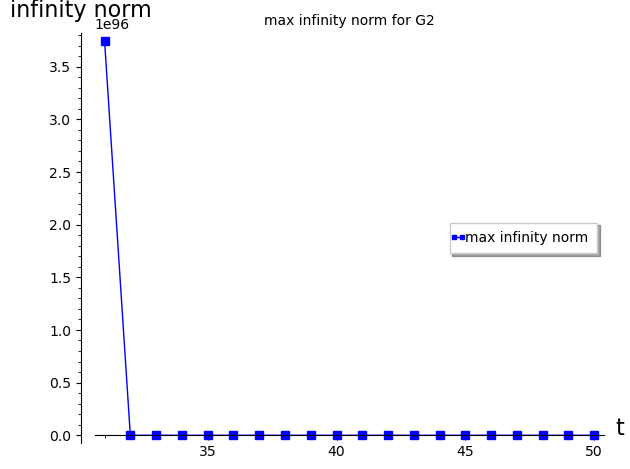

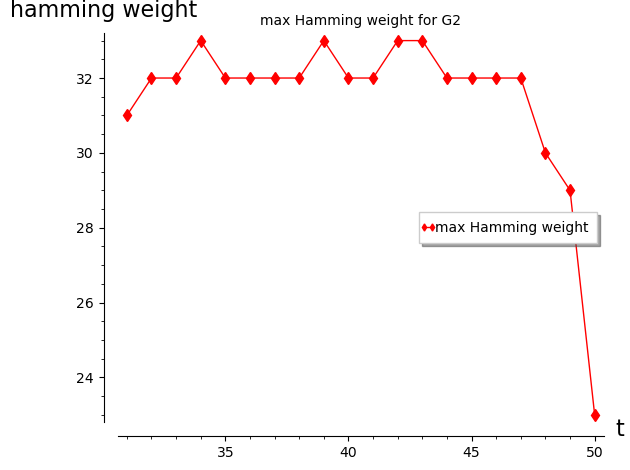

In [81]:
plot_G2_infty_norm = list_plot(curve_smallness_G2_infty_norm, plotjoined=True, marker='s', color='blue', legend_label = 'max infinity norm', axes_labels=['t','infinity norm'],title='max infinity norm for G2')
show(plot_G2_infty_norm, legend_loc = 'center right')
plot_G2_hamming_weight = list_plot(curve_smallness_G2_hamming_weight, plotjoined=True, marker='d', color='red', legend_label = 'max Hamming weight', axes_labels=['t','hamming weight'],title='max Hamming weight for G2')
show(plot_G2_hamming_weight,legend_loc = 'center right')

In [82]:
smallness(curve_smallness_G2,50)

,t,infinity norm bound,Hamming weight
0,50,11,23
1,49,266277,29
2,48,7214656374948700763,30
3,47,196039047635036786474733,32
4,46,453689965854324221871716470465,32
5,45,453689965854324221871716470465,32
6,44,73692295695953127347438475236883,32
7,43,453689965854324221871716470465,33
8,42,2441049648593762336764925386682909315,33
9,41,125958787926464012824590797507103058310377,32


# Constructing Small Reconstruction Vector

Suppose $\mathbf{G} \in \mathbb{Z}^{n \times k}$ and $S \subseteq [1,n]$. Recall that $S$ is certified if and only if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$. We have $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$ if and only if there exists $\bm{\lambda}_S \in \mathbb{Z}^{|S|}$ such that $\bm{\lambda}_S^\top \mathbf{G}_S = \mathbf{e}_1^\top$. We call this vector $\bm{\lambda}_S$ as a reconstruction vector. Recall that if $\mathbf{R}_{\mathbf{G}_S} \in \mathbb{Z}^{|S| \times k}$ is the row HNF of $\mathbf{G}_S$, then there is $\mathbf{U}_{\mathbf{G}_S} \in GL_{|S|}(\mathbb{Z})$ such that $\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}$. Moreover, we also have the following lemma.

**Lemma**. Let $\mathbf{G} \in \mathbb{Z}^{n \times k}$ and $\mathbf{R}_\mathbf{G} \in \mathbb{Z}^{n \times k}$ be the row-HNF of $\mathbf{G}$, i.e., there exists $\mathbf{U}_\mathbf{G} \in GL_n(\mathbb{Z})$ such that $\mathbf{R}_\mathbf{G} = \mathbf{U}_\mathbf{G} \mathbf{G}$. Assume that $\mathbf{R}_\mathbf{G}$ is in standard row-HNF (row-echelon/upper-triangular pivot structure, positive pivots, and for each pivot column, the entries above the pivots are reduced modulo the pivot). Let $\mathbf{e}_1^\top = (1,0,\dots,0)\in \mathbb{Z}^{1 \times k}$, then $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G})$ if and only if $\mathbf{R}_\mathbf{G}[1,\cdot] = \mathbf{e}_1^\top$. ($\mathbf{R}_\mathbf{G}[1,\cdot]$ is the first row of $\mathbf{R}_\mathbf{G}$ in $1$-based indexing.)
 
By considering the lemma we can choose $\bm{\lambda}_S^\top = \mathbf{U}_{\mathbf{G}_S}[1,\cdot]$. Notice that $\bm{\lambda}_S^\top\mathbf{G}_S = \mathbf{U}_{\mathbf{G}_S}[1,\cdot]\cdot\mathbf{G}_S = (\mathbf{U}_{\mathbf{G}_S}\cdot\mathbf{G}_S)[1,\cdot] = \mathbf{R}_{\mathbf{G}_S}[1,\cdot] = \mathbf{e}_1^\top$. Nevertheless, the entries of $\mathbf{U}_{\mathbf{G}_S}$ are not always small. We are interested in finding a reconstruction vector $\bm{\lambda}_S \in \mathbb{Z}^{|S|}$ such that $\|\bm{\lambda}_S\|_\infty$ is small. To do so, we consider the following steps:
1. Compute $\mathbf{U}_{\mathbf{G}_S}[1,\cdot]$ where $\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}$ with $\mathbf{U}_{\mathbf{G}_S} \in GL_{|S|}(\mathbb{Z})$ and $\mathbf{R}_{\mathbf{G}_S}$ is the row-HNF of $\mathbf{G}_S$. Denote $\bm{\lambda}_{S,0} = (\mathbf{U}_{\mathbf{G}_S}[1,\cdot])^\top$.
2. Compute $K = \ker_\mathbb{Z}(\mathbf{G}_S^\top)$ and define $\mathbf{B}_K$ as the matrix whose rows are the basis of $K$.
3. Perform the LLL algorithm to $\mathbf{B}_K$ so we have the reduced basis $\mathbf{B}_K'$. For brevity, suppose $\mathbf{B}_K' = \begin{bmatrix}\mathbf{B}_K'[1,\cdot] \\ \vdots \\ \mathbf{B}_K'[r,\cdot]\end{bmatrix}$ for some $r \in \mathbb{Z}^+$ (the number of rows of $\mathbf{B}_K'$).
4. Choose $\bm{\kappa} \in K$ by considering the integer linear combinations of the rows in $\mathbf{B}_K'$, i.e., $\bm{\kappa}^\top = \sum_{i=1}^r\alpha_i \cdot \mathbf{B}_K'[i,\cdot] = \bm{\alpha}^\top \mathbf{B}_K' $ or equivalently $\mathbf{B}_K'^\top \bm{\alpha} = \bm{\kappa}$ for some $\bm{\alpha} \in \mathbb{Z}^{r}$. In particular $\bm{\kappa}$ is chosen so that $\bm{\lambda}_S  = \bm{\lambda}_{S,0} + \bm{\kappa}$ has small entries, i.e., $\|\bm{\lambda}_S\|_\infty$ is sufficiently small.

Notice that
\begin{align*}
    \bm{\lambda}_S^\top \cdot\mathbf{G}_S &= \left(\bm{\lambda}_{S,0} + \bm{\kappa}\right)^\top \cdot \mathbf{G}_S = \bm{\lambda}_{S,0}^\top \cdot \mathbf{G}_S + \bm{\kappa}^\top \cdot \mathbf{G}_S \\
    &= \bm{\lambda}_{S,0}^\top\cdot \mathbf{G}_S = \mathbf{U}_{\mathbf{G}_S}[1,\cdot] \cdot \mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}[1,\cdot].
\end{align*}

To find small $\bm{\lambda}_S$, we consider a heuristic combination of Babai's algorithm and greedy minimization of $\bm{\lambda}_{S,0}$. Babai's algorithm is used to find a vector $\bm{\kappa} \in K $ that is approximately closest to $-\bm{\lambda}_{S,0}$, so that $\|\bm{\lambda}_{S,0} + \bm{\kappa}\|_2$ is sufficiently small. Then, we use a greedy search to minimize $\|\bm{\lambda}_{S,0} + \bm{\kappa}\|_\infty$.

## Some Basic Algorithms (including Babai's and Kannan's algorithm)

Helper functions.

In [83]:
def linf_norm(v):
    """Infinity norm for a ZZ vector-like object."""
    if len(v) == 0:
        return ZZ(0)
    return max(abs(ZZ(x)) for x in v)

Compute the initial solution $\bm{\lambda}_{S,0} = \mathbf{U}_{\mathbf{G}_S}[1,\cdot]$ where $\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}$ and $\mathbf{R}_{\mathbf{G}_S}$ is the row HNF of $\mathbf{G}_S$.

In [84]:
def hnf_initial_lambda(G_S):
    """
    Compute row-HNF of G_S with transformation:
        U * G_S = R
    Return:
        lam0 = U.row(0)  (ZZ row vector length |S|)
    """
    # Assume G_S is already over ZZ
    if G_S.nrows() == 0:
        return None

    R, U = G_S.hermite_form(transformation=True)

    # IMPORTANT: we use U.row(0) (vector-like), NOT U[0,:] (1×n matrix slice)
    lam0 = U.row(0)

    return lam0

Compute the LLL-reduced kernel basis of $\ker_\mathbb{Z}(\mathbf{G}_S^\top)$.

In [85]:
def kernel_basis_lll_of_GS_transpose(G_S, use_lll=True):
    """
    Compute a basis matrix B for K = ker_Z(G_S^T) such that:
        rows(B) span K as a Z-lattice.
    Optionally LLL-reduce the row basis.

    Returns:
        B (ZZ matrix with r rows and |S| columns)
    """
    A = G_S.transpose()              # k x |S|
    K = A.right_kernel(ZZ)           # integer kernel lattice
    B = K.basis_matrix()             # rows are a Z-basis

    if use_lll and B.nrows() > 1:
        B = B.LLL()

    return B

Given a lattice basis $B = \{\mathbf{b}_i,\dots,\mathbf{b}_r\}$ and a target $\mathbf{t}$, Babai's (nearest plane) algorithm works from the last basis vector down to the first, greedily snapping to the nearest hyperplane at each step. The algorithm returns a vector spanned by $B$ aproximate closest to $\mathbf{t}$. Here are the steps:
1. Compute the Gram-Schmidt orthogonalization $\tilde{B}$.
2. Set $\mathbf{b}:= \mathbf{t}$.
3. For $i = r$ down to $1$.
   1. Compute the coordinate $\mathbf{b}$ along $\mathbf{\tilde{b}}_i$ as $c_i = \frac{\langle\mathbf{b},\mathbf{\tilde{b}}_i\rangle}{\|\mathbf{\tilde{b}}_i\|_2^2}$.
   2. Set $\hat{c}_i = \lfloor c_i \rceil$.
   3. Update $\mathbf{b}:= \mathbf{b}-\hat{c}_i \cdot \mathbf{b}_i$.
4. Return $\mathbf{t}-\mathbf{b}$ as the approximate closest lattice vector.

In [86]:
from sage.all import ZZ, RealField, vector

def babai_nearest(B, target, prec=128):
    """
    Babai's nearest-plane algorithm (rows-as-basis).

    Input:
      B      : matrix (r x m), rows are lattice basis vectors in ZZ^m (typically LLL-reduced)
      target : vector-like of length m (ZZ/QQ/RR entries ok)
      prec   : real precision in bits for Gram–Schmidt/projections (default 128)

    Output:
      None if dimension mismatch
      otherwise: a vector in ZZ^m lying in the ZZ-span of rows(B),
                 approximating the closest lattice vector to target (Euclidean sense).
    """
    r = B.nrows()
    m = B.ncols()
    if len(target) != m:
        return None

    R = RealField(prec)
    t = vector(R, list(target))
    b = [vector(R, list(B.row(i))) for i in range(r)]

    # Gram–Schmidt orthogonalization: build b_star[i] = tilde{b}_i
    b_star = []
    for i in range(r):
        v = b[i]
        for j in range(i):
            denom = b_star[j].dot_product(b_star[j])
            if denom != 0:
                mu = v.dot_product(b_star[j]) / denom
                v = v - mu * b_star[j]
        b_star.append(v)

    # Nearest-plane loop (backwards)
    residual = t
    coeffs = [ZZ(0)] * r

    for i in reversed(range(r)):
        denom = b_star[i].dot_product(b_star[i])
        if denom == 0:
            # linearly dependent basis vector; ignore it
            coeffs[i] = ZZ(0)
            continue

        # c_i = <residual, b*_i> / ||b*_i||^2
        ci = residual.dot_product(b_star[i]) / denom

        # Built-in rounding to nearest integer, then coerce to ZZ
        ci_hat = ZZ(ci.round())
        coeffs[i] = ci_hat

        residual = residual - R(ci_hat) * b[i]

    # Construct lattice vector sum_i coeffs[i] * (integer row i)
    closest = vector(ZZ, [0]*m)
    for i in range(r):
        if coeffs[i] != 0:
            closest += coeffs[i] * vector(ZZ, list(B.row(i)))

    return closest

Babai's nearest plane algorithm might not work well if we consider lattice of higher dimension. We consider using Kannan's embedding technique to obtain short reconstruction vector.

In [87]:
from sage.all import ZZ, QQ, vector
from sage.modules.free_module_integer import IntegerLattice

def kannan_embedding_nearest(B_rows, target, delta=0.99, lll_reduce=False):
    """
    Approximate CVP via Kannan embedding (LLL-based) in Sage.

    B_rows: ZZ matrix (r x d) with rows a basis of the lattice
    target: vector length d (usually -lambda0)
    delta:  LLL delta parameter for approximate_closest_vector
    """
    if B_rows.nrows() == 0:
        return vector(ZZ, [0]*B_rows.ncols())

    d = B_rows.ncols()
    if len(target) != d:
        raise ValueError("Dimension mismatch in kannan_embedding_nearest")

    tQ = vector(QQ, list(target))

    L = IntegerLattice(B_rows, lll_reduce=bool(lll_reduce))

    # Sage doc: algorithm='embedding' embeds lattice in d+1 and uses LLL. 【1-2fa929】
    w = L.approximate_closest_vector(tQ, algorithm='embedding', delta=delta)

    return vector(ZZ, list(w))

BKZ reduction helper for the kernel basis.

In [88]:
from sage.all import ZZ

def bkz_reduce_row_basis(B_rows, block_size=12, lll_first=True, bkz_kwargs=None):
    """
    BKZ-reduce a lattice basis given as rows of a ZZ matrix.

    Returns a ZZ matrix whose rows are a BKZ-reduced basis (or LLL-reduced fallback).
    """
    if bkz_kwargs is None:
        bkz_kwargs = {}

    if B_rows.nrows() <= 1:
        return B_rows

    # Construct lattice from row basis
    L = IntegerLattice(B_rows, lll_reduce=bool(lll_first))

    try:
        # Sage doc: BKZ exists on IntegerLattice and returns a BKZ-reduced basis
        _ = L.BKZ(block_size=int(block_size), **bkz_kwargs)
        B_red = L.reduced_basis
        return B_red
    except Exception:
        # Fallback: LLL only
        try:
            return B_rows.LLL()
        except Exception:
            return B_rows

Implementing greedy reduction of $\|\bm{\lambda}\|_\infty$ using the kernel basis.

In [89]:
def greedy_reduce_linf(lambda0, B_kernel, passes=3, window=3):
    """
    Greedy reduction of ||lambda||_inf by adding integer kernel vectors.

    Inputs:
      lambda0 : ZZ row vector length s (initial)
      B_kernel: ZZ matrix whose rows b_i satisfy b_i^T * G_S = 0^T
      passes  : number of passes over the basis
      window  : search window around alpha0 (nearest integer)

    Output:
      lambda_best : ZZ row vector
    """
    lam = vector(ZZ, list(lambda0))
    best = linf_norm(lam)

    if B_kernel.nrows() == 0:
        return lam  # no kernel directions available

    for _ in range(int(passes)):
        improved = False

        for i in range(B_kernel.nrows()):
            b = vector(ZZ, list(B_kernel.row(i)))

            # choose index j of largest coordinate of lam
            j = max(range(len(lam)), key=lambda t: abs(lam[t]))

            if b[j] == 0:
                continue  # cannot change the worst coordinate

            # nearest integer to -lam[j]/b[j]
            alpha0 = ZZ(round(QQ(-lam[j]) / QQ(b[j])))

            lam_best = lam
            norm_best = best

            for alpha in range(int(alpha0 - window), int(alpha0 + window) + 1):
                cand = lam + ZZ(alpha) * b
                cand_norm = linf_norm(cand)
                if cand_norm < norm_best:
                    lam_best = cand
                    norm_best = cand_norm

            if norm_best < best:
                lam = lam_best
                best = norm_best
                improved = True

        if not improved:
            break

    return lam

Given a subset $S \subseteq [1,n]$, the reconstruction vector $\bm{\lambda}_S$ is obtained from $\mathbf{G}_S$ using the following steps:
1. Get $\bm{\lambda}_{S,0}^\top := \mathbf{U}_{\mathbf{G}_S}[1,\cdot]$ where $\mathbf{U}_{\mathbf{G}_S} \in GL_{|S|}(\mathbb{Z})$ such that $\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}$ and $\mathbf{R}_{\mathbf{G}_S}$ is the row HNF of $\mathbf{G}_S$. That is, $\mathbf{U}_{G}[1,\cdot]$ is the first row of the unimodular matrix that transforms $\mathbf{G}_S$ to its row HNF $\mathbf{R}_{\mathbf{G}_S}$.
2. Compute $K := \ker_\mathbb{Z}(\mathbf{G}_S^\top)$ and define $\mathbf{B}_K \in \mathbb{Z}^{r \times |S|}$ matrix whose rows are the basis of $K$.
3. Perform LLL to obtain an LLL-reduced basis for $K$, define $\mathbf{B}_K' \in \mathbb{Z}^{r \times |S|}$ as the matrix whose rows are the LLL-reduced basis of $K$.
4. Compute $\bm{\kappa} \in K$ as the lattice vector spanned by the rows of $\mathbf{B}_K'$ with target vector $\bm{\lambda}_{S,0}$.
5. Compute $\bm{\lambda}_{Babai} = \bm{\lambda}_{S,0} + \bm{\kappa}$.
6. If $\|\bm{\lambda}_{Babai}\|_\infty \leq \|\bm{\lambda}_{S,0}\|_\infty$, update $\bm{\lambda}_S:= \bm{\lambda}_{Babai}$.
7. Greedy reduced $\|\bm{\lambda}_S\|_\infty$ by considering the LLL-reduced basis $\mathbf{B}_K'$.

In [90]:
def construct_small_lambda_babai(G, S, passes=3, window=3):
    """
    Input:
      G : ZZ matrix (n x k)
      S : subset of row indices (0-based)
    Output:
      lambda_small : reduced reconstruction vector (ZZ vector of length |S|)
    """
    S = list(S)
    assert len(S) > 0

    G_S = G.matrix_from_rows(S)

    # HNF initial vector
    lambda_0 = hnf_initial_lambda(G_S)
    assert lambda_0 is not None

    # LLL-reduced kernel basis of G_S^T
    B = kernel_basis_lll_of_GS_transpose(G_S, use_lll=True)

    # Try Babai initializer
    kappa = babai_nearest(B, -lambda_0)
    lambda_start = lambda_0

    if kappa is not None:
        lambda_babai = lambda_0 + kappa
        linf0 = linf_norm(lambda_0)
        linf_b = linf_norm(lambda_babai)
        if linf_b <= linf0:
            lambda_start = lambda_babai

    # Greedy refinement
    lambda_small = greedy_reduce_linf(lambda_start, B, passes=passes, window=window)
    return lambda_small

This is the same approach as above, but we consider Kannan's embedding technique to get the small reconstruction vector.

Given a subset $S \subseteq [1,n]$, the reconstruction vector $\bm{\lambda}_S$ is obtained from $\mathbf{G}_S$ using the following steps:
1. Get $\bm{\lambda}_{S,0}^\top := \mathbf{U}_{\mathbf{G}_S}[1,\cdot]$ where $\mathbf{U}_{\mathbf{G}_S} \in GL_{|S|}(\mathbb{Z})$ such that $\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}$ and $\mathbf{R}_{\mathbf{G}_S}$ is the row HNF of $\mathbf{G}_S$. That is, $\mathbf{U}_{G}[1,\cdot]$ is the first row of the unimodular matrix that transforms $\mathbf{G}_S$ to its row HNF $\mathbf{R}_{\mathbf{G}_S}$.
2. Compute $K := \ker_\mathbb{Z}(\mathbf{G}_S^\top)$ and define $\mathbf{B}_K \in \mathbb{Z}^{r \times |S|}$ matrix whose rows are the basis of $K$.
3. Perform LLL to obtain an LLL-reduced basis for $K$, define $\mathbf{B}_K' \in \mathbb{Z}^{r \times |S|}$ as the matrix whose rows are the LLL-reduced basis of $K$.
4. Compute $\bm{\kappa} \in K$ as the lattice vector spanned by the rows of $\mathbf{B}_K'$ with target vector $\bm{\lambda}_{S,0}$.
5. Compute $\bm{\lambda}_{Kannan} = \bm{\lambda}_{S,0} + \bm{\kappa}$.
6. If $\|\bm{\lambda}_{Kannan}\|_\infty \leq \|\bm{\lambda}_{S,0}\|_\infty$, update $\bm{\lambda}_S:= \bm{\lambda}_{Kannan}$.
7. Greedy reduced $\|\bm{\lambda}_S\|_\infty$ by considering the LLL-reduced basis $\mathbf{B}_K'$.

In [91]:
from sage.all import ZZ, vector

def construct_small_lambda_kannan_bkz(
    G, S,
    passes=3, window=3,
    delta=0.99,
    bkz_block_size=12,
    bkz_lll_first=True,
    bkz_kwargs=None,
    use_bkz=True
):
    """
    Construct small reconstruction vector using:
      HNF witness -> kernel basis -> BKZ -> Kannan embedding -> greedy Linf polish.

    Parameters:
      bkz_block_size: BKZ block size (try 10–20). Larger is stronger but slower.
      use_bkz: if False, uses LLL only (baseline).
    """
    S = list(S)
    assert len(S) > 0

    G_S = G.matrix_from_rows(S)

    # HNF initial vector
    lambda_0 = hnf_initial_lambda(G_S)
    assert lambda_0 is not None
    lambda_0 = vector(ZZ, list(lambda_0))

    # Kernel basis (rows span ker_Z(G_S^T))
    B0 = kernel_basis_lll_of_GS_transpose(G_S, use_lll=False)

    # If kernel is trivial, no adjustment possible
    if B0.nrows() == 0:
        return lambda_0

    # Reduce kernel basis
    if use_bkz and B0.nrows() > 1:
        B = bkz_reduce_row_basis(B0, block_size=bkz_block_size, lll_first=bkz_lll_first, bkz_kwargs=bkz_kwargs)
    else:
        B = B0.LLL() if B0.nrows() > 1 else B0

    # Kannan embedding initializer (LLL-based embedding CVP heuristic) 【1-2fa929】
    kappa = kannan_embedding_nearest(B, -lambda_0, delta=delta, lll_reduce=False)
    kappa = vector(ZZ, list(kappa))

    lambda_start = lambda_0
    lambda_kannan = lambda_0 + kappa

    # Accept only if it doesn't worsen Linf
    if linf_norm(lambda_kannan) <= linf_norm(lambda_0):
        lambda_start = lambda_kannan

    # Greedy Linf refinement using the same reduced basis
    lambda_small = greedy_reduce_linf(lambda_start, B, passes=passes, window=window)
    return lambda_small

## Checking the smallnes of the reduced reconstruction vector

### Exact Enumeration

The previous **construct_small_lambda_babai(G,S,passes,window)** is a greedy algorithm that constructs a small $\bm{\lambda}_S$ using the greedy approach. The function **linf_max_reduced_babai(G,s,passes,window)** for $s \in [1,n]$ compute $\max\{\|\bm{\lambda}_S\|_\infty: |S| = s, \bm{\lambda}_S\text{ is obtained from the above reduction}\}$ and its corresponding Hamming weight where $\bm{\lambda}_S$ is obtained from **construct_small_lambda_babai(G,S,passes,window)**.

In [92]:
from itertools import combinations

def linf_max_reduced_babai(G, s, passes=3, window=3, return_argmax=False):
    """
    Compute max ||lambda_S||_inf and wt_H(lambda_S) over all subsets S of size s,
    where lambda_S is produced by construct_small_lambda_babai(G, S, passes, window).

    If return_argmax=True, also return one subset achieving the max.
    """
    n = G.nrows()
    s = int(s)
    assert 1 <= s <= n

    linf_max = ZZ(0)
    lam_max = None
    S_max = None

    for S in combinations(range(n), s):
        lam = construct_small_lambda_babai(G, S, passes=passes, window=window)
        linf_curr = linf_norm(lam)

        if linf_curr > linf_max:
            linf_max = linf_curr
            lam_max = lam
            S_max = list(S)
    # Hamming weight of the optimized lambda_S
    ham_weight_max = hamming_weight(lam_max)
    if return_argmax:
        return (linf_max, ham_weight_max, S_max)
    return (linf_max, ham_weight_max)

Constructing the curve for **linf_max_reduced_babai(G,s)** for a given $\mathbf{G}$ and $1\leq s\leq n$.

In [93]:
def linf_max_reduced_babai_curve(G, passes=3, window=3, s_min=1, s_max=None):
    '''
    Return a list of pairs
        [(s, linf_max_reduced_babai(G, s)) for s in [s_min, s_max]]
    using exact enumeration.
    '''
    n = G.nrows()

    if s_max is None:
        s_max = n

    s_min = max(1, int(s_min))
    s_max = min(int(s_max), n)

    curve = []
    for s in range(s_min, s_max + 1):
        linf_max_reduced_s, ham_weight_max_reduced_s = linf_max_reduced_babai(G, s, passes=passes, window=window, return_argmax=False)
        curve.append((s, linf_max_reduced_s, ham_weight_max_reduced_s))
    return curve

Some testing.

In [94]:
%%time
curve_linf_max_reduced_babai_G1_test_1 = linf_max_reduced_babai_curve(G1, passes= 2, window = 2, s_min = 47, s_max=50)
print(curve_linf_max_reduced_babai_G1_test_1)

[(47, 1, 8), (48, 1, 6), (49, 1, 10), (50, 1, 6)]
CPU times: user 5min 12s, sys: 260 ms, total: 5min 12s
Wall time: 5min 12s


The previous **construct_small_lambda_kannan_BKZ(G,S,passes,window,delta,bkz_block_size,bkz_lll_first,bkz_kwargs,use_bkz)** is a greedy algorithm that constructs a small $\bm{\lambda}_S$ using the greedy approach by considering Kannan's embedding and BKZ basis. The function **linf_max_reduced_kannan_BKZ(G,s,passes,window,delta,bkz_block_size,usze_bakz)** for $s \in [1,n]$ compute $\max\{\|\bm{\lambda}_S\|_\infty: |S| = s, \bm{\lambda}_S\text{ is obtained from the above reduction}\}$ and its corresponding Hamming weight where $\bm{\lambda}_S$ is obtained from **construct_small_lambda_kannan_BKZ(G,S,passes,window,delta,bkz_block_size,bkz_lll_first,bkz_kwargs,use_bkz)**.

In [95]:
from itertools import combinations
from sage.all import ZZ

def linf_max_reduced_kannan_bkz(
    G, s,
    passes=3, window=3,
    delta=0.99,
    bkz_block_size=12,
    bkz_lll_first=True,
    bkz_kwargs=None,
    use_bkz=True,
    verbose=False,
    progress_step=10000
):
    """
    Compute:
      max_{|S|=s} ||lambda_S||_inf
    and the Hamming weight of the maximizing lambda_S,
    where lambda_S is produced by construct_small_lambda_kannan_bkz(...).

    Parameters
    ----------
    G : ZZ matrix (n x k)
    s : int
        subset size
    passes, window : greedy refinement parameters
    delta : float
        LLL delta used inside Kannan embedding heuristic
    bkz_block_size : int
        BKZ block size (e.g., 10–20). Larger = stronger but slower.
    bkz_lll_first : bool
        Whether to LLL-reduce before BKZ (often True).
    bkz_kwargs : dict or None
        Optional extra kwargs passed to BKZ (if your helper supports it).
    use_bkz : bool
        If False, uses only LLL (baseline).
    verbose : bool
        If True, prints progress occasionally.
    progress_step : int
        print every progress_step subsets (only if verbose=True).

    Returns
    -------
    (linf_max, ham_weight_at_max)
      linf_max: ZZ integer
      ham_weight_at_max: int (or ZZ) weight of the lambda achieving linf_max
    """
    n = G.nrows()
    s = int(s)
    assert 1 <= s <= n

    linf_max = ZZ(0)
    lam_max = None

    for idx, S in enumerate(combinations(range(n), s), start=1):
        lam = construct_small_lambda_kannan_bkz(
            G, S,
            passes=passes,
            window=window,
            delta=delta,
            bkz_block_size=bkz_block_size,
            bkz_lll_first=bkz_lll_first,
            bkz_kwargs=bkz_kwargs,
            use_bkz=use_bkz
        )

        curr = linf_norm(lam)
        if lam_max is None or curr > linf_max:
            linf_max = curr
            lam_max = lam

        if verbose and (idx % progress_step == 0):
            print(f"[s={s}] processed {idx} subsets; current max ||lambda||_inf = {linf_max}")

    ham_weight_max = hamming_weight(lam_max) if lam_max is not None else 0
    return (linf_max, ham_weight_max)

Constructing the curve for **linf_max_reduced_kannan_bkz(G,s)** for a given $\mathbf{G}$ and $1\leq s\leq n$.

In [96]:
def linf_max_reduced_kannan_bkz_curve(
    G,
    passes=3, window=3,
    delta=0.99,
    bkz_block_size=12,
    bkz_lll_first=True,
    bkz_kwargs=None,
    use_bkz=True,
    s_min=1, s_max=None,
    verbose=False
):
    """
    Exact curve:
      [(s, linf_max(s), wt_at_max(s)) for s in s_min..s_max]
    using construct_small_lambda_kannan_bkz.
    """
    n = G.nrows()
    if s_max is None:
        s_max = n

    s_min = max(1, int(s_min))
    s_max = min(int(s_max), n)

    curve = []
    for s in range(s_min, s_max + 1):
        linf_s, wt_s = linf_max_reduced_kannan_bkz(
            G, s,
            passes=passes, window=window,
            delta=delta,
            bkz_block_size=bkz_block_size,
            bkz_lll_first=bkz_lll_first,
            bkz_kwargs=bkz_kwargs,
            use_bkz=use_bkz,
            verbose=verbose
        )
        curve.append((s, linf_s, wt_s))
    return curve

Some testing.

In [97]:
%%time
curve_linf_max_reduced_kannan_bkz_G1_test_2 = linf_max_reduced_kannan_bkz_curve(
    G1,
    passes=2, window=2,
    delta=0.99,
    use_bkz=True, bkz_block_size=12, bkz_lll_first=True,
    s_min=47, s_max=50
)
print(curve_linf_max_reduced_kannan_bkz_G1_test_2)

[(47, 1, 8), (48, 1, 6), (49, 1, 10), (50, 1, 6)]
CPU times: user 4min 14s, sys: 244 ms, total: 4min 15s
Wall time: 4min 15s


### With Monte Carlo simulation

We consider a Monte Carlo simulation to obtain the improved $\ell_\infty$ norm and Hamming weight of a reconstruction vector because the number of subsets of $S \subseteq [1,n]$ is too large.

The function **linf_max_reduced_babai_MC(G,s,N,passes,window)** for $s \in [1,n]$ and $N \in \mathbb{Z}^+$ computes $\max\{\|\bm{\lambda}_S\|_\infty: |S| = s, \bm{\lambda}_S\text{ is obtained from the above reduction}\}$ and its corresponding Hamming weight where $\bm{\lambda}_S$ is obtained from **construct_small_lambda_babai(G,S,passes,window)** using Monte Carlo simulation, i.e., instead of generating all subsets $S$ of size $s$, we consider $N$ distinct samples of $S$ of size $n$.

In [98]:
from sage.all import ZZ, binomial

def linf_max_reduced_babai_MC(G, s, N=1000, seed=0, passes=3, window=3, return_argmax=False):
    """
    Monte Carlo (observed max):
    Over N distinct sampled subsets S of size s, compute
      max ||lambda_S||_inf
    where lambda_S = construct_small_lambda_babai(G, S, passes, window),
    and also return the Hamming weight of the maximizer.

    If return_argmax=True, also return one subset achieving the max.
    """
    n = G.nrows()
    s = int(s)
    assert 1 <= s <= n

    # Safety: cannot sample more distinct subsets than exist
    total = binomial(n, s)
    if N > total:
        raise ValueError(f"N={N} exceeds number of subsets C({n},{s})={total}")

    linf_max = ZZ(0)
    lam_max = None
    S_max = None

    samples = sample_unique_subsets(n, s, N, seed)

    for S in samples:
        lam = construct_small_lambda_babai(G, S, passes=passes, window=window)
        linf_curr = linf_norm(lam)

        if lam_max is None or linf_curr > linf_max:
            linf_max = linf_curr
            lam_max = lam
            S_max = list(S)

    ham_weight_max = hamming_weight(lam_max) if lam_max is not None else 0

    if return_argmax:
        return (linf_max, ham_weight_max, S_max)
    return (linf_max, ham_weight_max)

Constructing the curve for **linf_max_reduced_babai_MC(G,s,N,seed,passes,window)** for a given $\mathbf{G}$ and $1\leq s\leq n$.

In [99]:
def linf_max_reduced_babai_curve_MC(G, N=1000, seed=0, repeats=3, passes=3, window=3, s_min=1, s_max=None, verbose=False):
    n = G.nrows()
    if s_max is None:
        s_max = n

    s_min = max(1, int(s_min))
    s_max = min(int(s_max), n)

    curve = []
    for s in range(s_min, s_max + 1):
        best_linf = ZZ(0)
        best_wt = 0

        for r in range(repeats):
            seed_sr = seed + 1000*s + r
            linf_s, wt_s = linf_max_reduced_babai_MC(G, s, N=N, seed=seed_sr, passes=passes, window=window, return_argmax=False)
            if linf_s > best_linf:
                best_linf = linf_s
                best_wt = wt_s

        if verbose:
            print(f"s={s}, observed max over repeats = {best_linf}")

        curve.append((s, best_linf, best_wt))

    return curve

Some testing near the good threshold.

In [100]:
%%time
curve_linf_max_reduced_babai_MC_G1_test_1 = linf_max_reduced_babai_curve_MC(G1, N=3000, seed = 0, repeats=3, passes= 2, window = 2, s_min = 40, s_max=46)
print(curve_linf_max_reduced_babai_MC_G1_test_1)

[(40, 2, 13), (41, 1, 6), (42, 1, 10), (43, 1, 6), (44, 1, 6), (45, 1, 10), (46, 1, 6)]
CPU times: user 11min 59s, sys: 760 ms, total: 11min 59s
Wall time: 11min 59s


The function **linf_max_reduced_kannan_bkz(G,s,N,passes,window)** for $s \in [1,n]$ and $N \in \mathbb{Z}^+$ computes $\max\{\|\bm{\lambda}_S\|_\infty: |S| = s, \bm{\lambda}_S\text{ is obtained from the above reduction}\}$ and its corresponding Hamming weight where $\bm{\lambda}_S$ is obtained from **construct_small_lambda_kannan_bkz(G,S,passes,window)** using Monte Carlo simulation, i.e., instead of generating all subsets $S$ of size $s$, we consider $N$ distinct samples of $S$ of size $n$.

In [101]:
from sage.all import ZZ, binomial

def linf_max_reduced_kannan_bkz_MC(
    G, s,
    N=1000, seed=0,
    passes=3, window=3,
    delta=0.99,
    use_bkz=True,
    bkz_block_size=10,
    bkz_lll_first=True,
    bkz_kwargs=None,
    verbose=False
):
    n = G.nrows()
    s = int(s)
    assert 1 <= s <= n

    total = int(binomial(n, s))
    if N > total:
        raise ValueError(f"N={N} exceeds number of subsets C({n},{s})={total}")

    if bkz_kwargs is None:
        bkz_kwargs = {}

    linf_max = ZZ(0)
    lam_max = None

    samples = sample_unique_subsets(n, s, N, seed)

    failed = 0
    for idx, S in enumerate(samples, start=1):
        try:
            lam = construct_small_lambda_kannan_bkz(
                G, S,
                passes=passes, window=window,
                delta=delta,
                use_bkz=use_bkz,
                bkz_block_size=bkz_block_size,
                bkz_lll_first=bkz_lll_first,
                bkz_kwargs=bkz_kwargs
            )
            if lam is None:
                failed += 1
                continue

            linf_curr = linf_norm(lam)
            if lam_max is None or linf_curr > linf_max:
                linf_max = linf_curr
                lam_max = lam

        except Exception as e:
            failed += 1
            if verbose:
                print(f"[s={s}] sample {idx} failed: {type(e).__name__}: {e}")
            continue

    wt_max = hamming_weight(lam_max) if lam_max is not None else 0

    if verbose and failed > 0:
        print(f"[s={s}] finished with {failed}/{N} failed samples")

    return (linf_max, wt_max)

Constructing the curve for **linf_max_reduced_kannan_BKZ_MC(G,s,N,seed,passes,window)** for a given $\mathbf{G}$ and $1\leq s\leq n$.

In [102]:
from sage.all import ZZ

def linf_max_reduced_kannan_bkz_curve_MC(
    G,
    N=1000,
    seed=0,
    repeats=3,
    passes=3,
    window=3,
    s_min=1,
    s_max=None,
    # Kannan embedding + BKZ parameters (with sensible defaults)
    delta=0.99,
    use_bkz=True,
    bkz_block_size=12,
    bkz_lll_first=True,
    bkz_kwargs=None,
    verbose=False
):
    """
    Monte Carlo curve (observed max over N distinct subsets, repeated 'repeats' times):
      returns [(s, best_linf, best_wt) for s in [s_min..s_max]]

    Uses linf_max_reduced_kannan_bkz_MC at each s (no argmax returned).
    """
    n = G.nrows()
    if s_max is None:
        s_max = n

    s_min = max(1, int(s_min))
    s_max = min(int(s_max), n)

    curve = []
    for s in range(s_min, s_max + 1):
        best_linf = ZZ(0)
        best_wt = 0

        for r in range(repeats):
            seed_sr = seed + 1000*s + r
            linf_s, wt_s = linf_max_reduced_kannan_bkz_MC(
                G, s,
                N=N,
                seed=seed_sr,
                passes=passes,
                window=window,
                delta=delta,
                use_bkz=use_bkz,
                bkz_block_size=bkz_block_size,
                bkz_lll_first=bkz_lll_first,
                bkz_kwargs=bkz_kwargs,
                verbose=False
            )
            if linf_s > best_linf:
                best_linf = linf_s
                best_wt = wt_s

        if verbose:
            print(f"s={s}, observed max over repeats = {best_linf}")

        curve.append((s, best_linf, best_wt))

    return curve

Some testing near the good threshold.

In [103]:
%%time
curve_linf_max_reduced_kannan_bkz_MC_G1_test_2 = linf_max_reduced_kannan_bkz_curve_MC(
    G1,
    N=3000,
    seed=0,
    repeats=3,
    passes=2,
    window=2,
    s_min=40,
    s_max=46,
    use_bkz=True,
    bkz_block_size=10,
    bkz_lll_first=True,
    verbose=False
)
print(curve_linf_max_reduced_kannan_bkz_MC_G1_test_2)

[(40, 2, 13), (41, 2, 10), (42, 1, 10), (43, 1, 6), (44, 1, 6), (45, 1, 10), (46, 1, 6)]
CPU times: user 11min 21s, sys: 1.29 s, total: 11min 23s
Wall time: 11min 23s


# Testing the effect on reducing the reconstruction vector

A function to create a combined table (used later).

In [104]:
def smallness_with_reduced(curve_smallness_G, curve_smallness_G_red, n):
    """
    Combine two smallness curves into a single table.
    
    INPUT:
    - curve_smallness_G: list of triples (t, inf_norm, hamming_wt)
    - curve_smallness_G_red: list of triples (t, inf_norm_reduced, hamming_wt_reduced)
    - n: parameter for the caption
    
    OUTPUT:
    - displays a pandas DataFrame with columns:
      t, infinity norm bound, Hamming weight,
      infinity norm bound (reduced), Hamming weight (reduced)
    """
    df_G = pd.DataFrame(curve_smallness_G, columns=['t', 'infinity norm bound', 'Hamming weight'])
    df_G_red = pd.DataFrame(curve_smallness_G_red, columns=['t', 'infinity norm bound (reduced)', 'Hamming weight (reduced)'])
    
    # Merge on 't' — since t_G and t_H are identical, inner join is fine
    df = df_G.merge(df_G_red, on='t', how='inner')
    
    df = df.sort_values('t', ascending=False).reset_index(drop=True)
    
    caption = f"experiment for smallness and sparsity for n = {n}"
    return df.style.set_caption(caption)

## Testing for $\mathbf{G}_1$

We initially use Babai nearest plane with LLL, if it fails, then we switch to Kannan embedding with LLL-BKZ. However, as we have previously see, the LLL-BKZ is a little bit faster than the Babai nearest plane with LLL.

In [105]:
%%time
show(G1)
# k_c_det = 45
# 31-39 (MC, N=10000), 40-46 (MC, N=10000), 47-50 (exact) 
curve_linf_max_reduced_G1_part_1 = linf_max_reduced_kannan_bkz_curve_MC(
    G1,
    N=10000,
    seed=0,
    repeats=3,
    passes=2,
    window=2,
    s_min=31,
    s_max=39,
    use_bkz=True,
    bkz_block_size=10,
    bkz_lll_first=True,
    verbose=False
)
print(curve_linf_max_reduced_G1_part_1)

50 x 25 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(31, 6, 25), (32, 3, 22), (33, 4, 21), (34, 3, 16), (35, 2, 11), (36, 2, 13), (37, 2, 13), (38, 2, 13), (39, 2, 15)]
CPU times: user 26min 12s, sys: 3.52 s, total: 26min 16s
Wall time: 26min 16s


In [106]:
%%time
# show(G1)
# k_c_det = 45
# 31-39 (MC, N=10000), 40-46 (MC, N=10000), 47-50 (exact) 
curve_linf_max_reduced_G1_part_2 = linf_max_reduced_kannan_bkz_curve_MC(
    G1,
    N=10000,
    seed=0,
    repeats=3,
    passes=2,
    window=2,
    s_min=40,
    s_max=46,
    use_bkz=True,
    bkz_block_size=10,
    bkz_lll_first=True,
    verbose=False
)
print(curve_linf_max_reduced_G1_part_2)

[(40, 2, 13), (41, 2, 10), (42, 1, 10), (43, 1, 6), (44, 1, 6), (45, 1, 10), (46, 1, 6)]
CPU times: user 36min 57s, sys: 3.94 s, total: 37min 1s
Wall time: 37min 1s


In [107]:
%%time
# show(G1)
# k_c_det = 45
# 31-39 (MC, N=10000), 40-46 (MC, N=10000), 47-50 (exact) 
curve_linf_max_reduced_G1_part_3 = linf_max_reduced_kannan_bkz_curve(
    G1,
    passes=2, window=2,
    delta=0.99,
    use_bkz=True, bkz_block_size=10, bkz_lll_first=True,
    s_min=47, s_max=50
)
print(curve_linf_max_reduced_G1_part_3)

[(47, 1, 8), (48, 1, 6), (49, 1, 10), (50, 1, 6)]
CPU times: user 4min 49s, sys: 488 ms, total: 4min 49s
Wall time: 4min 49s


In [108]:
curve_linf_max_reduced_G1 = curve_linf_max_reduced_G1_part_1+curve_linf_max_reduced_G1_part_2+curve_linf_max_reduced_G1_part_3
print(curve_linf_max_reduced_G1)

[(31, 6, 25), (32, 3, 22), (33, 4, 21), (34, 3, 16), (35, 2, 11), (36, 2, 13), (37, 2, 13), (38, 2, 13), (39, 2, 15), (40, 2, 13), (41, 2, 10), (42, 1, 10), (43, 1, 6), (44, 1, 6), (45, 1, 10), (46, 1, 6), (47, 1, 8), (48, 1, 6), (49, 1, 10), (50, 1, 6)]


In [109]:
smallness_with_reduced(curve_smallness_G1,curve_linf_max_reduced_G1,45)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,50,56,24,1,6
1,49,35170,29,1,10
2,48,46894644739464,30,1,6
3,47,220266400264200697,30,1,8
4,46,1306909985023922532730468,32,1,6
5,45,417159372071401787791,33,1,10
6,44,8737304738506336208520812710892264,33,1,6
7,43,14860475690036385001422371637284643,33,1,6
8,42,174460711364112906379275939,32,1,10
9,41,45238878522222478225181293,32,2,10


In [110]:
curve_smallness_G1_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_G1]
curve_smallness_G1_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_G1]
print(curve_smallness_G1_red_infty_norm)
print(curve_smallness_G1_red_hamming_weight)

[(31, 6), (32, 3), (33, 4), (34, 3), (35, 2), (36, 2), (37, 2), (38, 2), (39, 2), (40, 2), (41, 2), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1)]
[(31, 25), (32, 22), (33, 21), (34, 16), (35, 11), (36, 13), (37, 13), (38, 13), (39, 15), (40, 13), (41, 10), (42, 10), (43, 6), (44, 6), (45, 10), (46, 6), (47, 8), (48, 6), (49, 10), (50, 6)]


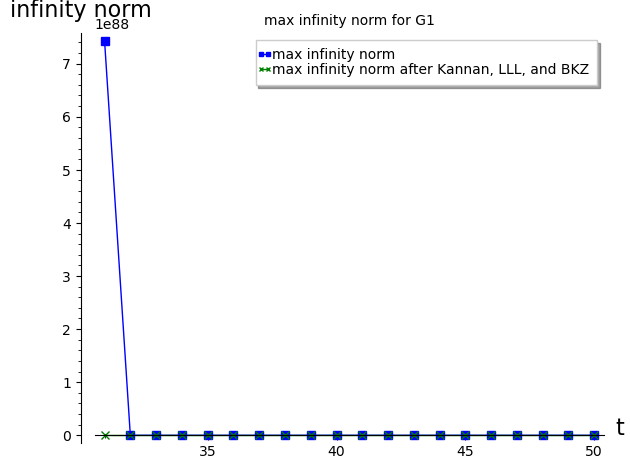

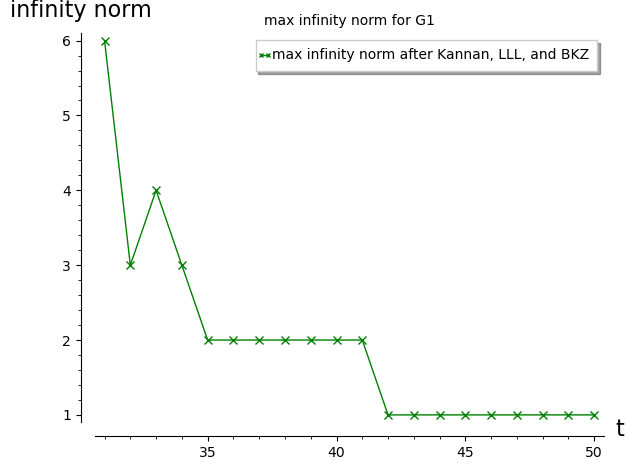

In [111]:
plot_G1_red_inf_norm = list_plot(curve_smallness_G1_red_infty_norm, plotjoined=True, marker='x', color='green', legend_label = 'max infinity norm after Kannan, LLL, and BKZ', axes_labels=['t','infinity norm'],title='max infinity norm for G1')
show(plot_G1_infty_norm + plot_G1_red_inf_norm)
show(plot_G1_red_inf_norm)

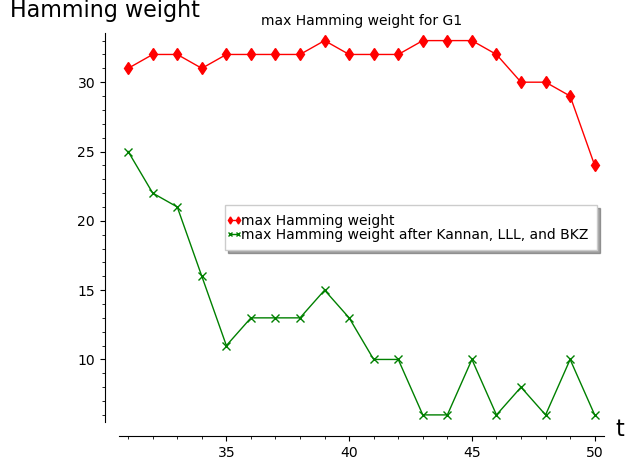

In [112]:
plot_G1_red_ham_weight = list_plot(curve_smallness_G1_red_hamming_weight, plotjoined=True, marker='x', color='green', legend_label = 'max Hamming weight after Kannan, LLL, and BKZ', axes_labels=['t','Hamming weight'],title='max Hamming weight for G1')
show(plot_G1_hamming_weight+plot_G1_red_ham_weight)

## Testing for $\mathbf{G}_2$

We initially use Babai nearest plane with LLL, if it fails, then we switch to Kannan embedding with LLL-BKZ. However, as we have previously see, the LLL-BKZ is better for smaller threshold.

In [113]:
%%time
show(G2)
# k_c_det = 45
# 31-39 (MC, N=10000), 40-46 (MC, N=10000), 47-50 (exact) 
curve_linf_max_reduced_G2_part_1 = linf_max_reduced_kannan_bkz_curve_MC(
    G2,
    N=10000,
    seed=0,
    repeats=3,
    passes=2,
    window=2,
    s_min=31,
    s_max=39,
    use_bkz=True,
    bkz_block_size=10,
    bkz_lll_first=True,
    verbose=False
)
print(curve_linf_max_reduced_G2_part_1)

50 x 25 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(31, 5, 23), (32, 5, 26), (33, 3, 15), (34, 2, 15), (35, 2, 15), (36, 2, 13), (37, 2, 13), (38, 2, 11), (39, 2, 14)]
CPU times: user 30min 50s, sys: 5.03 s, total: 30min 55s
Wall time: 30min 55s


In [114]:
%%time
# show(G2)
# k_c_det = 47
# 31-39 (MC, N=10000), 40-46 (MC, N=10000), 47-50 (exact) 
curve_linf_max_reduced_G2_part_2 = linf_max_reduced_kannan_bkz_curve_MC(
    G2,
    N=10000,
    seed=0,
    repeats=3,
    passes=2,
    window=2,
    s_min=40,
    s_max=46,
    use_bkz=True,
    bkz_block_size=10,
    bkz_lll_first=True,
    verbose=False
)
print(curve_linf_max_reduced_G2_part_2)

[(40, 2, 13), (41, 2, 8), (42, 1, 6), (43, 1, 6), (44, 1, 8), (45, 2, 8), (46, 1, 8)]
CPU times: user 38min 30s, sys: 4.69 s, total: 38min 35s
Wall time: 38min 35s


In [115]:
%%time
# show(G2)
# k_c_det = 47
# 31-39 (MC, N=10000), 40-46 (MC, N=10000), 47-50 (exact) 
curve_linf_max_reduced_G2_part_3 = linf_max_reduced_kannan_bkz_curve(
    G2,
    passes=2, window=2,
    delta=0.99,
    use_bkz=True, bkz_block_size=10, bkz_lll_first=True,
    s_min=47, s_max=50
)
print(curve_linf_max_reduced_G2_part_3)

[(47, 1, 8), (48, 1, 6), (49, 1, 6), (50, 1, 6)]
CPU times: user 4min 48s, sys: 488 ms, total: 4min 49s
Wall time: 4min 49s


In [116]:
curve_linf_max_reduced_G2 = curve_linf_max_reduced_G2_part_1+curve_linf_max_reduced_G2_part_2+curve_linf_max_reduced_G2_part_3
print(curve_linf_max_reduced_G2)

[(31, 5, 23), (32, 5, 26), (33, 3, 15), (34, 2, 15), (35, 2, 15), (36, 2, 13), (37, 2, 13), (38, 2, 11), (39, 2, 14), (40, 2, 13), (41, 2, 8), (42, 1, 6), (43, 1, 6), (44, 1, 8), (45, 2, 8), (46, 1, 8), (47, 1, 8), (48, 1, 6), (49, 1, 6), (50, 1, 6)]


In [117]:
smallness_with_reduced(curve_smallness_G2,curve_linf_max_reduced_G2,50)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,50,11,23,1,6
1,49,266277,29,1,6
2,48,7214656374948700763,30,1,6
3,47,196039047635036786474733,32,1,8
4,46,453689965854324221871716470465,32,1,8
5,45,453689965854324221871716470465,32,2,8
6,44,73692295695953127347438475236883,32,1,8
7,43,453689965854324221871716470465,33,1,6
8,42,2441049648593762336764925386682909315,33,1,6
9,41,125958787926464012824590797507103058310377,32,2,8


In [118]:
curve_smallness_G2_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_G2]
curve_smallness_G2_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_G2]
print(curve_smallness_G2_red_infty_norm)
print(curve_smallness_G2_red_hamming_weight)

[(31, 5), (32, 5), (33, 3), (34, 2), (35, 2), (36, 2), (37, 2), (38, 2), (39, 2), (40, 2), (41, 2), (42, 1), (43, 1), (44, 1), (45, 2), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1)]
[(31, 23), (32, 26), (33, 15), (34, 15), (35, 15), (36, 13), (37, 13), (38, 11), (39, 14), (40, 13), (41, 8), (42, 6), (43, 6), (44, 8), (45, 8), (46, 8), (47, 8), (48, 6), (49, 6), (50, 6)]


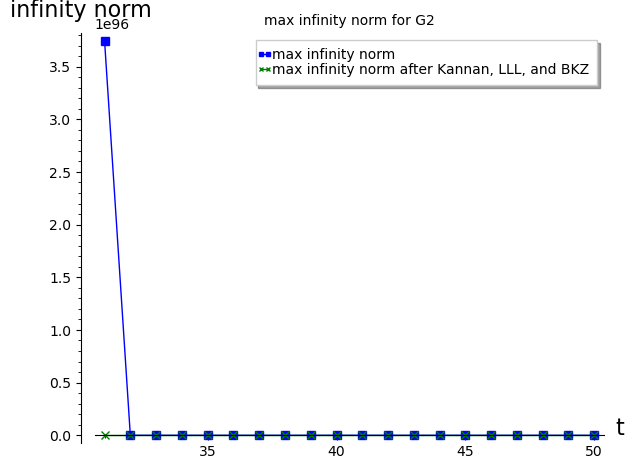

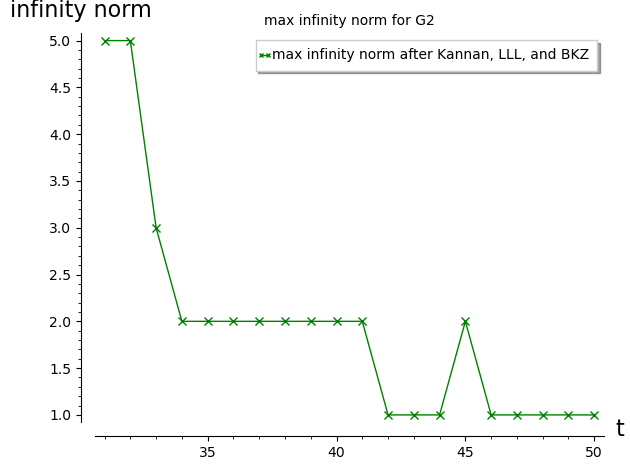

In [119]:
plot_G2_red_inf_norm = list_plot(curve_smallness_G2_red_infty_norm, plotjoined=True, marker='x', color='green', legend_label = 'max infinity norm after Kannan, LLL, and BKZ', axes_labels=['t','infinity norm'],title='max infinity norm for G2')
show(plot_G2_infty_norm + plot_G2_red_inf_norm)
show(plot_G2_red_inf_norm)

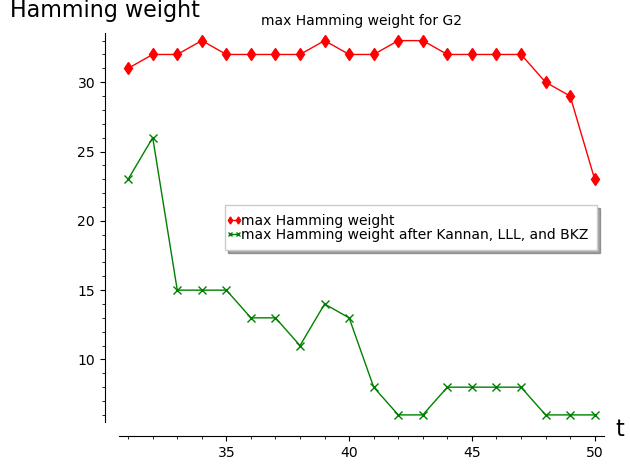

In [120]:
plot_G2_red_ham_weight = list_plot(curve_smallness_G2_red_hamming_weight, plotjoined=True, marker='x', color='green', legend_label = 'max Hamming weight after Kannan, LLL, and BKZ', axes_labels=['t','Hamming weight'],title='max Hamming weight for G2')
show(plot_G2_hamming_weight+plot_G2_red_ham_weight)

# Final Choice

## Printing information for $\mathbf{G}$

In [143]:
G_50_24_3 = G1
show(G_50_24_3)
print(G_50_24_3)
print(T1)
print(lambdas1)

50 x 25 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[ 1 -1  1  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
[ 1  0  0  0  0  0  0  0  0  0  1  0  0 -1  0  0  0  0  0  0  1  0  0  0  0]
[ 1  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0]
[ 1  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  1  0  0  0  0]
[ 1  0  0  0  0  0  0  0 -1  0  0  0  0  0 -1  0  0  0  0  0  0  0 -1  0  0]
[ 1  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0 -1  0  0  0  1  0  0  0  0]
[ 1  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0 -1  0  0 -1  0  0  0  0  0]
[ 1  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0 -1]
[ 1  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  1  0  0  0  0  0 -1  0]
[ 1  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  1  0  0 -1  0]
[ 1  0  0  0  0  0  0  0  0  0  1  0  0  0  0  1  0  0  0  0  0  0  0 -1  0]
[-1  0  0  0  0  0  1  0  0  0  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0  0]
[ 1  0  0  0  0  0  0  0 -1  1  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0]

## Empirical privacy analysis: proportion of $U$ that completely leaks the secret

Suppose we consider a fixed $U \subseteq [1,n]$. Then, $U$ completely leaks the secret if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}_U)$, i.e., $\mathbf{e}_1^\top$ can be expressed as a $\mathbb{Q}$-linear combination of the rows of $\mathbf{G}_U$. We can prove the following lemma.

**Lemma**: Fix $U \subseteq [1,n]$ and the matrix $\mathbf{G}$. The following conditions are equivalent.
1. $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}_U)$.
2. If $\mathbf{F}_{\mathbf{G}_U}$ is the canonical reduced row echelon form (RREF) of $\mathbf{G}_U$, then $\mathbf{F}_{\mathbf{G}_U}[1,\cdot] = \mathbf{e}_1^\top = (1,0,\dots,0) \in \mathbb{Q}^k$.

We define the function **rational_span(G)** that takes a matrix $\mathbf{G} \in \mathbb{Z}^{s \times k}$ as input and returns true if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G})$.

Suppose $\mathbf{G} \in \mathbb{Z}^{s \times k}$ and $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G})$. This means $\mathbf{e}_1^\top$ can be obtained using elementary row operations (over $\mathbb{Q}$) on $\mathbf{G}$. If $\mathbf{F}_\mathbf{G} \in \mathbb{Q}^{s \times k}$ is the RREF of $\mathbf{G}$, then it is unique lower triangular matrix such that $\mathbf{F}_\mathbf{G} = \mathbf{E}_\mathbf{G} \mathbf{G}$ for some invertible matrix $\mathbf{E}_\mathbf{G} \in \mathbb{Q}^{s \times s}$. By the RREF pivot condition, if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G})$, we must have $\mathbf{F}_\mathbf{G}[1,\cdot] = \mathbf{e}_1^\top$ (i.e., the first row of $\mathbf{F}_\mathbf{G}$ ($1$-based indexing) is $\mathbf{e}_1^\top$. In short: $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}) \Leftrightarrow \mathbf{F}_\mathbf{G}[1,\cdot] = \mathbf{e}_1^\top$. For fast testing, we consider the following equivalence:
\begin{align*}
    \mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}) \Leftrightarrow \mathrm{rank}_\mathbb{Q}(\mathbf{G}) = \mathrm{rank}_\mathbb{Q}\left(\begin{bmatrix}\mathbf{e}_1^\top\\\mathbf{G}\end{bmatrix}\right)
\end{align*}

We define the function **rational_span_S(G,S)** that takes a matrix $\mathbf{G} \in \mathbb{Z}^{n \times k}$ and $S \subseteq [0,n-1]$ ($0$-based-index) as input and returns true if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}_S)$.

In [144]:
from sage.all import QQ, vector

def rational_span(G):
    if G.nrows() == 0:
        return False
    k = G.ncols()
    e1 = vector(QQ, [1] + [0]*(k-1))
    A = G.change_ring(QQ)
    return A.rank() == A.stack(e1).rank()

def rational_span_S(G, S):
    """
    Return True iff e1^T is in Row_Q(G_S).
    """
    if len(S) == 0:
        return False

    # quick reject: if col0 restricted to S is all zeros
    if all(G[i,0] == 0 for i in S):
        return False

    G_S = G.matrix_from_rows(S)
    return rational_span(G_S)

We define $\Pr_{\text{complete leak}}(s,\mathbf{G})$ for a fixed matrix $\mathbf{G} \in \mathbb{Z}^{n \times k}$ and $s \in [1,n]$ as
\begin{align}
    \Pr_{\text{complete leak}}(s,\mathbf{G}) &\stackrel{\text{def}}{=} \frac{|\{S\subseteq [1,n]: \left(|S| = s\right) \land \left(\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}_S)\right)\}|}{|\{S\subseteq [1,n]: \left(|S| = s\right)\}|}\\
    &= \frac{1}{\binom{n}{s}}|\{S\subseteq [1,n]: \left(|S| = s\right) \land \left(\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}_S)\right)\}|
\end{align}

### Exact Enumeration

In [145]:
from itertools import combinations
from sage.all import binomial, QQ

def Pcomleak(s, G):
    """
    Exact Pr_{complete leak}(s, G) by enumerating all subsets S of size s.
    Works for small n (e.g., n=20).
    Returns an exact rational in QQ.
    """
    n = G.nrows()
    total = binomial(n, s)
    if total == 0:
        return QQ(0)

    good = 0
    for S in combinations(range(n), s):
        if rational_span_S(G, S):
            good += 1

    return QQ(good) / QQ(total)

In [151]:
%%time
G_chosen = G_50_24_3
show(G_chosen)
Pcomleak46 = Pcomleak(46,G_chosen)
show("46","--",Pcomleak46,"--",1-Pcomleak46)

50 x 25 dense matrix over Integer Ring (use the '.str()' method to see the entries)

'46' '--' 1 '--' 0

CPU times: user 1min 55s, sys: 12 ms, total: 1min 55s
Wall time: 1min 55s


Constructing the curve for $\Pr_{\text{complete leak}}(s,\mathbf{G})$ for a given $\mathbf{G}$ and $1\leq s\leq n$. 

In [147]:
def Pcomleak_curve(G, s_min=1, s_max=None):
    """
    Return the Pcomleak curve as a list of pairs [(s, Pcomleak(s,G)) for s in [s_min..s_max]] exactly (small n only).

    Parameters
    -----------
    s_min : int
        Minimum s to include (default 1).
    s_max : int or None
        Maximum s to include, inclusive (default n).

    Returns
    --------
    list of tuples
        [(s, QQ probability), ...]
    """
    n = G.nrows()
    if s_max is None:
        s_max = n
    return [(s, Pcomleak(s, G)) for s in range(s_min, s_max + 1)]

### With Monte Carlo simulation

**Pcomleak_MC(s, G, N, seed)** compute $\Pr_{\text{complete leak}}(s,\mathbf{G})$ using Monte Carlo simulation for $N$ (default value $1000$) distinct subsets using seed $seed$ (defaulf value $0$).

In [148]:
def Pcomleak_MC(s, G, N=1000, seed=0):
    """
    Monte Carlo estimate of Pr_complete_leak(s,G) using N distinct subsets.
    Returns p_hat.
    """
    n = G.nrows()
    s = int(s)
    assert 1 <= s <= n

    total = int(binomial(n, s))
    if N > total:
        raise ValueError(f"N={N} exceeds number of distinct subsets C({n},{s})={total}")

    samples = sample_unique_subsets(n, s, N, seed=seed)

    success = 0
    for S in samples:
        if rational_span_S(G, S):
            success += 1

    return success / N

Constructing the curve for $\Pr_{\text{complete leak}}(s,\mathbf{G})$ using Monte Carlo simulation for $N$ (default value $1000$) distinct subsets using seed $seed$ (defaulf value $0$).

In [149]:
def Pcomleak_curve_MC(G, N = 1000, seed = 0, s_min=1, s_max=None):
    """
    Return the Pcomleak_MC curve as a list of pairs [(s, Pcomleak_MC(s,G,N,seed)) for s in [s_min..s_max]] using Monte Carlo simulation
    with N samples and seed=seed.

    Parameters
    -----------
    s_min : int
        Minimum s to include (default 1).
    s_max : int or None
        Maximum s to include, inclusive (default n).

    Returns
    --------
    list of tuples
        [(s, QQ probability), ...]
    """
    n = G.nrows()
    if s_max is None:
        s_max = n
    return [(s, Pcomleak_MC(s, G, N, seed)) for s in range(s_min, s_max + 1)]

Some testing.

In [150]:
%%time
curve_comleak_G_chosen_test_1 = Pcomleak_curve_MC(G_chosen,N=100000,seed=0,s_min = 40, s_max = 45)
print(curve_comleak_G_chosen_test_1)

[(40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1)]
CPU times: user 4min 44s, sys: 28 ms, total: 4min 44s
Wall time: 4min 44s


### Experiment

We consider the relationship $\Pr_{actual}(s,\mathbf{G}) \leq \Pr_\text{complete leak}(s,\mathbf{G})$. If previously we have $\Pr_{actual}(s,\mathbf{G}) = 1$ from exact enumeration, we skip checking $\Pr_\text{complete leak}(s,\mathbf{G})$ and instead setting $\Pr_\text{complete leak}(s,\mathbf{G}) = 1$.

In [153]:
%%time
show(G_chosen)
# k_c_det = 45
# Pr_actual(45,G_chosen) = Pr_actual(46,G_chosen) = 1
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 500000), part 3:  16-30 (MC, N = 250000), part 4: 31-40 (MC, N = 500000), part 5: 41-44 (MC, N = 1000000), part 6: 45-50 (exact = 1) 
curve_comleak_G_chosen_part_1 = [(s, 0.0) for s in range(1,5+1)]
curve_comleak_G_chosen_part_6 = [(s,1.0) for s in range(45,50+1)]
print(curve_comleak_G_chosen_part_1)
print(curve_comleak_G_chosen_part_6)

50 x 25 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 0.000000000000000), (2, 0.000000000000000), (3, 0.000000000000000), (4, 0.000000000000000), (5, 0.000000000000000)]
[(45, 1.00000000000000), (46, 1.00000000000000), (47, 1.00000000000000), (48, 1.00000000000000), (49, 1.00000000000000), (50, 1.00000000000000)]
CPU times: user 7.32 ms, sys: 5 μs, total: 7.33 ms
Wall time: 6.22 ms


In [154]:
%%time
# show(G_chosen)
# k_c_det = 45
# Pr_actual(45,G_chosen) = Pr_actual(46,G_chosen) = 1
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 500000), part 3:  16-30 (MC, N = 250000), part 4: 31-40 (MC, N = 500000), part 5: 41-44 (MC, N = 1000000), part 6: 45-50 (exact = 1) 
curve_comleak_G_chosen_part_2 = Pcomleak_curve_MC(G_chosen,N=500000,seed=0,s_min=6,s_max=15)
print(curve_comleak_G_chosen_part_2)

[(6, 0), (7, 0), (8, 1/100000), (9, 3/125000), (10, 3/62500), (11, 59/500000), (12, 131/500000), (13, 13/31250), (14, 427/500000), (15, 723/500000)]
CPU times: user 14min 24s, sys: 104 ms, total: 14min 24s
Wall time: 14min 24s


In [155]:
%%time
# show(G_chosen)
# k_c_det = 45
# Pr_actual(45,G_chosen) = Pr_actual(46,G_chosen) = 1
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 500000), part 3:  16-30 (MC, N = 250000), part 4: 31-40 (MC, N = 500000), part 5: 41-44 (MC, N = 1000000), part 6: 45-50 (exact = 1) 
curve_comleak_G_chosen_part_3 = Pcomleak_curve_MC(G_chosen,N=250000,seed=0,s_min=16,s_max=30)
print(curve_comleak_G_chosen_part_3)

[(16, 671/250000), (17, 213/50000), (18, 2009/250000), (19, 3417/250000), (20, 1311/50000), (21, 13339/250000), (22, 29549/250000), (23, 69943/250000), (24, 74373/125000), (25, 11989/12500), (26, 124393/125000), (27, 124899/125000), (28, 249969/250000), (29, 31249/31250), (30, 249999/250000)]
CPU times: user 19min 56s, sys: 76 ms, total: 19min 56s
Wall time: 19min 56s


In [156]:
%%time
# show(G_chosen)
# k_c_det = 45
# Pr_actual(45,G_chosen) = Pr_actual(46,G_chosen) = 1
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 500000), part 3:  16-30 (MC, N = 250000), part 4: 31-40 (MC, N = 500000), part 5: 41-44 (MC, N = 1000000), part 6: 45-50 (exact = 1)
curve_comleak_G_chosen_part_4 = Pcomleak_curve_MC(G_chosen,N=500000,seed=0,s_min=31,s_max=40)
print(curve_comleak_G_chosen_part_4)

[(31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1)]
CPU times: user 35min 12s, sys: 1.12 s, total: 35min 13s
Wall time: 35min 13s


In [157]:
%%time
# show(G_chosen)
# k_c_det = 45
# Pr_actual(45,G_chosen) = Pr_actual(46,G_chosen) = 1
# part 1: 1-5 (exact = 0), part 2: 6-15 (MC, N = 500000), part 3:  16-30 (MC, N = 250000), part 4: 31-40 (MC, N = 500000), part 5: 41-44 (MC, N = 1000000), part 6: 45-50 (exact = 1)
curve_comleak_G_chosen_part_5 = Pcomleak_curve_MC(G_chosen,N=1000000,seed=0,s_min=41,s_max=44)
print(curve_comleak_G_chosen_part_5)

[(41, 1), (42, 1), (43, 1), (44, 1)]
CPU times: user 32min 33s, sys: 2.09 s, total: 32min 35s
Wall time: 32min 35s


In [158]:
curve_comleak_G_chosen = curve_comleak_G_chosen_part_1+curve_comleak_G_chosen_part_2+curve_comleak_G_chosen_part_3+curve_comleak_G_chosen_part_4+curve_comleak_G_chosen_part_5+curve_comleak_G_chosen_part_6
print(curve_comleak_G_chosen)

[(1, 0.000000000000000), (2, 0.000000000000000), (3, 0.000000000000000), (4, 0.000000000000000), (5, 0.000000000000000), (6, 0), (7, 0), (8, 1/100000), (9, 3/125000), (10, 3/62500), (11, 59/500000), (12, 131/500000), (13, 13/31250), (14, 427/500000), (15, 723/500000), (16, 671/250000), (17, 213/50000), (18, 2009/250000), (19, 3417/250000), (20, 1311/50000), (21, 13339/250000), (22, 29549/250000), (23, 69943/250000), (24, 74373/125000), (25, 11989/12500), (26, 124393/125000), (27, 124899/125000), (28, 249969/250000), (29, 31249/31250), (30, 249999/250000), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1.00000000000000), (46, 1.00000000000000), (47, 1.00000000000000), (48, 1.00000000000000), (49, 1.00000000000000), (50, 1.00000000000000)]


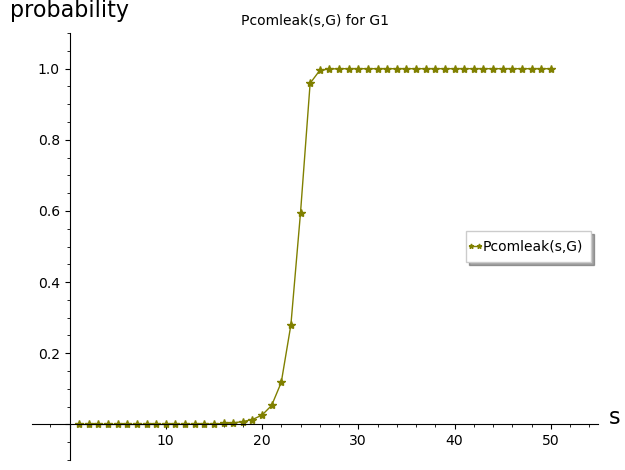

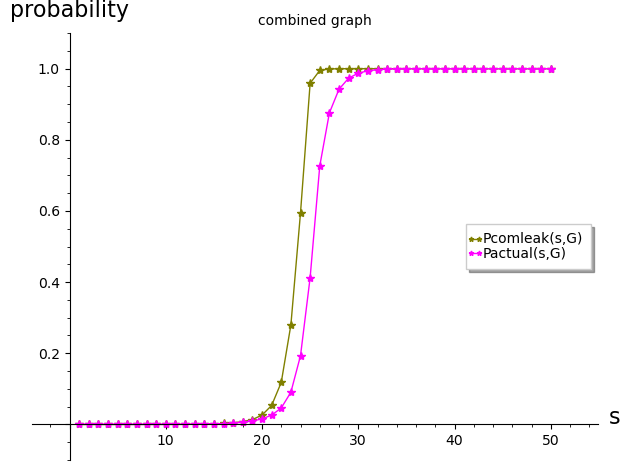

In [159]:
plot_G_chosen = list_plot(curve_comleak_G_chosen, plotjoined=True, marker='*', color = 'olive', legend_label = 'Pcomleak(s,G)',axes_labels=['s','probability'], title='Pcomleak(s,G) for G1')
show(plot_G_chosen, legend_loc = 'center right', axes_pad=0.1)
show(plot_G_chosen+plot_G1, axes_labels=['s','probability'],title='combined graph',legend_loc='center right', axes_pad =0.1)

Table preparation.

In [160]:
curve_correctness_chosen = curve_actual_G1
curve_comleak_chosen = curve_comleak_G_chosen
print(curve_correctness_chosen)
print(curve_comleak_chosen)

[(1, 0.000000000000000), (2, 0.000000000000000), (3, 0.000000000000000), (4, 0.000000000000000), (5, 0.000000000000000), (6, 0), (7, 0), (8, 9/1000000), (9, 7/250000), (10, 27/500000), (11, 2/15625), (12, 1/4000), (13, 213/500000), (14, 763/1000000), (15, 671/500000), (16, 1159/500000), (17, 923/250000), (18, 761/125000), (19, 4787/500000), (20, 243/15625), (21, 13039/500000), (22, 11561/250000), (23, 22629/250000), (24, 9663/50000), (25, 10321/25000), (26, 11351/15625), (27, 437843/500000), (28, 471143/500000), (29, 121673/125000), (30, 246839/250000), (31, 994027/1000000), (32, 997157/1000000), (33, 124843/125000), (34, 99951/100000), (35, 12497/12500), (36, 999911/1000000), (37, 199993/200000), (38, 49999/50000), (39, 999993/1000000), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1.00000000000000), (48, 1.00000000000000), (49, 1.00000000000000), (50, 1.00000000000000)]
[(1, 0.000000000000000), (2, 0.000000000000000), (3, 0.000000000000000), (4, 0.00000000000000

In [161]:
import pandas as pd

def leak_correctness(curve_correctness_chosen, curve_comleak_chosen, n):
    '''
    Creating a combined table of curve_comleak_chosen and curve_correctness_chosen.
    Numbers are rounded to 8 decimal places.
    '''
    # Convert each list of pairs into a small dataframe
    df_curve_comleak_chosen     = pd.DataFrame(curve_comleak_chosen,     columns=['t', 'Pr_complete-leak(t,G)'])
    df_curve_correctness_chosen = pd.DataFrame(curve_correctness_chosen, columns=['t', 'Pr_actual(t,G)'])

    # Merge on 't' using outer join
    df = df_curve_correctness_chosen.merge(df_curve_comleak_chosen, on='t', how='outer')

    # Convert to float and round to 8 decimal places
    for col in ['Pr_actual(t,G)', 'Pr_complete-leak(t,G)']:
        df[col] = df[col].apply(lambda x: round(float(x), 8))

    df = df.sort_values('t', ascending=False).reset_index(drop=True)

    caption = f"experiment for correctness and privacy threshold for n = {n}"
    return df.style.set_caption(caption).format({
        'Pr_actual(t,G)'       : '{:.8f}',
        'Pr_complete-leak(t,G)': '{:.8f}'
    })

In [162]:
leak_correctness(curve_correctness_chosen,curve_comleak_chosen,45)

,t,"Pr_actual(t,G)","Pr_complete-leak(t,G)"
0,50,1.00000000,1.00000000
1,49,1.00000000,1.00000000
2,48,1.00000000,1.00000000
3,47,1.00000000,1.00000000
4,46,1.00000000,1.00000000
5,45,1.00000000,1.00000000
6,44,1.00000000,1.00000000
7,43,1.00000000,1.00000000
8,42,1.00000000,1.00000000
9,41,1.00000000,1.00000000
